In [1]:
#models
library(dplyr)
library(tidyverse)
library(caret)
library(recipes)
library(pROC)
library(tidyr)
library(ppcor)
directory_path <- "../../../../../../Lucas-Cancer-Screening"


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.2     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.1.0     ✔ tidyr     1.3.1
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lif

In [2]:
load("../../../../../reproduce_lucas_wflow/code/rlucas/data/metadata.rda")
load("../../../../../reproduce_lucas_wflow/code/rlucas/data/lucas_5mb.rda")

# Olink proteomics

features <- read_csv("../../../../../../data/reproduce_lucas_olink_merged_training_set_FULL.csv", show_col_types=FALSE)
multinucs <- bins5mb %>% group_by(id) %>%
    summarize(multinucratio = sum(multinucs)/(sum(short+long)))
features <- inner_join(multinucs, features, by="id")

###### Criteria for Model 1 #########
#####################################

# Filter out the LUCAS cohort and keep 124 participants with no prior, baseline or future cancer and 85 patients
# with cancer at the time of the blood draw (n=209)

labels <- meta %>% dplyr::select(id, assigned_group)
labels <- labels %>% filter(assigned_group != 1) %>%
    mutate(type = ifelse(assigned_group==2, "healthy", "cancer")) %>%
    dplyr::select(-assigned_group)

#stage <- meta %>% select(id, Stage)

features <- inner_join(labels, features, by=c("id"="id"))
features <- features  %>% dplyr::select(-starts_with("cov_"))

features <- features %>% mutate(clinical_smokingstatus=factor(clinical_smokingstatus,
                                                              c("never", "former", "current")),
                                clinical_COPD=as.integer(clinical_COPD))

### Load new LUCAS DELFI 3.0 Features ###
## Load the updated training features processed with DELFI 3.0
features_delfi3 <- read_csv("../../../../../../data/LUCAS_HI_2025-08/features/allfeatures.5mb.hg19.csv", show_col_types=FALSE)


# Pivot zscore values wider, with arm values becoming column names
features_delfi3_wide <- features_delfi3 %>%
  pivot_wider(
    id_cols = id,
    names_from = arm,
    values_from = zscore,
    names_prefix = "zscore_"
  )

# Extract one row per patient for the non-zscore data (e.g., ratioX)
non_zscore_data <- features_delfi3 %>%
  dplyr::select(-arm, -zscore) %>%
  distinct()

# Combine with wide zscores
features_delfi3_final <- non_zscore_data %>%
  left_join(features_delfi3_wide, by = "id")


features_delfi3_final <- features_delfi3_final %>%
  dplyr::select(-starts_with("cov_"))

features_delfi3_final <- features_delfi3_final %>%
  dplyr::select(-starts_with("zscore_NA"))

# Merge only the id column from meta based on Patient
features_delfi3_final <- inner_join(dplyr::select(meta, id), features_delfi3_final, by = "id")
features_delfi3_final

# Identify overlapping columns (excluding 'id')
overlap_cols <- intersect(colnames(features), colnames(features_delfi3_final))
cols_to_drop <- setdiff(overlap_cols, "id")

# Drop overlapping columns from 'features'
features_clean <- features %>% dplyr::select(-all_of(cols_to_drop))

# Merge, keeping values from features_nova_final
merged_df <- left_join(features_clean, features_delfi3_final, by = "id")

filtered_df <- merged_df %>%
  filter(if_all(starts_with("zscore_") | starts_with("ratio_"), ~ !is.na(.)))

id,ratio_1,ratio_2,ratio_3,ratio_4,ratio_5,ratio_6,ratio_7,ratio_8,ratio_9,⋯,zscore_17p,zscore_17q,zscore_18p,zscore_18q,zscore_19p,zscore_19q,zscore_20p,zscore_20q,zscore_21q,zscore_22q
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PGDX26551P1,0.862768797,1.3870584,0.8904268,3.484468,0.423402969,0.46602240,1.8545167,0.173748372,1.00651665,⋯,-0.07668294,-0.7999659,-0.85381987,-1.602845456,0.4591071,1.1332159,-1.570082888,-1.7920345,-0.05249737,-1.67804841
PGDX26758P1,1.348899667,1.3609936,1.0863042,3.493412,0.145277773,0.91021011,1.8484003,0.579129093,0.77967923,⋯,-1.98483866,0.1225240,-0.81660371,-1.209796814,-1.2258007,-1.2777942,-1.185817323,-1.2596899,-1.47405281,0.18485901
PGDX26561P1,-0.300538654,-0.4762504,-0.2030792,3.737315,-0.866604569,0.09105656,1.8659968,0.031727784,0.54098691,⋯,0.03258381,0.8275140,-0.09910527,-0.287687651,-0.3970209,0.1814410,-0.384482422,-0.7774713,0.24203258,-0.08992445
PGDX26721P,1.630617200,1.0286936,1.1017179,3.375796,-0.030057522,0.77887702,2.4217111,0.196652657,1.05802205,⋯,-1.39778755,-2.0817178,-0.83296069,-1.093317004,-1.1090026,-0.4868446,-0.761415647,-1.3950402,-0.97303792,-1.24698570
PGDX26762P1,0.627573850,0.4701624,0.5407863,1.706662,0.148801514,0.32126248,0.9297324,0.002185631,0.04028964,⋯,2.31733491,-0.2058847,0.98853034,-8.305750144,-1.2966500,-0.1866568,3.748289104,5.1878228,-5.14796087,-8.75302265
PGDX26845P,0.132064953,0.1941768,1.0368634,4.423627,-0.979043768,0.32754390,1.4345003,-0.824744663,0.64352102,⋯,-0.46535482,-1.5276119,1.03061099,-0.256769738,-0.5633788,-0.2786615,0.356212713,-1.0812387,-1.96312448,2.20213633
PGDX26615P,1.122759422,1.2046283,1.3736412,2.981961,0.588747614,1.11218533,1.9498378,0.013359518,0.80713976,⋯,-3.91033011,2.8382611,-0.14468900,-2.760847530,-3.4781046,-4.4140127,-3.677498373,-1.0364627,-1.64496117,1.29555181
PGDX26973P,1.228833635,1.4998130,1.3078138,3.223204,0.633817837,0.97897538,1.8882001,0.237645789,0.97875566,⋯,-1.19121453,-2.3813618,-2.67657161,-2.264036980,-0.1915776,0.2466413,-2.678981190,-2.2753932,-1.40822834,-2.50656396
PGDX26633P,0.665947325,0.2810467,0.8652598,3.561201,0.119175310,1.32591034,1.5102479,-0.213558337,0.73948339,⋯,-0.89360346,-1.3840932,0.34366434,-0.182722688,-2.4075143,-0.6836748,0.331567294,0.6665799,-0.18840638,1.58044700


In [3]:
filtered_df <- left_join(filtered_df, meta, by = "id")
filtered_df <- filtered_df %>%
  mutate(olink_CEA = log2(clinical_CEA + 1))
more_meta <- read_csv("../../../../../../data/20240611_LUCAS_Olink_BX0170_NPX_Clinical_Delfi_QC.csv")
more_meta <- more_meta %>% rename(id = `PGDX ID`)

Rows: 241 Columns: 274
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr   (88): Patient, Assay, Plate ID, QC Warning, REASON_REFERRAL, REASON_OT...
dbl  (174): VICTOR_ID, LUCAS_ID, IL8, TNFRSF9, TIE2, MCP-3, CD40-L, IL-1 alp...
lgl    (3): DIAGNOSE_OTHER_PRIMARY, Adaptor Dimer, Date Data Received
date   (9): DATE_1_VISIT_BBH, DATE_BIOPSY, DATE_SCAN_BASELINE, DATE_FEV1, DA...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
# 1. Find overlapping columns (except the join key)
overlap <- setdiff(intersect(colnames(filtered_df), colnames(more_meta)), "id")

# 2. Drop overlapping columns from more_meta
more_meta_nodup <- more_meta[, !colnames(more_meta) %in% overlap, drop = FALSE]

lucas_df <- filtered_df %>%
  left_join(more_meta_nodup, by = "id")

In [5]:
# Define the patterns and replacements
patterns <- c("olink_IL-1 alpha", "olink_PDGF subunit B", "olink_LAP TGF-beta-1", "-", "/")
replacements <- c("olink_IL-1-alpha", "olink_PDGF-subunit-B", "olink_LAP-TGF-beta-1", "_", "_")

# Use sapply to chain gsub calls together
colnames(lucas_df) <- Reduce(function(names, i) gsub(patterns[i], replacements[i], names), 1:length(patterns), init = colnames(lucas_df))

In [6]:
batch_meta <- read_csv('../../../../../../data/Methylation/202509_lucas_methylation_annotated.csv')


Rows: 365 Columns: 142
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (31): cg_id, Cohort, Extraction CGID, Extraction 
Batch Number, Extract...
dbl  (49): Plasma Volume Received (mL) estimate from collaborator, Measured ...
lgl  (60): Unnamed: 0, Cohort Index Number, Alt Tube ID, Sample Info, Shipme...
dttm  (2): Extraction 
Date, Library Prep 
Date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [7]:
lucas_df <- merge(
  lucas_df,
  batch_meta[, c("cg_id", "Library Batch Number")],
  by.x = "Patient",
  by.y = "cg_id",
  all.x = TRUE
)

# Rename the column
names(lucas_df)[names(lucas_df) == "Library Batch Number"] <- "clinical_library_batch"
lucas_df

Patient,id,type,multinucratio,clinical_nlratio,clinical_CRP,clinical_cfdna_conc,clinical_age,clinical_IL6,clinical_YKL40,⋯,ALK translocation,Read Length,High quality Bases Sequenced(mapq>30),Coverage,DELFI score,DELFImulti score,DELFI score (no prior cancers),ichor,Fragment length,clinical_library_batch
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CGPLLU272P,PGDX26827P,healthy,0.06339168,0.5526316,10,5.257222,46.95962,2.9,40,⋯,NA,100,6182020200,1.99697,0.03675523,0.055259040,0.0026233464,0.6093,169,14
CGPLLU273P,PGDX26631P,healthy,0.07624839,0.6548387,10,4.343125,51.90965,7.9,135,⋯,NA,100,6638832300,2.14454,0.09866242,0.012530090,0.0077867327,0.6171,169,2
CGPLLU276P,PGDX26646P,healthy,0.06041187,0.7607843,10,17.777125,73.71663,11.9,188,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,3
CGPLLU277P,PGDX26662P,healthy,0.05800038,0.6953125,10,2.977083,23.53183,9.5,53,⋯,NA,100,6394288900,2.06554,0.08209345,0.002630167,0.0091509103,0.7417,168,4
CGPLLU278P,PGDX26678P,healthy,0.04285687,0.5654545,10,9.605972,59.07734,4.1,84,⋯,NA,100,6376520500,2.05980,0.01427202,0.006495213,0.0002791836,0.7972,166,5
CGPLLU281P,PGDX26615P,cancer,0.06544904,0.7611765,22,18.936216,60.74743,8.1,96,⋯,Normal,100,5273987000,1.70365,0.91398648,0.870385795,0.9835053542,3.1360,167,1
CGPLLU282P,PGDX26694P,healthy,0.07260925,0.5071429,10,7.236795,24.14511,4.3,112,⋯,NA,100,5557428300,1.79521,0.24808359,0.006591458,0.0407541846,0.4138,167,6
CGPLLU283P,PGDX26633P,cancer,0.06607843,0.6026316,10,27.132857,75.92608,2.3,203,⋯,Normal,100,6983114600,2.25575,0.74949755,0.995473162,0.5399151088,0.7972,170,2
CGPLLU284P,PGDX26648P,cancer,0.08179902,0.8218310,36,48.532500,62.69678,686.0,485,⋯,NA,100,5815255300,1.87850,1.00000000,1.000000000,1.0000000000,30.0300,165,3


In [8]:
#write_csv(lucas_df, "../lucas_df.csv")

### Add CRE element analyses

In [10]:
library(dplyr)
library(tibble)
library(purrr)
library(readr)
library(stringr)
library(tools)
library(tidyr)  # needed explicitly for pivot_longer/pivot_wider

# ------------------------------------------------------------------
# 1. User-specified feature module to extract
# ------------------------------------------------------------------
# Choose from: "relcov", "swfse", "fld", "qchasm", "qchasm_outward", "halo", "endmotif"
feature_to_extract <- "relcov"

# Directory with all CRE .rds outputs
root_dir <- "../results/tmp-HEALTHY-TCGA/tmp"
rds_files <- list.files(root_dir, pattern = "\\metrics.rds$", recursive = TRUE, full.names = TRUE)

# ------------------------------------------------------------------
# 2. Function to extract a single feature module per sample
# ------------------------------------------------------------------
read_cre_feature <- function(path, feature_name) {
  obj <- readRDS(path)
  if (is.null(obj$features[[feature_name]]))
    stop("Feature '", feature_name, "' not found in ", basename(path))

  mat <- obj$features[[feature_name]]
  id <- if (!is.null(obj$sample_name)) obj$sample_name else file_path_sans_ext(basename(path))

  df <- as.data.frame(mat)
  df$CRE_name <- rownames(mat)

  # Add id column
  df <- df %>%
    dplyr::mutate(id = id) %>%
    dplyr::relocate(id, .before = 1)

  # ---- Key fix: fully qualify tidyr functions ----
  df_wide <- df %>%
    tidyr::pivot_longer(
      cols = -c(id, CRE_name),
      names_to = "metric",
      values_to = "value"
    ) %>%
    dplyr::mutate(
      new_col = paste0(feature_name, "_", CRE_name, "_", metric)
    ) %>%
    dplyr::select(id, new_col, value) %>%
    tidyr::pivot_wider(
      names_from = new_col,
      values_from = value
    )

  return(df_wide)
}

# ------------------------------------------------------------------
# 3. Apply across all samples (with progress)
# ------------------------------------------------------------------
message("📂 Found ", length(rds_files), " CRE metric files.")
cre_feature_df <- map_dfr(
  seq_along(rds_files),
  function(i) {
    f <- rds_files[i]
    message("▶️ [", i, "/", length(rds_files), "] Processing ", basename(f))
    tryCatch(read_cre_feature(f, feature_to_extract),
             error = function(e) { 
               message("⚠️ Skipping ", basename(f), " → ", e$message)
               NULL 
             })
  }
)

# Prefix to mark CRE-derived columns
cre_feature_df <- cre_feature_df %>%
  dplyr::rename_with(~ paste0("cre_", .x), -id)

# ------------------------------------------------------------------
# 4. Merge with your existing lucas_df
# ------------------------------------------------------------------
stopifnot("id" %in% names(cre_feature_df), "id" %in% names(lucas_df))

lucas_df_final <- lucas_df %>%
  dplyr::left_join(cre_feature_df, by = "id")

# ------------------------------------------------------------------
# 5. Save output
# ------------------------------------------------------------------
out_prefix <- paste0("lucas_df_with_", feature_to_extract)
# saveRDS(lucas_df_final, file.path(root_dir, paste0(out_prefix, ".rds")))
# readr::write_csv(lucas_df_final, file.path(root_dir, paste0(out_prefix, ".csv")))

cat("✅ Extracted CRE module: ", feature_to_extract, 
    " and merged → ", out_prefix, ".rds\n", sep = "")


📂 Found 338 CRE metric files.

▶️ [1/338] Processing PGDX26073P27_CRE_metrics.rds

▶️ [2/338] Processing PGDX26073P28_CRE_metrics.rds

▶️ [3/338] Processing PGDX26073P29_CRE_metrics.rds

▶️ [4/338] Processing PGDX26073P30_CRE_metrics.rds

▶️ [5/338] Processing PGDX26073P31_CRE_metrics.rds

▶️ [6/338] Processing PGDX26073P32_CRE_metrics.rds

▶️ [7/338] Processing PGDX26073P33_CRE_metrics.rds

▶️ [8/338] Processing PGDX26073P34_CRE_metrics.rds

▶️ [9/338] Processing PGDX26073P35_CRE_metrics.rds

▶️ [10/338] Processing PGDX26073P36_CRE_metrics.rds

▶️ [11/338] Processing PGDX26073P37_CRE_metrics.rds

▶️ [12/338] Processing PGDX26073P38_CRE_metrics.rds

▶️ [13/338] Processing PGDX26073P39_CRE_metrics.rds

▶️ [14/338] Processing PGDX26073P40_CRE_metrics.rds

▶️ [15/338] Processing PGDX26073P41_CRE_metrics.rds

▶️ [16/338] Processing PGDX26073P42_CRE_metrics.rds

▶️ [17/338] Processing PGDX26073P43_CRE_metrics.rds

▶️ [18/338] Processing PGDX26073P44_CRE_metrics.rds

▶️ [19/338] Processing P

✅ Extracted CRE module: relcov and merged → lucas_df_with_relcov.rds


In [11]:
library(dplyr)
library(tibble)
library(purrr)
library(readr)
library(stringr)
library(tools)
library(tidyr)  # needed explicitly for pivot_longer/pivot_wider

# ------------------------------------------------------------------
# 1. User-specified feature module to extract
# ------------------------------------------------------------------
# Choose from: "relcov", "swfse", "fld", "qchasm", "qchasm_outward", "halo", "endmotif"
feature_to_extract <- "relcov"

# Directory with all CRE .rds outputs
root_dir <- "../results/tmp-HEALTHY-TCGA/tmp"
rds_files <- list.files(root_dir, pattern = "\\metrics.rds$", recursive = TRUE, full.names = TRUE)

# ------------------------------------------------------------------
# 2. Function to extract a single feature module per sample
# ------------------------------------------------------------------
read_cre_feature <- function(path, feature_name) {
  obj <- readRDS(path)
  if (is.null(obj$features[[feature_name]]))
    stop("Feature '", feature_name, "' not found in ", basename(path))

  mat <- obj$features[[feature_name]]
  id <- if (!is.null(obj$sample_name)) obj$sample_name else file_path_sans_ext(basename(path))

  df <- as.data.frame(mat)
  df$CRE_name <- rownames(mat)

  # Add id column
  df <- df %>%
    dplyr::mutate(id = id) %>%
    dplyr::relocate(id, .before = 1)

  # ---- Key fix: fully qualify tidyr functions ----
  df_wide <- df %>%
    tidyr::pivot_longer(
      cols = -c(id, CRE_name),
      names_to = "metric",
      values_to = "value"
    ) %>%
    dplyr::mutate(
      new_col = paste0(feature_name, "_", CRE_name, "_", metric)
    ) %>%
    dplyr::select(id, new_col, value) %>%
    tidyr::pivot_wider(
      names_from = new_col,
      values_from = value
    )

  return(df_wide)
}

# ------------------------------------------------------------------
# 3. Apply across all samples (with progress)
# ------------------------------------------------------------------
message("📂 Found ", length(rds_files), " CRE metric files.")
cre_feature_df <- map_dfr(
  seq_along(rds_files),
  function(i) {
    f <- rds_files[i]
    message("▶️ [", i, "/", length(rds_files), "] Processing ", basename(f))
    tryCatch(read_cre_feature(f, feature_to_extract),
             error = function(e) { 
               message("⚠️ Skipping ", basename(f), " → ", e$message)
               NULL 
             })
  }
)

# Prefix to mark CRE-derived columns
cre_feature_df <- cre_feature_df %>%
  dplyr::rename_with(~ paste0("cre_", .x), -id)

# ------------------------------------------------------------------
# 4. Merge with your existing lucas_df
# ------------------------------------------------------------------
stopifnot("id" %in% names(cre_feature_df), "id" %in% names(lucas_df))

lucas_df_relcov <- lucas_df %>%
  dplyr::left_join(cre_feature_df, by = "id")

# ------------------------------------------------------------------
# 5. Save output
# ------------------------------------------------------------------
out_prefix <- paste0("lucas_df_with_", feature_to_extract)
# saveRDS(lucas_df_final, file.path(root_dir, paste0(out_prefix, ".rds")))
# readr::write_csv(lucas_df_final, file.path(root_dir, paste0(out_prefix, ".csv")))

cat("✅ Extracted CRE module: ", feature_to_extract, 
    " and merged → ", out_prefix, ".rds\n", sep = "")


📂 Found 338 CRE metric files.

▶️ [1/338] Processing PGDX26073P27_CRE_metrics.rds

▶️ [2/338] Processing PGDX26073P28_CRE_metrics.rds

▶️ [3/338] Processing PGDX26073P29_CRE_metrics.rds

▶️ [4/338] Processing PGDX26073P30_CRE_metrics.rds

▶️ [5/338] Processing PGDX26073P31_CRE_metrics.rds

▶️ [6/338] Processing PGDX26073P32_CRE_metrics.rds

▶️ [7/338] Processing PGDX26073P33_CRE_metrics.rds

▶️ [8/338] Processing PGDX26073P34_CRE_metrics.rds

▶️ [9/338] Processing PGDX26073P35_CRE_metrics.rds

▶️ [10/338] Processing PGDX26073P36_CRE_metrics.rds

▶️ [11/338] Processing PGDX26073P37_CRE_metrics.rds

▶️ [12/338] Processing PGDX26073P38_CRE_metrics.rds

▶️ [13/338] Processing PGDX26073P39_CRE_metrics.rds

▶️ [14/338] Processing PGDX26073P40_CRE_metrics.rds

▶️ [15/338] Processing PGDX26073P41_CRE_metrics.rds

▶️ [16/338] Processing PGDX26073P42_CRE_metrics.rds

▶️ [17/338] Processing PGDX26073P43_CRE_metrics.rds

▶️ [18/338] Processing PGDX26073P44_CRE_metrics.rds

▶️ [19/338] Processing P

✅ Extracted CRE module: relcov and merged → lucas_df_with_relcov.rds


In [12]:
library(dplyr)
library(tibble)
library(purrr)
library(readr)
library(stringr)
library(tools)
library(tidyr)  # needed explicitly for pivot_longer/pivot_wider

# ------------------------------------------------------------------
# 1. User-specified feature module to extract
# ------------------------------------------------------------------
# Choose from: "relcov", "swfse", "fld", "qchasm", "qchasm_outward", "halo", "endmotif"
feature_to_extract <- "swfse"

# Directory with all CRE .rds outputs
root_dir <- "../results/tmp-HEALTHY-TCGA/tmp"
rds_files <- list.files(root_dir, pattern = "\\metrics.rds$", recursive = TRUE, full.names = TRUE)

# ------------------------------------------------------------------
# 2. Function to extract a single feature module per sample
# ------------------------------------------------------------------
read_cre_feature <- function(path, feature_name) {
  obj <- readRDS(path)
  if (is.null(obj$features[[feature_name]]))
    stop("Feature '", feature_name, "' not found in ", basename(path))

  mat <- obj$features[[feature_name]]
  id <- if (!is.null(obj$sample_name)) obj$sample_name else file_path_sans_ext(basename(path))

  df <- as.data.frame(mat)
  df$CRE_name <- rownames(mat)

  # Add id column
  df <- df %>%
    dplyr::mutate(id = id) %>%
    dplyr::relocate(id, .before = 1)

  # ---- Key fix: fully qualify tidyr functions ----
  df_wide <- df %>%
    tidyr::pivot_longer(
      cols = -c(id, CRE_name),
      names_to = "metric",
      values_to = "value"
    ) %>%
    dplyr::mutate(
      new_col = paste0(feature_name, "_", CRE_name, "_", metric)
    ) %>%
    dplyr::select(id, new_col, value) %>%
    tidyr::pivot_wider(
      names_from = new_col,
      values_from = value
    )

  return(df_wide)
}

# ------------------------------------------------------------------
# 3. Apply across all samples (with progress)
# ------------------------------------------------------------------
message("📂 Found ", length(rds_files), " CRE metric files.")
cre_feature_df <- map_dfr(
  seq_along(rds_files),
  function(i) {
    f <- rds_files[i]
    message("▶️ [", i, "/", length(rds_files), "] Processing ", basename(f))
    tryCatch(read_cre_feature(f, feature_to_extract),
             error = function(e) { 
               message("⚠️ Skipping ", basename(f), " → ", e$message)
               NULL 
             })
  }
)

# Prefix to mark CRE-derived columns
cre_feature_df <- cre_feature_df %>%
  dplyr::rename_with(~ paste0("cre_", .x), -id)

# ------------------------------------------------------------------
# 4. Merge with your existing lucas_df
# ------------------------------------------------------------------
stopifnot("id" %in% names(cre_feature_df), "id" %in% names(lucas_df))

lucas_df_swfse <- lucas_df %>%
  dplyr::left_join(cre_feature_df, by = "id")

# ------------------------------------------------------------------
# 5. Save output
# ------------------------------------------------------------------
out_prefix <- paste0("lucas_df_with_", feature_to_extract)
# saveRDS(lucas_df_final, file.path(root_dir, paste0(out_prefix, ".rds")))
# readr::write_csv(lucas_df_final, file.path(root_dir, paste0(out_prefix, ".csv")))

cat("✅ Extracted CRE module: ", feature_to_extract, 
    " and merged → ", out_prefix, ".rds\n", sep = "")


📂 Found 338 CRE metric files.

▶️ [1/338] Processing PGDX26073P27_CRE_metrics.rds

▶️ [2/338] Processing PGDX26073P28_CRE_metrics.rds

▶️ [3/338] Processing PGDX26073P29_CRE_metrics.rds

▶️ [4/338] Processing PGDX26073P30_CRE_metrics.rds

▶️ [5/338] Processing PGDX26073P31_CRE_metrics.rds

▶️ [6/338] Processing PGDX26073P32_CRE_metrics.rds

▶️ [7/338] Processing PGDX26073P33_CRE_metrics.rds

▶️ [8/338] Processing PGDX26073P34_CRE_metrics.rds

▶️ [9/338] Processing PGDX26073P35_CRE_metrics.rds

▶️ [10/338] Processing PGDX26073P36_CRE_metrics.rds

▶️ [11/338] Processing PGDX26073P37_CRE_metrics.rds

▶️ [12/338] Processing PGDX26073P38_CRE_metrics.rds

▶️ [13/338] Processing PGDX26073P39_CRE_metrics.rds

▶️ [14/338] Processing PGDX26073P40_CRE_metrics.rds

▶️ [15/338] Processing PGDX26073P41_CRE_metrics.rds

▶️ [16/338] Processing PGDX26073P42_CRE_metrics.rds

▶️ [17/338] Processing PGDX26073P43_CRE_metrics.rds

▶️ [18/338] Processing PGDX26073P44_CRE_metrics.rds

▶️ [19/338] Processing P

✅ Extracted CRE module: swfse and merged → lucas_df_with_swfse.rds


In [13]:
head(lucas_df_swfse)

,Patient,id,type,multinucratio,clinical_nlratio,clinical_CRP,clinical_cfdna_conc,clinical_age,clinical_IL6,clinical_YKL40,⋯,cre_swfse_CRE_overlaps_filtered_summit_final/Vascular_endothelial-Endothelial_overlap_ranges.hg19_SWFSE_w140-160bp,cre_swfse_CRE_overlaps_filtered_summit_final/Vascular_endothelial-Endothelial_overlap_ranges.hg19_SWFSE_w150-170bp,cre_swfse_CRE_overlaps_filtered_summit_final/Vascular_endothelial-Endothelial_overlap_ranges.hg19_SWFSE_w160-180bp,cre_swfse_CRE_overlaps_filtered_summit_final/Vascular_endothelial-Endothelial_overlap_ranges.hg19_SWFSE_w170-190bp,cre_swfse_CRE_overlaps_filtered_summit_final/Vascular_endothelial-Endothelial_overlap_ranges.hg19_SWFSE_w180-200bp,cre_swfse_CRE_overlaps_filtered_summit_final/Vascular_endothelial-Endothelial_overlap_ranges.hg19_SWFSE_w190-210bp,cre_swfse_CRE_overlaps_filtered_summit_final/Vascular_endothelial-Endothelial_overlap_ranges.hg19_SWFSE_w200-220bp,cre_swfse_CRE_overlaps_filtered_summit_final/Vascular_endothelial-Endothelial_overlap_ranges.hg19_SWFSE_mean_100-220,cre_swfse_CRE_overlaps_filtered_summit_final/Vascular_endothelial-Endothelial_overlap_ranges.hg19_SWFSE_slope_100-220,cre_swfse_CRE_overlaps_filtered_summit_final/Vascular_endothelial-Endothelial_overlap_ranges.hg19_SWFSE_entropy_100-220
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,CGPLLU272P,PGDX26827P,healthy,0.06339168,0.5526316,10,5.257222,46.95962,2.9,40,⋯,0.2967795,0.3661679,0.3390593,0.3473774,0.3831333,0.3153346,0.4579907,0.4347799,-0.003473032,3.121826
2,CGPLLU273P,PGDX26631P,healthy,0.07624839,0.6548387,10,4.343125,51.90965,7.9,135,⋯,0.1503553,0.2332161,0.2840166,0.3245090,0.3761879,0.3768056,0.4122800,0.3065622,0.001020160,3.855078
3,CGPLLU276P,PGDX26646P,healthy,0.06041187,0.7607843,10,17.777125,73.71663,11.9,188,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,CGPLLU277P,PGDX26662P,healthy,0.05800038,0.6953125,10,2.977083,23.53183,9.5,53,⋯,0.3784211,0.3271174,0.2897347,0.2902302,0.3073397,0.2681499,0.3521968,0.3845567,-0.003124848,3.185347
5,CGPLLU278P,PGDX26678P,healthy,0.04285687,0.5654545,10,9.605972,59.07734,4.1,84,⋯,0.2966445,0.3208667,0.3574898,0.3126453,0.2724478,0.4197394,0.7080865,0.3569075,0.001760614,4.404614
6,CGPLLU281P,PGDX26615P,cancer,0.06544904,0.7611765,22,18.936216,60.74743,8.1,96,⋯,0.2113244,0.2184236,0.2386975,0.2989293,0.3261197,0.3554796,0.4196953,0.2124055,0.003849205,3.360229


In [14]:
library(dplyr)
library(tibble)
library(purrr)
library(readr)
library(stringr)
library(tools)
library(tidyr)  # needed explicitly for pivot_longer/pivot_wider

# ------------------------------------------------------------------
# 1. User-specified feature module to extract
# ------------------------------------------------------------------
# Choose from: "relcov", "swfse", "fld", "qchasm", "qchasm_outward", "halo", "endmotif"
feature_to_extract <- "fld"

# Directory with all CRE .rds outputs
root_dir <- "../results/tmp-HEALTHY-TCGA/tmp"
rds_files <- list.files(root_dir, pattern = "\\metrics.rds$", recursive = TRUE, full.names = TRUE)

# ------------------------------------------------------------------
# 2. Function to extract a single feature module per sample
# ------------------------------------------------------------------
read_cre_feature <- function(path, feature_name) {
  obj <- readRDS(path)
  if (is.null(obj$features[[feature_name]]))
    stop("Feature '", feature_name, "' not found in ", basename(path))

  mat <- obj$features[[feature_name]]
  id <- if (!is.null(obj$sample_name)) obj$sample_name else file_path_sans_ext(basename(path))

  df <- as.data.frame(mat)
  df$CRE_name <- rownames(mat)

  # Add id column
  df <- df %>%
    dplyr::mutate(id = id) %>%
    dplyr::relocate(id, .before = 1)

  # ---- Key fix: fully qualify tidyr functions ----
  df_wide <- df %>%
    tidyr::pivot_longer(
      cols = -c(id, CRE_name),
      names_to = "metric",
      values_to = "value"
    ) %>%
    dplyr::mutate(
      new_col = paste0(feature_name, "_", CRE_name, "_", metric)
    ) %>%
    dplyr::select(id, new_col, value) %>%
    tidyr::pivot_wider(
      names_from = new_col,
      values_from = value
    )

  return(df_wide)
}

# ------------------------------------------------------------------
# 3. Apply across all samples (with progress)
# ------------------------------------------------------------------
message("📂 Found ", length(rds_files), " CRE metric files.")
cre_feature_df <- map_dfr(
  seq_along(rds_files),
  function(i) {
    f <- rds_files[i]
    message("▶️ [", i, "/", length(rds_files), "] Processing ", basename(f))
    tryCatch(read_cre_feature(f, feature_to_extract),
             error = function(e) { 
               message("⚠️ Skipping ", basename(f), " → ", e$message)
               NULL 
             })
  }
)

# Prefix to mark CRE-derived columns
cre_feature_df <- cre_feature_df %>%
  dplyr::rename_with(~ paste0("cre_", .x), -id)

# ------------------------------------------------------------------
# 4. Merge with your existing lucas_df
# ------------------------------------------------------------------
stopifnot("id" %in% names(cre_feature_df), "id" %in% names(lucas_df))

lucas_df_fld <- lucas_df %>%
  dplyr::left_join(cre_feature_df, by = "id")

# ------------------------------------------------------------------
# 5. Save output
# ------------------------------------------------------------------
out_prefix <- paste0("lucas_df_with_", feature_to_extract)
# saveRDS(lucas_df_final, file.path(root_dir, paste0(out_prefix, ".rds")))
# readr::write_csv(lucas_df_final, file.path(root_dir, paste0(out_prefix, ".csv")))

cat("✅ Extracted CRE module: ", feature_to_extract, 
    " and merged → ", out_prefix, ".rds\n", sep = "")


📂 Found 338 CRE metric files.

▶️ [1/338] Processing PGDX26073P27_CRE_metrics.rds

▶️ [2/338] Processing PGDX26073P28_CRE_metrics.rds

▶️ [3/338] Processing PGDX26073P29_CRE_metrics.rds

▶️ [4/338] Processing PGDX26073P30_CRE_metrics.rds

▶️ [5/338] Processing PGDX26073P31_CRE_metrics.rds

▶️ [6/338] Processing PGDX26073P32_CRE_metrics.rds

▶️ [7/338] Processing PGDX26073P33_CRE_metrics.rds

▶️ [8/338] Processing PGDX26073P34_CRE_metrics.rds

▶️ [9/338] Processing PGDX26073P35_CRE_metrics.rds

▶️ [10/338] Processing PGDX26073P36_CRE_metrics.rds

▶️ [11/338] Processing PGDX26073P37_CRE_metrics.rds

▶️ [12/338] Processing PGDX26073P38_CRE_metrics.rds

▶️ [13/338] Processing PGDX26073P39_CRE_metrics.rds

▶️ [14/338] Processing PGDX26073P40_CRE_metrics.rds

▶️ [15/338] Processing PGDX26073P41_CRE_metrics.rds

▶️ [16/338] Processing PGDX26073P42_CRE_metrics.rds

▶️ [17/338] Processing PGDX26073P43_CRE_metrics.rds

▶️ [18/338] Processing PGDX26073P44_CRE_metrics.rds

▶️ [19/338] Processing P

✅ Extracted CRE module: fld and merged → lucas_df_with_fld.rds


In [10]:
lucas_df_final

Patient,id,type,multinucratio,clinical_nlratio,clinical_CRP,clinical_cfdna_conc,clinical_age,clinical_IL6,clinical_YKL40,⋯,cre_fld_DHS_filtered_final/Vascular_endothelial_DHS_final_summit.hg19_wasserstein1d,cre_fld_DHS_filtered_final/Vascular_endothelial_DHS_final_summit.hg19_wasserstein2d,cre_fld_DHS_filtered_final/Vascular_endothelial_DHS_final_summit.hg19_FLD_skewness,cre_fld_DHS_filtered_final/Vascular_endothelial_DHS_final_summit.hg19_FLD_kurtosis,cre_fld_DHS_filtered_final/Vascular_endothelial_DHS_final_summit.hg19_FLD_entropy,cre_fld_CRE_overlaps_filtered_summit_final/Vascular_endothelial-Endothelial_overlap_ranges.hg19_wasserstein1d,cre_fld_CRE_overlaps_filtered_summit_final/Vascular_endothelial-Endothelial_overlap_ranges.hg19_wasserstein2d,cre_fld_CRE_overlaps_filtered_summit_final/Vascular_endothelial-Endothelial_overlap_ranges.hg19_FLD_skewness,cre_fld_CRE_overlaps_filtered_summit_final/Vascular_endothelial-Endothelial_overlap_ranges.hg19_FLD_kurtosis,cre_fld_CRE_overlaps_filtered_summit_final/Vascular_endothelial-Endothelial_overlap_ranges.hg19_FLD_entropy
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CGPLLU272P,PGDX26827P,healthy,0.06339168,0.5526316,10,5.257222,46.95962,2.9,40,⋯,0.4226016,0.6503406,0.123457372,3.663356,6.035601,0.3206010,0.6456525,0.101310106,3.644652,6.021600
CGPLLU273P,PGDX26631P,healthy,0.07624839,0.6548387,10,4.343125,51.90965,7.9,135,⋯,0.4045098,0.6376793,0.181428537,3.803550,5.950194,0.7062162,0.8611167,0.171869766,3.708342,5.952939
CGPLLU276P,PGDX26646P,healthy,0.06041187,0.7607843,10,17.777125,73.71663,11.9,188,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
CGPLLU277P,PGDX26662P,healthy,0.05800038,0.6953125,10,2.977083,23.53183,9.5,53,⋯,0.1394489,0.3734286,-0.105347549,3.594144,6.171386,0.4885282,0.7993384,-0.135286880,3.668994,6.154797
CGPLLU278P,PGDX26678P,healthy,0.04285687,0.5654545,10,9.605972,59.07734,4.1,84,⋯,0.3169837,0.5630130,-0.082390590,3.626103,6.148293,0.6472981,1.0014428,-0.050802896,3.628854,6.142650
CGPLLU281P,PGDX26615P,cancer,0.06544904,0.7611765,22,18.936216,60.74743,8.1,96,⋯,0.3229246,0.5775106,0.009247318,3.583678,6.128832,0.9878556,1.1272274,0.069864447,3.520254,6.101748
CGPLLU282P,PGDX26694P,healthy,0.07260925,0.5071429,10,7.236795,24.14511,4.3,112,⋯,0.1654959,0.4068488,-0.043655670,3.372754,6.228986,0.4208109,0.6740158,-0.057935666,3.246116,6.217317
CGPLLU283P,PGDX26633P,cancer,0.06607843,0.6026316,10,27.132857,75.92608,2.3,203,⋯,0.3339346,0.5832384,0.154214625,3.651885,5.983099,0.4400304,0.7328136,0.113250748,3.667452,5.997263
CGPLLU284P,PGDX26648P,cancer,0.08179902,0.8218310,36,48.532500,62.69678,686.0,485,⋯,0.4584831,0.6783932,0.065730326,2.959884,6.362693,0.6477181,0.9027183,0.137517520,2.948626,6.328996


## Trying the SWFE features

Found 28 SWFSE features containing: Pul 



Warning message:
“There were 3 warnings in `dplyr::summarise()`.
The first warning was:
ℹ In argument: `ks_p = tryCatch(...)`.
ℹ In group 4: `Window = "w100-120bp"`.
Caused by warning in `ks.test.default()`:
! p-value will be approximate in the presence of ties
ℹ Run `dplyr::last_dplyr_warnings()` to see the 2 remaining warnings.”


✅ Completed tests for all SWFSE windows in CRE: Pul 

# A tibble: 14 × 10
   Window mean_cancer mean_healthy mean_diff     t_p   t_FDR wilcox_p wilcox_FDR
   <chr>        <dbl>        <dbl>     <dbl>   <dbl>   <dbl>    <dbl>      <dbl>
 1 w150-…     0.241        0.250    -9.28e-3 2.49e-5 3.49e-4 0.000313    0.00438
 2 w160-…     0.260        0.267    -7.10e-3 5.00e-4 3.50e-3 0.00157     0.0110 
 3 w140-…     0.212        0.221    -8.48e-3 1.42e-3 6.61e-3 0.00456     0.0213 
 4 w170-…     0.276        0.281    -5.29e-3 1.24e-2 4.33e-2 0.0235      0.0823 
 5 mean_…     0.254        0.259    -5.21e-3 5.07e-2 1.42e-1 0.113       0.317  
 6 w130-…     0.201        0.205    -3.82e-3 2.66e-1 5.32e-1 0.169       0.338  
 7 w200-…     0.334        0.340    -6.18e-3 1.30e-1 3.03e-1 0.166       0.338  
 8 w110-…     0.219        0.224    -5.27e-3 5.10e-1 6.91e-1 0.371       0.649  
 9 w100-…     0.235        0.243    -7.88e-3 5.43e-1 6.91e-1 0.468       0.727  
10 w180-…     0.295        0.297   

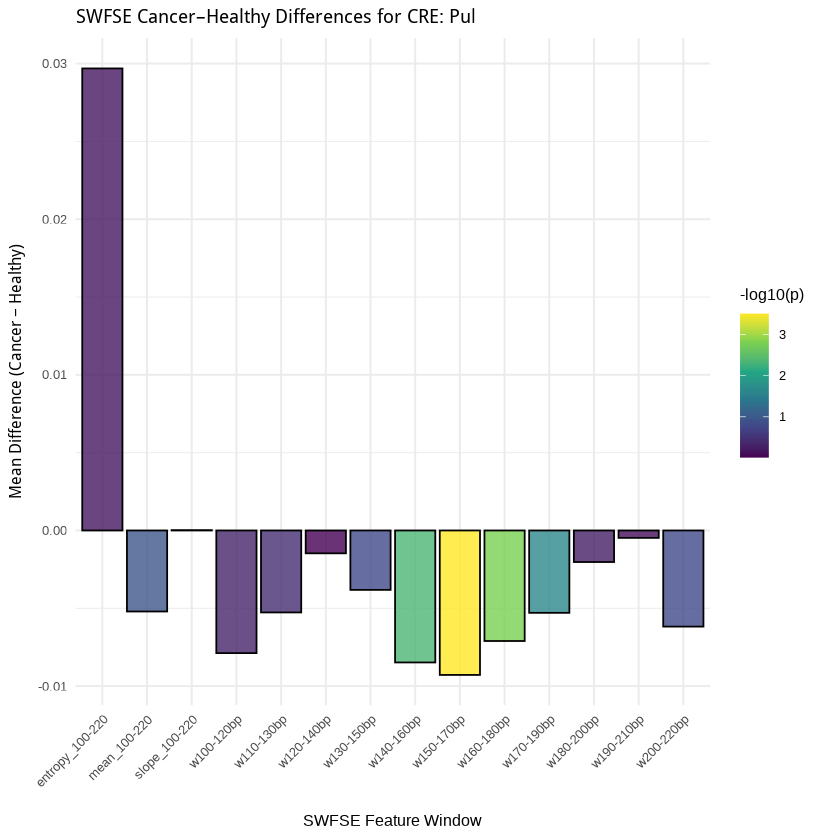

In [114]:
#!/usr/bin/env Rscript
# ===============================================================
# Compare cancer vs healthy for one CRE (Pulm) across SWFSE features
# ===============================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
})

# ---------------------------------------------------------------
# 1. Define the CRE pattern of interest
# ---------------------------------------------------------------
cre_pattern <- "Pul"   # <-- change this to any tissue keyword you want
swfse_cols <- grep(paste0("cre_swfse_.*", cre_pattern), names(lucas_df_swfse), value = TRUE)

cat("Found", length(swfse_cols), "SWFSE features containing:", cre_pattern, "\n\n")
if (length(swfse_cols) == 0) stop("No SWFSE features matched your pattern.")

# ---------------------------------------------------------------
# 2. Prepare long-form dataframe
# ---------------------------------------------------------------
df_long <- lucas_df_swfse %>%
  dplyr::select(id, type, dplyr::all_of(swfse_cols)) %>%
  tidyr::pivot_longer(
    cols = dplyr::all_of(swfse_cols),
    names_to = "Feature",
    values_to = "SWFSE_value"
  ) %>%
  dplyr::mutate(
    # Extract window descriptor (e.g., w140-160bp, mean, slope, entropy)
    Window = gsub(".*SWFSE_", "", Feature)
  ) %>%
  dplyr::filter(!is.na(SWFSE_value))

# ---------------------------------------------------------------
# 3. Run t-test, Wilcoxon, KS-test for each feature window
# ---------------------------------------------------------------
swfse_stats <- df_long %>%
  dplyr::group_by(Window) %>%
  dplyr::summarise(
    n_cancer  = sum(type == "cancer"),
    n_healthy = sum(type == "healthy"),
    mean_cancer  = mean(SWFSE_value[type == "cancer"], na.rm = TRUE),
    mean_healthy = mean(SWFSE_value[type == "healthy"], na.rm = TRUE),
    mean_diff = mean_cancer - mean_healthy,

    # t-test (parametric)
    t_p = tryCatch(t.test(SWFSE_value ~ type)$p.value, error = function(e) NA_real_),

    # Wilcoxon (nonparametric)
    wilcox_p = tryCatch(wilcox.test(SWFSE_value ~ type, exact = FALSE)$p.value, error = function(e) NA_real_),

    # KS-test (distributional)
    ks_p = tryCatch(ks.test(SWFSE_value[type == "cancer"],
                            SWFSE_value[type == "healthy"])$p.value,
                    error = function(e) NA_real_),

    .groups = "drop"
  ) %>%
  dplyr::mutate(
    t_FDR = p.adjust(t_p, method = "BH"),
    wilcox_FDR = p.adjust(wilcox_p, method = "BH"),
    ks_FDR = p.adjust(ks_p, method = "BH")
  ) %>%
  dplyr::arrange(wilcox_FDR)

# ---------------------------------------------------------------
# 4. Display results
# ---------------------------------------------------------------
cat("✅ Completed tests for all SWFSE windows in CRE:", cre_pattern, "\n\n")

print(
  swfse_stats %>%
    dplyr::select(Window, mean_cancer, mean_healthy, mean_diff,
                  t_p, t_FDR, wilcox_p, wilcox_FDR, ks_p, ks_FDR),
  n = Inf
)

# ---------------------------------------------------------------
# 5. Optional: simple visualization
# ---------------------------------------------------------------
library(ggplot2)
ggplot(swfse_stats, aes(x = Window, y = mean_diff, fill = -log10(wilcox_p))) +
  geom_col(color = "black", alpha = 0.8) +
  scale_fill_viridis_c(name = "-log10(p)") +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(
    title = paste0("SWFSE Cancer–Healthy Differences for CRE: ", cre_pattern),
    x = "SWFSE Feature Window",
    y = "Mean Difference (Cancer − Healthy)"
  )


In [134]:
#!/usr/bin/env Rscript
# ===============================================================
# Correlate rel_cov features (for a specific CRE) with ichor
# ===============================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
})

# ---------------------------------------------------------------
# 1. User parameters
# ---------------------------------------------------------------
cre_pattern  <- "Neuro"      # e.g. "Pulm", "Liver", "Vascular_endothelial"
group_filter <- "cancer"    # "cancer", "healthy", or NULL for all samples

# ---------------------------------------------------------------
# 2. Identify all rel_cov features matching the pattern
# ---------------------------------------------------------------
relcov_cols <- grep(paste0("^cre_relcov_.*", cre_pattern), names(lucas_df_final), value = TRUE)
cat("Found", length(relcov_cols), "rel_cov features containing:", cre_pattern, "\n")
if (length(relcov_cols) == 0) stop("No rel_cov features matched your pattern.")

# ---------------------------------------------------------------
# 3. Subset and filter samples with ichor
# ---------------------------------------------------------------
df_sub <- lucas_df_final %>%
  dplyr::select(id, type, ichor, dplyr::all_of(relcov_cols)) %>%
  dplyr::filter(!is.na(ichor))

if (!is.null(group_filter)) {
  df_sub <- df_sub %>% dplyr::filter(type == group_filter)
  cat("Subset:", group_filter, "samples =", nrow(df_sub), "with non-NA ichor\n")
} else {
  cat("Subset: all samples =", nrow(df_sub), "with non-NA ichor\n")
}

# ---------------------------------------------------------------
# 4. Reshape to long format
# ---------------------------------------------------------------
df_long <- df_sub %>%
  tidyr::pivot_longer(
    cols = dplyr::all_of(relcov_cols),
    names_to = "Feature",
    values_to = "rel_cov_value"
  ) %>%
  dplyr::mutate(
    CRE_full = sub("^cre_relcov_", "", Feature),
    Metric = str_extract(Feature, "rel_cov_[^_]+$")  # extract the metric type
  ) %>%
  dplyr::filter(!is.na(rel_cov_value))

# ---------------------------------------------------------------
# 5. Compute Pearson + Spearman correlations with ichor
# ---------------------------------------------------------------
corr_tbl <- df_long %>%
  dplyr::group_by(Feature) %>%
  dplyr::summarise(
    n_used = sum(!is.na(ichor) & !is.na(rel_cov_value)),
    pearson_r = suppressWarnings(cor(ichor, rel_cov_value, use = "pairwise.complete.obs", method = "pearson")),
    pearson_p = tryCatch(suppressWarnings(cor.test(ichor, rel_cov_value, method = "pearson")$p.value),
                         error = function(e) NA_real_),
    spearman_rho = suppressWarnings(cor(ichor, rel_cov_value, use = "pairwise.complete.obs", method = "spearman")),
    spearman_p = tryCatch(suppressWarnings(cor.test(ichor, rel_cov_value, method = "spearman")$p.value),
                          error = function(e) NA_real_),
    .groups = "drop"
  ) %>%
  dplyr::mutate(
    pearson_FDR  = p.adjust(pearson_p,  method = "BH"),
    spearman_FDR = p.adjust(spearman_p, method = "BH")
  ) %>%
  dplyr::arrange(dplyr::desc(abs(spearman_rho)))

# ---------------------------------------------------------------
# 6. Output results
# ---------------------------------------------------------------
cat("\n✅ Correlations with ichor for CRE pattern:", cre_pattern,
    ifelse(is.null(group_filter), " (all samples)\n", paste0(" (", group_filter, " only)\n")))

print(
  corr_tbl %>%
    dplyr::select(Feature, n_used,
                  pearson_r, pearson_p, pearson_FDR,
                  spearman_rho, spearman_p, spearman_FDR),
  n = Inf
)

# ---------------------------------------------------------------
# 7. OPTIONAL: visualize the strongest correlation
# ---------------------------------------------------------------
# library(ggplot2)
# top_feat <- corr_tbl$Feature[1]
# df_top <- df_long %>% dplyr::filter(Feature == top_feat)
# ggplot(df_top, aes(x = ichor, y = rel_cov_value)) +
#   geom_point(alpha = 0.7) +
#   geom_smooth(method = "lm", se = TRUE, linewidth = 0.8, color = "#1B9E77") +
#   theme_minimal(base_size = 13) +
#   labs(
#     title = paste0("rel_cov vs ichor — ", cre_pattern, "\n", top_feat),
#     x = "ichor (tumor fraction)",
#     y = "Relative coverage value"
#   )


Found 12 rel_cov features containing: Neuro 
Subset: cancer samples = 83 with non-NA ichor

✅ Correlations with ichor for CRE pattern: Neuro  (cancer only)
# A tibble: 12 × 8
   Feature        n_used pearson_r pearson_p pearson_FDR spearman_rho spearman_p
   <chr>           <int>     <dbl>     <dbl>       <dbl>        <dbl>      <dbl>
 1 cre_relcov_AT…     72    -0.251   0.0336       0.0673      -0.323     0.00591
 2 cre_relcov_AT…     72    -0.187   0.116        0.147       -0.291     0.0134 
 3 cre_relcov_AT…     72     0.333   0.00430      0.0149       0.182     0.125  
 4 cre_relcov_CR…     72    -0.126   0.291        0.291       -0.168     0.157  
 5 cre_relcov_AT…     72     0.363   0.00172      0.0149       0.149     0.213  
 6 cre_relcov_CR…     72     0.328   0.00498      0.0149       0.134     0.259  
 7 cre_relcov_AT…     72     0.333   0.00421      0.0149       0.120     0.314  
 8 cre_relcov_AT…     72     0.277   0.0186       0.0446       0.109     0.361  
 9 cre_relcov_C

In [135]:
corr_tbl

Feature,n_used,pearson_r,pearson_p,spearman_rho,spearman_p,pearson_FDR,spearman_FDR
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
cre_relcov_ATAC_filtered_final/Neuroendocrine_ATAC_final_summit.hg19_rel_cov_density,72,-0.2507288,0.033642534,-0.32265741,0.005907437,0.06728507,0.07088924
cre_relcov_ATAC_filtered_final/Neuroendocrine_ATAC_final_summit.hg19_rel_cov_profile,72,-0.1869450,0.115854061,-0.29101550,0.013400510,0.14720986,0.08040306
cre_relcov_ATAC_filtered_final/Neuronal_Glial_ATAC_final_summit.hg19_rel_cov_density,72,0.3326403,0.004304632,0.18245546,0.124880839,0.01493894,0.47212040
cre_relcov_CRE_overlaps_filtered_summit_final/Stromal_B-Neuroendocrine_overlap_ranges.hg19_rel_cov_profile,72,-0.1260620,0.291348886,-0.16827449,0.157373468,0.29134889,0.47212040
cre_relcov_ATAC_filtered_final/Neuronal_Glial_ATAC_final_summit.hg19_rel_cov_profile,72,0.3630161,0.001724183,0.14853045,0.212565473,0.01493894,0.50261989
cre_relcov_CRE_overlaps_filtered_summit_final/Neural-Neuronal_Glial_overlap_ranges.hg19_rel_cov_profile,72,0.3275177,0.004979646,0.13447810,0.259430995,0.01493894,0.50261989
cre_relcov_ATAC_filtered_final/Fetal_Neuronal_Glial_ATAC_final_summit.hg19_rel_cov_profile,72,0.3334228,0.004209003,0.12020066,0.313793608,0.01493894,0.50261989
cre_relcov_ATAC_filtered_final/Fetal_Neuronal_Glial_ATAC_final_summit.hg19_rel_cov_density,72,0.2767641,0.018597929,0.10894591,0.361495922,0.04463503,0.50261989
cre_relcov_CRE_overlaps_filtered_summit_final/Stromal_B-Neuroendocrine_overlap_ranges.hg19_rel_cov_density,72,-0.1956704,0.099511786,-0.10058525,0.399675757,0.14720986,0.50261989


In [136]:
#!/usr/bin/env Rscript
# ===============================================================
# t-test, Wilcoxon, KS-test for rel_cov_density (Cancer vs Healthy)
# ===============================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
})

# ---------------------------------------------------------------
# 1. Identify rel_cov_density columns
# ---------------------------------------------------------------
relcov_density_cols <- grep("cre_relcov_.*rel_cov_density$", names(lucas_df_final), value = TRUE)
cat("Found", length(relcov_density_cols), "rel_cov_density features\n\n")
if (length(relcov_density_cols) == 0) stop("No rel_cov_density features found. Check naming pattern.")

# ---------------------------------------------------------------
# 2. Reshape into long format
# ---------------------------------------------------------------
df_long <- lucas_df_final %>%
  dplyr::select(id, type, dplyr::all_of(relcov_density_cols)) %>%
  tidyr::pivot_longer(
    cols = dplyr::all_of(relcov_density_cols),
    names_to = "CRE_feature",
    values_to = "rel_cov_density"
  ) %>%
  dplyr::mutate(
    CRE_name = gsub("cre_relcov_", "", CRE_feature),
    CRE_name = gsub("_rel_cov_density$", "", CRE_name)
  ) %>%
  dplyr::filter(!is.na(rel_cov_density))

# ---------------------------------------------------------------
# 3. Run tests per CRE
# ---------------------------------------------------------------
stats_table <- df_long %>%
  dplyr::group_by(CRE_name) %>%
  dplyr::summarise(
    n_cancer  = sum(type == "cancer"),
    n_healthy = sum(type == "healthy"),
    mean_cancer  = mean(rel_cov_density[type == "cancer"],  na.rm = TRUE),
    mean_healthy = mean(rel_cov_density[type == "healthy"], na.rm = TRUE),
    mean_diff = mean_cancer - mean_healthy,

    # t-test
    t_p = tryCatch(t.test(rel_cov_density ~ type)$p.value, error = function(e) NA_real_),

    # Wilcoxon (nonparametric)
    wilcox_p = tryCatch(wilcox.test(rel_cov_density ~ type, exact = FALSE)$p.value, error = function(e) NA_real_),

    # KS-test
    ks_p = tryCatch(ks.test(rel_cov_density[type == "cancer"],
                            rel_cov_density[type == "healthy"])$p.value,
                    error = function(e) NA_real_),

    .groups = "drop"
  ) %>%
  dplyr::mutate(
    t_FDR = p.adjust(t_p, method = "BH"),
    wilcox_FDR = p.adjust(wilcox_p, method = "BH"),
    ks_FDR = p.adjust(ks_p, method = "BH")
  ) %>%
  dplyr::arrange(wilcox_FDR)

# ---------------------------------------------------------------
# 4. Output table
# ---------------------------------------------------------------
cat("✅ Completed rel_cov_density comparisons (Cancer vs Healthy)\n\n")

print(
  stats_table %>%
    dplyr::select(CRE_name, mean_cancer, mean_healthy, mean_diff,
                  t_p, t_FDR, wilcox_p, wilcox_FDR, ks_p, ks_FDR),
  n = 20
)

# ---------------------------------------------------------------
# 5. Summary stats
# ---------------------------------------------------------------
cat("\n\nSummary Statistics:\n")
cat("Significant (FDR<0.05, Wilcoxon):", sum(stats_table$wilcox_FDR < 0.05, na.rm = TRUE), "\n")
cat("Significant (FDR<0.05, t-test):",   sum(stats_table$t_FDR < 0.05, na.rm = TRUE), "\n")
cat("Significant (FDR<0.05, KS-test):",  sum(stats_table$ks_FDR < 0.05, na.rm = TRUE), "\n")
cat("Top absolute mean differences:\n")
print(stats_table %>% dplyr::arrange(dplyr::desc(abs(mean_diff))) %>% head(10))

# ---------------------------------------------------------------
# 6. Optional: save results
# ---------------------------------------------------------------
# readr::write_csv(stats_table, "relcov_density_cancer_vs_healthy_results.csv")


Found 89 rel_cov_density features

✅ Completed rel_cov_density comparisons (Cancer vs Healthy)

# A tibble: 89 × 10
   CRE_name          mean_cancer mean_healthy mean_diff     t_p   t_FDR wilcox_p
   <chr>                   <dbl>        <dbl>     <dbl>   <dbl>   <dbl>    <dbl>
 1 ATAC_filtered_fi…        1.16         1.18  -0.0156  5.50e-8 4.90e-6  2.64e-7
 2 ATAC_filtered_fi…        1.18         1.19  -0.0148  1.14e-7 5.05e-6  1.97e-7
 3 ATAC_filtered_fi…        1.19         1.20  -0.0128  2.35e-6 4.20e-5  1.90e-6
 4 ATAC_filtered_fi…        1.19         1.21  -0.0159  2.19e-6 4.20e-5  4.03e-6
 5 TCGA_filtered_fi…        1.18         1.19  -0.0129  2.36e-6 4.20e-5  5.46e-6
 6 DHS_filtered_fin…        1.21         1.22  -0.00850 2.15e-5 2.73e-4  1.16e-5
 7 CRE_overlaps_fil…        1.20         1.21  -0.0151  3.64e-5 3.31e-4  1.79e-5
 8 TCGA_filtered_fi…        1.17         1.18  -0.00820 1.10e-4 6.55e-4  1.73e-5
 9 CRE_overlaps_fil…        1.20         1.22  -0.0194  1.03e-5 1.53e-4  2

In [137]:
stats_table

CRE_name,n_cancer,n_healthy,mean_cancer,mean_healthy,mean_diff,t_p,wilcox_p,ks_p,t_FDR,wilcox_FDR,ks_FDR
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ATAC_filtered_final/GI_Epithelial_ATAC_final_summit.hg19,113,136,1.163028,1.178649,-0.015621594,5.504301e-08,2.642893e-07,3.960373e-05,4.898828e-06,1.176087e-05,0.0008811831
ATAC_filtered_final/Neuroendocrine_ATAC_final_summit.hg19,113,136,1.178604,1.193389,-0.014785064,1.135467e-07,1.970836e-07,1.907757e-05,5.052829e-06,1.176087e-05,0.0008811831
ATAC_filtered_final/Pulm_Epithelial_ATAC_final_summit.hg19,113,136,1.186877,1.199668,-0.012791317,2.352132e-06,1.900040e-06,7.631212e-05,4.196743e-05,5.636784e-05,0.0009350928
ATAC_filtered_final/Skin_Mammary_Epithelial_ATAC_final_summit.hg19,113,136,1.193272,1.209179,-0.015907497,2.192871e-06,4.026308e-06,8.102016e-05,4.196743e-05,8.958534e-05,0.0009350928
TCGA_filtered_final/LUAD-ATAC-Final.hg19,113,136,1.175652,1.188585,-0.012933011,2.357721e-06,5.457214e-06,4.553683e-04,4.196743e-05,9.713841e-05,0.0025329860
DHS_filtered_final/Cancer_epithelial_DHS_final_summit.hg19,113,136,1.214239,1.222736,-0.008497595,2.147127e-05,1.156815e-05,2.985548e-05,2.729919e-04,1.715942e-04,0.0008811831
CRE_overlaps_filtered_summit_final/Vascular_endothelial-Endothelial_overlap_ranges.hg19,113,136,1.197077,1.212207,-0.015130427,3.637523e-05,1.785628e-05,7.845179e-05,3.310633e-04,1.986511e-04,0.0009350928
TCGA_filtered_final/Lung-ATAC-Final.hg19,113,136,1.169192,1.177394,-0.008202372,1.101525e-04,1.729641e-05,5.916080e-04,6.548939e-04,1.986511e-04,0.0027712164
CRE_overlaps_filtered_summit_final/Cancer_epithelial-Skin_Mammary_Epithelial_overlap_ranges.hg19,113,136,1.196119,1.215505,-0.019385367,1.029621e-05,2.607286e-05,1.265088e-04,1.527271e-04,2.578316e-04,0.0012510314


In [138]:
#!/usr/bin/env Rscript
# ===============================================================
# Rank-based comparison (Cancer vs Healthy) for rel_cov_density
# ===============================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(matrixStats)  # fast row-wise ranking
})

# ---------------------------------------------------------------
# 1) Identify rel_cov_density features
# ---------------------------------------------------------------
relcov_density_cols <- grep("cre_relcov_.*rel_cov_density$", names(lucas_df_final), value = TRUE)
cat("Found", length(relcov_density_cols), "rel_cov_density features\n\n")
if (length(relcov_density_cols) == 0) stop("No rel_cov_density columns found. Check naming pattern.")

# ---------------------------------------------------------------
# 2) Build feature matrix and compute within-sample ranks
#    (higher density -> higher rank; NAs stay NA and are ignored later)
# ---------------------------------------------------------------
X <- as.matrix(lucas_df_final[, relcov_density_cols])
R <- matrixStats::rowRanks(X, ties.method = "average")  # ranks per sample (row)
colnames(R) <- relcov_density_cols
rownames(R) <- lucas_df_final$id

ranked_df <- cbind(
  lucas_df_final %>% dplyr::select(id, type),
  as.data.frame(R)
)

cat("✅ Computed within-sample ranks for rel_cov_density features\n")

# ---------------------------------------------------------------
# 3) Long format of ranks
# ---------------------------------------------------------------
ranks_long <- ranked_df %>%
  tidyr::pivot_longer(
    cols = dplyr::all_of(relcov_density_cols),
    names_to = "CRE_feature",
    values_to = "rank_value"
  ) %>%
  dplyr::mutate(
    CRE_name = gsub("cre_relcov_", "", CRE_feature),
    CRE_name = gsub("_rel_cov_density$", "", CRE_name)
  )

# ---------------------------------------------------------------
# 4) Per-CRE group stats on ranks + Wilcoxon on ranks
# ---------------------------------------------------------------
rank_stats <- ranks_long %>%
  dplyr::group_by(CRE_name) %>%
  dplyr::summarise(
    n_cancer  = sum(type == "cancer"  & !is.na(rank_value)),
    n_healthy = sum(type == "healthy" & !is.na(rank_value)),
    mean_rank_cancer  = mean(rank_value[type == "cancer"],  na.rm = TRUE),
    mean_rank_healthy = mean(rank_value[type == "healthy"], na.rm = TRUE),
    rank_diff = mean_rank_cancer - mean_rank_healthy,
    wilcox_p  = tryCatch(
      wilcox.test(rank_value ~ type, exact = FALSE)$p.value,
      error = function(e) NA_real_
    ),
    .groups = "drop"
  ) %>%
  dplyr::mutate(
    wilcox_FDR = p.adjust(wilcox_p, method = "BH")
  ) %>%
  dplyr::arrange(wilcox_FDR, dplyr::desc(abs(rank_diff)))

# ---------------------------------------------------------------
# 5) Output
# ---------------------------------------------------------------
cat("Top CREs by FDR (rank-based Wilcoxon on within-sample ranks):\n")
print(
  rank_stats %>%
    dplyr::select(CRE_name, n_cancer, n_healthy,
                  mean_rank_cancer, mean_rank_healthy, rank_diff,
                  wilcox_p, wilcox_FDR) %>%
    head(25),
  n = 25
)

cat("\nSummary:\n")
cat("Significant (FDR < 0.05):", sum(rank_stats$wilcox_FDR < 0.05, na.rm = TRUE), "\n")
cat("Median |rank_diff|:", median(abs(rank_stats$rank_diff), na.rm = TRUE), "\n")

# ---------------------------------------------------------------
# 6) OPTIONAL: Tissue-level aggregation (power boost)
#     Parses tissue label from the CRE path and tests mean ranks per tissue
# ---------------------------------------------------------------
tissue_rank_stats <- ranks_long %>%
  dplyr::mutate(
    tissue = sub("^.*?/", "", CRE_name) |> 
             sub("_ATAC_final_summit\\.hg19.*|_DHS_final_summit\\.hg19.*|_overlap_ranges\\.hg19.*", "", x = _) |>
             gsub("-", "_", .)
  ) %>%
  dplyr::group_by(id, type, tissue) %>%
  dplyr::summarise(sample_mean_rank = mean(rank_value, na.rm = TRUE), .groups = "drop") %>%
  dplyr::group_by(tissue) %>%
  dplyr::summarise(
    n_cancer  = sum(type == "cancer"  & !is.na(sample_mean_rank)),
    n_healthy = sum(type == "healthy" & !is.na(sample_mean_rank)),
    mean_rank_cancer  = mean(sample_mean_rank[type == "cancer"],  na.rm = TRUE),
    mean_rank_healthy = mean(sample_mean_rank[type == "healthy"], na.rm = TRUE),
    rank_diff = mean_rank_cancer - mean_rank_healthy,
    wilcox_p  = tryCatch(
      wilcox.test(sample_mean_rank ~ type, exact = FALSE)$p.value,
      error = function(e) NA_real_
    ),
    .groups = "drop"
  ) %>%
  dplyr::mutate(wilcox_FDR = p.adjust(wilcox_p, method = "BH")) %>%
  dplyr::arrange(wilcox_FDR, dplyr::desc(abs(rank_diff)))

cat("\nTissue-level rank-based results (optional):\n")
print(
  tissue_rank_stats %>%
    dplyr::select(tissue, n_cancer, n_healthy,
                  mean_rank_cancer, mean_rank_healthy, rank_diff,
                  wilcox_p, wilcox_FDR) %>%
    head(25),
  n = 25
)

# ---------------------------------------------------------------
# 7) OPTIONAL: Save tables
# ---------------------------------------------------------------
# readr::write_csv(rank_stats, "rank_relcov_density_perCRE.csv")
# readr::write_csv(tissue_rank_stats, "rank_relcov_density_perTissue.csv")


Found 89 rel_cov_density features

✅ Computed within-sample ranks for rel_cov_density features
Top CREs by FDR (rank-based Wilcoxon on within-sample ranks):
# A tibble: 25 × 8
   CRE_name      n_cancer n_healthy mean_rank_cancer mean_rank_healthy rank_diff
   <chr>            <int>     <int>            <dbl>             <dbl>     <dbl>
 1 ATAC_filtere…      113       136            65.5              72.1     -6.54 
 2 ATAC_filtere…      113       136            38.1              44.4     -6.28 
 3 DHS_filtered…      113       136            49.9              42.1      7.76 
 4 DHS_filtered…      113       136            46.3              40.6      5.68 
 5 ATAC_filtere…      113       136            52.8              59.2     -6.41 
 6 ATAC_filtere…      113       136            60.0              65.7     -5.68 
 7 ATAC_filtere…      113       136            19.7              14.9      4.82 
 8 DHS_filtered…      113       136            69.7              65.1      4.57 
 9 CRE_overlap

Warning message:
“There was 1 warning in `dplyr::mutate()`.
ℹ In argument: `tissue = gsub(...)`.
Caused by warning in `gsub()`:
! argument 'pattern' has length > 1 and only the first element will be used”



Tissue-level rank-based results (optional):
# A tibble: 1 × 8
  tissue n_cancer n_healthy mean_rank_cancer mean_rank_healthy rank_diff
  <chr>     <int>     <int>            <dbl>             <dbl>     <dbl>
1 _           113       136               45                45         0
# ℹ 2 more variables: wilcox_p <dbl>, wilcox_FDR <dbl>


In [142]:
#!/usr/bin/env Rscript
# ===============================================================
# Robust Z-score normalization within sample + cancer vs healthy comparison
# (for rel_cov_density features)
# ===============================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(matrixStats)
})

# ---------------------------------------------------------------
# 1. Identify rel_cov_density columns
# ---------------------------------------------------------------
relcov_cols <- grep("cre_relcov_.*rel_cov_density$", names(lucas_df_final), value = TRUE)
cat("Found", length(relcov_cols), "rel_cov_density features\n\n")
stopifnot(length(relcov_cols) > 0)

# ---------------------------------------------------------------
# 2. Compute robust Z-scores within each sample
# ---------------------------------------------------------------
X <- as.matrix(lucas_df_final[, relcov_cols])
row_meds <- matrixStats::rowMedians(X, na.rm = TRUE)
row_mads <- matrixStats::rowMads(X, na.rm = TRUE)

X_rz <- sweep(sweep(X, 1, row_meds, "-"), 1, row_mads + 1e-8, "/")
X_rz[!is.finite(X_rz)] <- NA

rz_df <- cbind(lucas_df_final %>% dplyr::select(id, type),
               as.data.frame(X_rz))

cat("✅ Per-sample robust Z normalization complete.\n")

# ---------------------------------------------------------------
# 3. Reshape for per-feature group comparison
# ---------------------------------------------------------------
df_long <- rz_df %>%
  tidyr::pivot_longer(
    cols = dplyr::all_of(relcov_cols),
    names_to = "CRE_feature",
    values_to = "Z_value"
  ) %>%
  dplyr::mutate(
    CRE_name = gsub("cre_relcov_", "", CRE_feature),
    CRE_name = gsub("_rel_cov_density$", "", CRE_name)
  ) %>%
  dplyr::filter(!is.na(Z_value))

# ---------------------------------------------------------------
# 4. Compare cancer vs healthy (t-test, Wilcoxon, KS)
# ---------------------------------------------------------------
stats_table <- df_long %>%
  dplyr::group_by(CRE_name) %>%
  dplyr::summarise(
    n_cancer  = sum(type == "cancer"),
    n_healthy = sum(type == "healthy"),
    mean_cancer  = mean(Z_value[type == "cancer"],  na.rm = TRUE),
    mean_healthy = mean(Z_value[type == "healthy"], na.rm = TRUE),
    mean_diff = mean_cancer - mean_healthy,

    t_p = tryCatch(t.test(Z_value ~ type)$p.value, error = function(e) NA_real_),
    wilcox_p = tryCatch(wilcox.test(Z_value ~ type, exact = FALSE)$p.value, error = function(e) NA_real_),
    ks_p = tryCatch(ks.test(Z_value[type == "cancer"], Z_value[type == "healthy"])$p.value,
                    error = function(e) NA_real_),

    .groups = "drop"
  ) %>%
  dplyr::mutate(
    t_FDR = p.adjust(t_p, method = "BH"),
    wilcox_FDR = p.adjust(wilcox_p, method = "BH"),
    ks_FDR = p.adjust(ks_p, method = "BH")
  ) %>%
  dplyr::arrange(wilcox_FDR)

# ---------------------------------------------------------------
# 5. Output
# ---------------------------------------------------------------
cat("✅ Cancer vs Healthy comparison after robust Z normalization\n\n")
print(
  stats_table %>%
    dplyr::select(CRE_name, mean_cancer, mean_healthy, mean_diff,
                  t_p, t_FDR, wilcox_p, wilcox_FDR, ks_p, ks_FDR) %>%
    head(25),
  n = 25
)

cat("\nSummary:\n")
cat("Significant (FDR<0.05, Wilcoxon):", sum(stats_table$wilcox_FDR < 0.05, na.rm = TRUE), "\n")
cat("Significant (FDR<0.05, t-test):",   sum(stats_table$t_FDR < 0.05, na.rm = TRUE), "\n")
cat("Significant (FDR<0.05, KS-test):",  sum(stats_table$ks_FDR < 0.05, na.rm = TRUE), "\n")

# ---------------------------------------------------------------
# 6. Optional: save results
# ---------------------------------------------------------------
# readr::write_csv(stats_table, "robustZ_relcov_density_cancer_vs_healthy.csv")


Found 89 rel_cov_density features

✅ Per-sample robust Z normalization complete.


Warning message:
“There were 42 warnings in `dplyr::summarise()`.
The first warning was:
ℹ In argument: `ks_p = tryCatch(...)`.
ℹ In group 1: `CRE_name = "ATAC_filtered_final/Adrenal_Cortical_ATAC_final_summit.hg19"`.
Caused by warning in `ks.test.default()`:
! p-value will be approximate in the presence of ties
ℹ Run `dplyr::last_dplyr_warnings()` to see the 41 remaining warnings.”


✅ Cancer vs Healthy comparison after robust Z normalization

# A tibble: 25 × 10
   CRE_name          mean_cancer mean_healthy mean_diff     t_p   t_FDR wilcox_p
   <chr>                   <dbl>        <dbl>     <dbl>   <dbl>   <dbl>    <dbl>
 1 ATAC_filtered_fi…     -0.223       -0.0170   -0.206  1.31e-6 1.17e-4  1.42e-6
 2 ATAC_filtered_fi…      0.620        0.859    -0.240  2.89e-6 1.29e-4  1.30e-5
 3 DHS_filtered_fin…      0.156       -0.106     0.262  5.73e-6 1.70e-4  9.67e-6
 4 ATAC_filtered_fi…      0.202        0.393    -0.191  1.61e-5 3.59e-4  1.84e-5
 5 DHS_filtered_fin…      0.0302      -0.137     0.167  9.34e-4 1.04e-2  3.87e-5
 6 ATAC_filtered_fi…      0.425        0.575    -0.150  1.41e-4 2.50e-3  5.00e-4
 7 DHS_filtered_fin…      0.794        0.612     0.182  5.70e-4 7.25e-3  6.71e-4
 8 CRE_overlaps_fil…      0.700        1.03     -0.331  4.33e-4 6.42e-3  8.24e-4
 9 ATAC_filtered_fi…     -1.09        -1.36      0.267  1.32e-3 1.25e-2  2.52e-3
10 CRE_overlaps_fil…      0.

In [143]:
stats_table

CRE_name,n_cancer,n_healthy,mean_cancer,mean_healthy,mean_diff,t_p,wilcox_p,ks_p,t_FDR,wilcox_FDR,ks_FDR
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ATAC_filtered_final/GI_Epithelial_ATAC_final_summit.hg19,113,136,-0.22261871,-0.01703137,-0.20558734,1.313074e-06,1.420505e-06,1.870593e-05,0.0001168636,0.0001264249,0.001664828
ATAC_filtered_final/Skin_Mammary_Epithelial_ATAC_final_summit.hg19,113,136,0.61976059,0.85939119,-0.23963059,2.890670e-06,1.295698e-05,7.260505e-04,0.0001286348,0.0003843905,0.012765331
DHS_filtered_final/Myeloid_erythroid_DHS_final_summit.hg19,113,136,0.15637977,-0.10605136,0.26243113,5.727589e-06,9.665483e-06,8.605841e-04,0.0001699185,0.0003843905,0.012765331
ATAC_filtered_final/Neuroendocrine_ATAC_final_summit.hg19,113,136,0.20197808,0.39260813,-0.19063005,1.612762e-05,1.843269e-05,2.916800e-04,0.0003588395,0.0004101274,0.011416267
DHS_filtered_final/Lymphoid_DHS_final_summit.hg19,113,136,0.03015636,-0.13722094,0.16737729,9.344732e-04,3.868609e-05,3.848180e-04,0.0103960147,0.0006886124,0.011416267
ATAC_filtered_final/Pulm_Epithelial_ATAC_final_summit.hg19,113,136,0.42542918,0.57493518,-0.14950600,1.405525e-04,5.000853e-04,6.114199e-04,0.0025018337,0.0074179323,0.012765331
DHS_filtered_final/Pulmonary_devel_DHS_final_summit.hg19,113,136,0.79395771,0.61208926,0.18186845,5.699274e-04,6.709517e-04,8.340087e-03,0.0072462199,0.0085306713,0.069798287
CRE_overlaps_filtered_summit_final/Cancer_epithelial-Skin_Mammary_Epithelial_overlap_ranges.hg19,113,136,0.70043091,1.03128956,-0.33085865,4.327387e-04,8.239298e-04,1.300376e-02,0.0064189572,0.0091662188,0.089025733
ATAC_filtered_final/Immune_ATAC_final_summit.hg19,113,136,-1.08857318,-1.35597478,0.26740160,1.316197e-03,2.517659e-03,2.011282e-03,0.0125134464,0.0217171232,0.022375512


## Comparing Healthy and Cancer

In [54]:
library(dplyr)
library(tidyr)

# Get all CRE rel_cov_profile columns
cre_profile_cols <- grep("cre_relcov_.*_rel_cov_profile$", 
                          names(lucas_df_final), 
                          value = TRUE)

cat("Found", length(cre_profile_cols), "CRE rel_cov_profile features\n\n")

# Calculate mean scores by cancer vs healthy
comparison_stats <- lucas_df_final %>%
  group_by(type) %>%
  summarise(
    n_samples = n(),
    across(all_of(cre_profile_cols), 
           ~mean(.x, na.rm = TRUE),
           .names = "{.col}")
  )

# Reshape for easier comparison
comparison_long <- comparison_stats %>%
  pivot_longer(cols = all_of(cre_profile_cols),
               names_to = "CRE_feature",
               values_to = "mean_rel_cov_profile") %>%
  mutate(CRE_name = gsub("cre_relcov_", "", CRE_feature),
         CRE_name = gsub("_rel_cov_profile$", "", CRE_name))

# Create side-by-side comparison
comparison_wide <- comparison_long %>%
  dplyr::select(CRE_name, type, mean_rel_cov_profile) %>%
  pivot_wider(names_from = type, 
              values_from = mean_rel_cov_profile) %>%
  mutate(
    difference = cancer - healthy,
    fold_change = cancer / (healthy + 1e-8),
    abs_diff = abs(difference)
  ) %>%
  arrange(desc(abs_diff))

# Display results
cat("Sample sizes:\n")
print(comparison_stats %>% dplyr::select(type, n_samples))

cat("\n\nTop CREs by absolute difference (cancer vs healthy):\n")
print(comparison_wide %>% 
        dplyr::select(CRE_name, healthy, cancer, difference, fold_change) %>%
        head(20), 
      n = 20)

# Summary statistics
cat("\n\nSummary Statistics:\n")
cat("Mean difference:", mean(comparison_wide$difference, na.rm = TRUE), "\n")
cat("Median difference:", median(comparison_wide$difference, na.rm = TRUE), "\n")
cat("CREs higher in cancer:", sum(comparison_wide$difference > 0, na.rm = TRUE), "\n")
cat("CREs higher in healthy:", sum(comparison_wide$difference < 0, na.rm = TRUE), "\n")

# Optional: Save the comparison
# write_csv(comparison_wide, "cre_cancer_vs_healthy_comparison.csv")

Found 89 CRE rel_cov_profile features

Sample sizes:
# A tibble: 2 × 2
  type    n_samples
  <chr>       <int>
1 cancer        129
2 healthy       158


Top CREs by absolute difference (cancer vs healthy):
# A tibble: 20 × 5
   CRE_name                                healthy cancer difference fold_change
   <chr>                                     <dbl>  <dbl>      <dbl>       <dbl>
 1 CRE_overlaps_filtered_summit_final/Pla…   1.04   1.02     -0.0216       0.979
 2 DHS_filtered_final/Primitive_embryonic…   0.954  0.932    -0.0213       0.978
 3 CRE_overlaps_filtered_summit_final/Vas…   1.11   1.10     -0.0180       0.984
 4 ATAC_filtered_final/GI_Epithelial_ATAC…   1.08   1.06     -0.0170       0.984
 5 ATAC_filtered_final/Skin_Mammary_Epith…   1.11   1.09     -0.0166       0.985
 6 ATAC_filtered_final/Placental_ATAC_fin…   1.00   0.988    -0.0163       0.984
 7 CRE_overlaps_filtered_summit_final/Neu…   1.10   1.09     -0.0157       0.986
 8 ATAC_filtered_final/Neuroendocrine_ATA…   1

In [63]:
library(dplyr)
library(tidyr)

# Get all CRE rel_cov_profile columns
cre_profile_cols <- grep("cre_relcov_.*_rel_cov_profile$", 
                          names(lucas_df_final), 
                          value = TRUE)

cat("Found", length(cre_profile_cols), "CRE rel_cov_profile features\n\n")

# Calculate mean scores by cancer vs healthy
comparison_stats <- lucas_df_final %>%
  group_by(type) %>%
  summarise(
    n_samples = n(),
    across(all_of(cre_profile_cols), 
           ~mean(.x, na.rm = TRUE),
           .names = "{.col}")
  )

# Reshape for easier comparison
comparison_long <- comparison_stats %>%
  pivot_longer(cols = all_of(cre_profile_cols),
               names_to = "CRE_feature",
               values_to = "mean_rel_cov_profile") %>%
  mutate(CRE_name = gsub("cre_relcov_", "", CRE_feature),
         CRE_name = gsub("_rel_cov_profile$", "", CRE_name))

# Create side-by-side comparison - RANKED BY RELATIVE DIFFERENCE
comparison_wide <- comparison_long %>%
  dplyr::select(CRE_name, type, mean_rel_cov_profile) %>%
  pivot_wider(names_from = type, 
              values_from = mean_rel_cov_profile) %>%
  mutate(
    difference = cancer - healthy,
    fold_change = cancer / (healthy + 1e-8),
    # Percent change relative to healthy baseline
    percent_change = ((cancer - healthy) / (healthy + 1e-8)) * 100,
    abs_percent_change = abs(percent_change)
  ) %>%
  arrange(desc(abs_percent_change))  # RANK BY RELATIVE DIFFERENCE

# Display results
cat("Sample sizes:\n")
print(comparison_stats %>% dplyr::select(type, n_samples))

cat("\n\nTop CREs by RELATIVE rel_cov_profile difference (cancer vs healthy):\n")
print(comparison_wide %>% 
        dplyr::select(CRE_name, healthy, cancer, difference, percent_change, fold_change) %>%
        head(20), 
      n = 20)

# Summary statistics
cat("\n\nSummary Statistics:\n")
cat("Mean percent change:", mean(comparison_wide$percent_change, na.rm = TRUE), "%\n")
cat("Median percent change:", median(comparison_wide$percent_change, na.rm = TRUE), "%\n")
cat("CREs higher in cancer:", sum(comparison_wide$difference > 0, na.rm = TRUE), "\n")
cat("CREs higher in healthy:", sum(comparison_wide$difference < 0, na.rm = TRUE), "\n")
cat("CREs with >25% increase in cancer:", sum(comparison_wide$percent_change > 25, na.rm = TRUE), "\n")
cat("CREs with >25% decrease in cancer:", sum(comparison_wide$percent_change < -25, na.rm = TRUE), "\n")

# Optional: Save the comparison
# write_csv(comparison_wide, "cre_relcov_cancer_vs_healthy_comparison.csv")

Found 89 CRE rel_cov_profile features

Sample sizes:
# A tibble: 2 × 2
  type    n_samples
  <chr>       <int>
1 cancer        129
2 healthy       158


Top CREs by RELATIVE rel_cov_profile difference (cancer vs healthy):
# A tibble: 20 × 6
   CRE_name                 healthy cancer difference percent_change fold_change
   <chr>                      <dbl>  <dbl>      <dbl>          <dbl>       <dbl>
 1 CRE_overlaps_filtered_s…   0.380  0.367   -0.0123           -3.24       0.968
 2 ATAC_filtered_final/Ubi…   0.436  0.422   -0.0140           -3.20       0.968
 3 TCGA_filtered_final/TCG…   0.386  0.375   -0.0110           -2.84       0.972
 4 TCGA_filtered_final/Pan…   0.366  0.356   -0.00994          -2.71       0.973
 5 DHS_filtered_final/Prim…   0.955  0.933   -0.0219           -2.29       0.977
 6 CRE_overlaps_filtered_s…   1.04   1.02    -0.0235           -2.26       0.977
 7 CRE_overlaps_filtered_s…   1.12   1.09    -0.0213           -1.91       0.981
 8 TCGA_filtered_final/TGC…   

In [65]:
comparison_wide

CRE_name,cancer,healthy,difference,fold_change,percent_change,abs_percent_change
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CRE_overlaps_filtered_summit_final/Tissue_invariant-Ubiquitous_overlap_ranges.hg19,0.3672801,0.3795678,-0.012287779,0.9676269,-3.237308,3.237308
ATAC_filtered_final/Ubiquitous_ATAC_final_summit.hg19,0.4223440,0.4363235,-0.013979505,0.9679607,-3.203931,3.203931
TCGA_filtered_final/TCGA-ATAC-Final.hg19,0.3750043,0.3859578,-0.010953480,0.9716200,-2.838000,2.838000
TCGA_filtered_final/PanCancer-ATAC-Final.hg19,0.3564147,0.3663549,-0.009940233,0.9728672,-2.713280,2.713280
DHS_filtered_final/Primitive_embryonic_DHS_final_summit.hg19,0.9333502,0.9552069,-0.021856656,0.9771184,-2.288159,2.288159
CRE_overlaps_filtered_summit_final/Placental_trophoblast-Placental_overlap_ranges.hg19,1.0188713,1.0424081,-0.023536737,0.9774208,-2.257920,2.257920
CRE_overlaps_filtered_summit_final/Vascular_endothelial-Endothelial_overlap_ranges.hg19,1.0947915,1.1161089,-0.021317343,0.9809003,-1.909970,1.909970
TCGA_filtered_final/TGCT-ATAC-Final.hg19,0.9398419,0.9566103,-0.016768468,0.9824709,-1.752905,1.752905
TCGA_filtered_final/Germ-ATAC-Final.hg19,0.9393221,0.9557979,-0.016475887,0.9827622,-1.723783,1.723783


In [74]:
library(dplyr)
library(tidyr)

# Get all CRE rel_cov_profile columns
cre_relcov_cols <- grep("cre_relcov_.*_rel_cov_profile$", 
                        names(lucas_df_final), 
                        value = TRUE)

cat("Found", length(cre_relcov_cols), "CRE rel_cov_profile features\n\n")

# Check if ichor column exists
if (!"ichor" %in% names(lucas_df_final)) {
  stop("'ichor' column not found in lucas_df_final")
}

# Calculate correlations between ichor and each CRE rel_cov_profile feature
correlation_results <- lucas_df_final %>%
  dplyr::select(ichor, all_of(cre_relcov_cols)) %>%
  # Remove rows where ichor is NA
  filter(!is.na(ichor)) %>%
  # Calculate correlation for each CRE feature
  summarise(across(all_of(cre_relcov_cols),
                   ~cor(.x, ichor, use = "pairwise.complete.obs"),
                   .names = "{.col}")) %>%
  # Reshape to long format
  pivot_longer(cols = everything(),
               names_to = "CRE_feature",
               values_to = "correlation") %>%
  mutate(
    CRE_name = gsub("cre_relcov_", "", CRE_feature),
    CRE_name = gsub("_rel_cov_profile$", "", CRE_name),
    abs_correlation = abs(correlation)
  ) %>%
  arrange(desc(abs_correlation))

# Display results
cat("Samples with non-NA ichor:", sum(!is.na(lucas_df_final$ichor)), "\n")
cat("Ichor range:", min(lucas_df_final$ichor, na.rm = TRUE), "to", 
    max(lucas_df_final$ichor, na.rm = TRUE), "\n\n")

cat("Top CREs by absolute correlation with ichor (tumor fraction):\n")
print(correlation_results %>% 
        dplyr::select(CRE_name, correlation, abs_correlation) %>%
        head(20), 
      n = 20)

# Summary statistics
cat("\n\nCorrelation Summary:\n")
cat("Mean absolute correlation:", mean(correlation_results$abs_correlation, na.rm = TRUE), "\n")
cat("Median absolute correlation:", median(correlation_results$abs_correlation, na.rm = TRUE), "\n")
cat("Strongest positive correlation:", max(correlation_results$correlation, na.rm = TRUE), "\n")
cat("Strongest negative correlation:", min(correlation_results$correlation, na.rm = TRUE), "\n")
cat("CREs with |r| > 0.3:", sum(correlation_results$abs_correlation > 0.3, na.rm = TRUE), "\n")
cat("CREs with |r| > 0.5:", sum(correlation_results$abs_correlation > 0.5, na.rm = TRUE), "\n")

# Optional: Save results
# write_csv(correlation_results, "ichor_relcov_correlations.csv")

Found 89 CRE rel_cov_profile features

Samples with non-NA ichor: 205 
Ichor range: 0 to 81.42 

Top CREs by absolute correlation with ichor (tumor fraction):
# A tibble: 20 × 3
   CRE_name                                          correlation abs_correlation
   <chr>                                                   <dbl>           <dbl>
 1 DHS_filtered_final/Myeloid_erythroid_DHS_final_s…       0.527           0.527
 2 ATAC_filtered_final/Immune_ATAC_final_summit.hg19       0.469           0.469
 3 DHS_filtered_final/Lymphoid_DHS_final_summit.hg19       0.317           0.317
 4 ATAC_filtered_final/Neuroendocrine_ATAC_final_su…      -0.299           0.299
 5 TCGA_filtered_final/Kidney-ATAC-Final.hg19              0.277           0.277
 6 CRE_overlaps_filtered_summit_final/Myeloid_eryth…       0.265           0.265
 7 TCGA_filtered_final/MESO-ATAC-Final.hg19                0.265           0.265
 8 CRE_overlaps_filtered_summit_final/Lymphoid-Immu…       0.263           0.263
 9 DHS_filte

In [75]:
correlation_results

CRE_feature,correlation,CRE_name,abs_correlation
<chr>,<dbl>,<chr>,<dbl>
cre_relcov_DHS_filtered_final/Myeloid_erythroid_DHS_final_summit.hg19_rel_cov_profile,0.5270979,DHS_filtered_final/Myeloid_erythroid_DHS_final_summit.hg19,0.5270979
cre_relcov_ATAC_filtered_final/Immune_ATAC_final_summit.hg19_rel_cov_profile,0.4690388,ATAC_filtered_final/Immune_ATAC_final_summit.hg19,0.4690388
cre_relcov_DHS_filtered_final/Lymphoid_DHS_final_summit.hg19_rel_cov_profile,0.3169291,DHS_filtered_final/Lymphoid_DHS_final_summit.hg19,0.3169291
cre_relcov_ATAC_filtered_final/Neuroendocrine_ATAC_final_summit.hg19_rel_cov_profile,-0.2993340,ATAC_filtered_final/Neuroendocrine_ATAC_final_summit.hg19,0.2993340
cre_relcov_TCGA_filtered_final/Kidney-ATAC-Final.hg19_rel_cov_profile,0.2771955,TCGA_filtered_final/Kidney-ATAC-Final.hg19,0.2771955
cre_relcov_CRE_overlaps_filtered_summit_final/Myeloid_erythroid-Erythroid_overlap_ranges.hg19_rel_cov_profile,0.2645872,CRE_overlaps_filtered_summit_final/Myeloid_erythroid-Erythroid_overlap_ranges.hg19,0.2645872
cre_relcov_TCGA_filtered_final/MESO-ATAC-Final.hg19_rel_cov_profile,0.2645313,TCGA_filtered_final/MESO-ATAC-Final.hg19,0.2645313
cre_relcov_CRE_overlaps_filtered_summit_final/Lymphoid-Immune_overlap_ranges.hg19_rel_cov_profile,0.2628479,CRE_overlaps_filtered_summit_final/Lymphoid-Immune_overlap_ranges.hg19,0.2628479
cre_relcov_DHS_filtered_final/Musculoskeletal_DHS_final_summit.hg19_rel_cov_profile,0.2467748,DHS_filtered_final/Musculoskeletal_DHS_final_summit.hg19,0.2467748


### FLD

In [88]:
library(dplyr)
library(tidyr)

# Get all CRE wasserstein2d columns
cre_wass2d_cols <- grep("cre_fld_.*_wasserstein2d$", 
                        names(lucas_df_fld), 
                        value = TRUE)

cat("Found", length(cre_wass2d_cols), "CRE wasserstein2d features\n\n")

# Calculate mean scores by cancer vs healthy
comparison_stats <- lucas_df_fld %>%
  group_by(type) %>%
  summarise(
    n_samples = n(),
    across(all_of(cre_wass2d_cols), 
           ~mean(.x, na.rm = TRUE),
           .names = "{.col}")
  )

# Reshape for easier comparison
comparison_long <- comparison_stats %>%
  pivot_longer(cols = all_of(cre_wass2d_cols),
               names_to = "CRE_feature",
               values_to = "mean_wasserstein2d") %>%
  mutate(CRE_name = gsub("cre_fld_", "", CRE_feature),
         CRE_name = gsub("_wasserstein2d$", "", CRE_name))

# Create side-by-side comparison
comparison_wide <- comparison_long %>%
  dplyr::select(CRE_name, type, mean_wasserstein2d) %>%
  pivot_wider(names_from = type, 
              values_from = mean_wasserstein2d) %>%
  mutate(
    difference = cancer - healthy,
    fold_change = cancer / (healthy + 1e-8),
    abs_diff = abs(difference)
  ) %>%
  arrange(desc(abs_diff))

# Display results
cat("Sample sizes:\n")
print(comparison_stats %>% dplyr::select(type, n_samples))

cat("\n\nTop CREs by absolute Wasserstein2D difference (cancer vs healthy):\n")
print(comparison_wide %>% 
        dplyr::select(CRE_name, healthy, cancer, difference, fold_change) %>%
        head(20), 
      n = 20)

# Summary statistics
cat("\n\nSummary Statistics:\n")
cat("Mean difference:", mean(comparison_wide$difference, na.rm = TRUE), "\n")
cat("Median difference:", median(comparison_wide$difference, na.rm = TRUE), "\n")
cat("CREs with higher W2D in cancer:", sum(comparison_wide$difference > 0, na.rm = TRUE), "\n")
cat("CREs with higher W2D in healthy:", sum(comparison_wide$difference < 0, na.rm = TRUE), "\n")

# Optional: Save the comparison
# write_csv(comparison_wide, "cre_wasserstein2d_cancer_vs_healthy_comparison.csv")

Found 89 CRE wasserstein2d features

Sample sizes:
# A tibble: 2 × 2
  type    n_samples
  <chr>       <int>
1 cancer        129
2 healthy       158


Top CREs by absolute Wasserstein2D difference (cancer vs healthy):
# A tibble: 20 × 5
   CRE_name                                healthy cancer difference fold_change
   <chr>                                     <dbl>  <dbl>      <dbl>       <dbl>
 1 ATAC_filtered_final/Ubiquitous_ATAC_fi…   2.42   2.52      0.100        1.04 
 2 TCGA_filtered_final/TCGA-ATAC-Final.hg…   3.09   3.18      0.0942       1.03 
 3 TCGA_filtered_final/PanCancer-ATAC-Fin…   3.23   3.33      0.0932       1.03 
 4 CRE_overlaps_filtered_summit_final/Str…   0.833  0.907     0.0745       1.09 
 5 CRE_overlaps_filtered_summit_final/Neu…   0.867  0.941     0.0741       1.09 
 6 ATAC_filtered_final/Pulm_Epithelial_AT…   0.645  0.690     0.0449       1.07 
 7 DHS_filtered_final/Tissue_invariant_DH…   0.972  1.01      0.0427       1.04 
 8 CRE_overlaps_filtered_summit_fi

In [89]:
comparison_wide

CRE_name,cancer,healthy,difference,fold_change,abs_diff
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ATAC_filtered_final/Ubiquitous_ATAC_final_summit.hg19,2.5223424,2.4223204,0.10002203,1.0412918,0.10002203
TCGA_filtered_final/TCGA-ATAC-Final.hg19,3.1829370,3.0886967,0.09424032,1.0305114,0.09424032
TCGA_filtered_final/PanCancer-ATAC-Final.hg19,3.3250754,3.2319198,0.09315560,1.0288236,0.09315560
CRE_overlaps_filtered_summit_final/Stromal_B-Neuroendocrine_overlap_ranges.hg19,0.9069781,0.8325247,0.07445344,1.0894309,0.07445344
CRE_overlaps_filtered_summit_final/Neural-Neuronal_Glial_overlap_ranges.hg19,0.9406142,0.8665175,0.07409667,1.0855109,0.07409667
ATAC_filtered_final/Pulm_Epithelial_ATAC_final_summit.hg19,0.6897096,0.6448140,0.04489565,1.0696257,0.04489565
DHS_filtered_final/Tissue_invariant_DHS_final_summit.hg19,1.0147659,0.9721115,0.04265438,1.0438781,0.04265438
CRE_overlaps_filtered_summit_final/Placental_trophoblast-Placental_overlap_ranges.hg19,0.7771104,0.7364698,0.04064051,1.0551828,0.04064051
ATAC_filtered_final/Immune_ATAC_final_summit.hg19,1.0362826,1.0759364,-0.03965377,0.9631449,0.03965377


Plotting: cre_relcov_TCGA_filtered_final/PRAD-ATAC-Final.hg19_rel_cov_profile 
📈 Saved: Density_FLD_PanCancer-ATAC-Final.png 


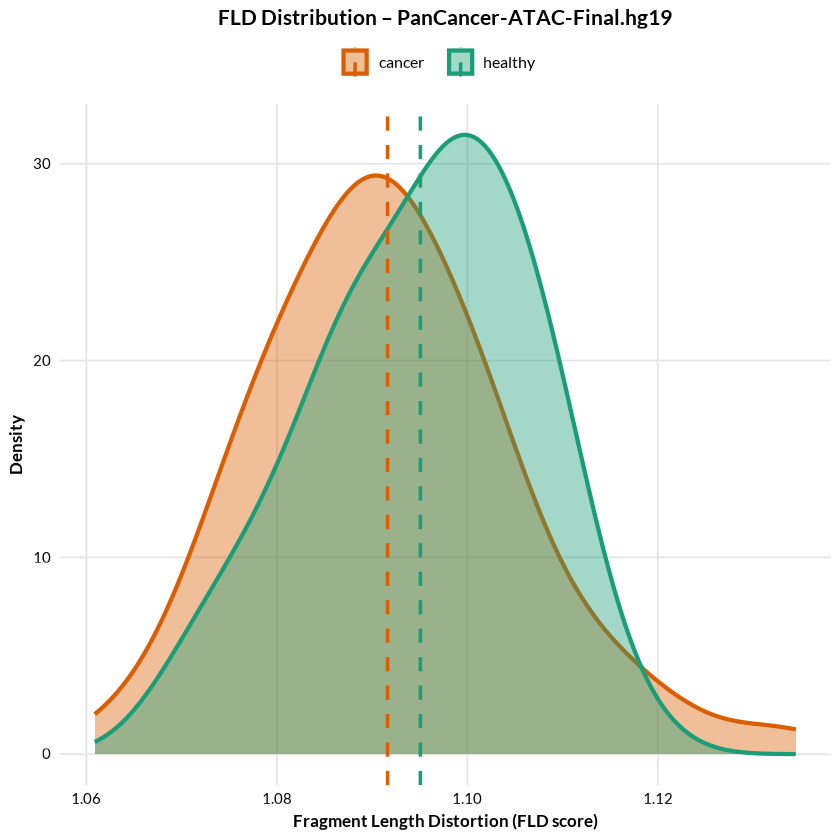

In [46]:
#!/usr/bin/env Rscript
# ===============================================================
# Density Plot of FLD score for PanCancer-ATAC-Final.hg19
# ===============================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(ggplot2)
  library(scales)
  library(showtext)
})

# ---------------------------------------------------------------
# 1. Identify column of interest
# ---------------------------------------------------------------
cre_col <- grep("cre_relcov_TCGA_filtered_final/PRAD-ATAC-Final.hg19_rel_cov_profile", 
                names(lucas_df_final), value = TRUE)
if (length(cre_col) == 0) stop("Feature not found in lucas_df_final.")

cat("Plotting:", cre_col, "\n")

# ---------------------------------------------------------------
# 2. Prepare data
# ---------------------------------------------------------------
plot_df <- lucas_df_final %>%
  dplyr::select(type, FLD = dplyr::all_of(cre_col)) %>%
  dplyr::filter(!is.na(FLD))

# ---------------------------------------------------------------
# 3. Nature-style theme
# ---------------------------------------------------------------
showtext_auto()
font_add_google("Lato", "lato")

theme_nature <- ggplot2::theme_minimal(base_family = "lato") +
  ggplot2::theme(
    plot.background = element_rect(fill = "white", color = NA),
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(color = "grey90"),
    axis.title = element_text(size = 13, face = "bold"),
    axis.text = element_text(size = 11, color = "black"),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    legend.position = "top",
    legend.title = element_blank(),
    legend.text = element_text(size = 12)
  )

# ---------------------------------------------------------------
# 4. Plot density
# ---------------------------------------------------------------
p <- ggplot2::ggplot(plot_df, ggplot2::aes(x = FLD, fill = type, color = type)) +
  ggplot2::geom_density(alpha = 0.4, linewidth = 1.2, adjust = 1.2) +
  ggplot2::scale_color_manual(values = c("healthy" = "#1B9E77", "cancer" = "#D95F02")) +
  ggplot2::scale_fill_manual(values  = c("healthy" = "#1B9E77", "cancer" = "#D95F02")) +
  ggplot2::labs(
    title = "FLD Distribution – PanCancer-ATAC-Final.hg19",
    x = "Fragment Length Distortion (FLD score)",
    y = "Density"
  ) +
  ggplot2::geom_vline(data = plot_df %>% 
                        dplyr::group_by(type) %>%
                        dplyr::summarise(mean_FLD = mean(FLD, na.rm = TRUE)),
                      ggplot2::aes(xintercept = mean_FLD, color = type),
                      linetype = "dashed", linewidth = 1) +
  theme_nature

# ---------------------------------------------------------------
# 5. Save figure
# ---------------------------------------------------------------
out_file <- "Density_FLD_PanCancer-ATAC-Final.png"
cat("📈 Saved:", out_file, "\n")

p


In [9]:
library(dplyr)
library(tidyr)

# Get all CRE wasserstein2d columns
cre_wass2d_cols <- grep("cre_fld_.*_wasserstein2d$", 
                        names(lucas_df_final), 
                        value = TRUE)

cat("Found", length(cre_wass2d_cols), "CRE wasserstein2d features\n\n")

# Calculate mean scores by cancer vs healthy
comparison_stats <- lucas_df_final %>%
  group_by(type) %>%
  summarise(
    n_samples = n(),
    across(all_of(cre_wass2d_cols), 
           ~mean(.x, na.rm = TRUE),
           .names = "{.col}")
  )

# Reshape for easier comparison
comparison_long <- comparison_stats %>%
  pivot_longer(cols = all_of(cre_wass2d_cols),
               names_to = "CRE_feature",
               values_to = "mean_wasserstein2d") %>%
  mutate(CRE_name = gsub("cre_fld_", "", CRE_feature),
         CRE_name = gsub("_wasserstein2d$", "", CRE_name))

# Create side-by-side comparison - RANKED BY RELATIVE DIFFERENCE
comparison_wide <- comparison_long %>%
  dplyr::select(CRE_name, type, mean_wasserstein2d) %>%
  pivot_wider(names_from = type, 
              values_from = mean_wasserstein2d) %>%
  mutate(
    difference = cancer - healthy,
    fold_change = cancer / (healthy + 1e-8),
    # Percent change relative to healthy baseline
    percent_change = ((cancer - healthy) / (healthy + 1e-8)) * 100,
    abs_percent_change = abs(percent_change)
  ) %>%
  arrange(desc(abs_percent_change))  # RANK BY RELATIVE DIFFERENCE

# Display results
cat("Sample sizes:\n")
print(comparison_stats %>% dplyr::select(type, n_samples))

cat("\n\nTop CREs by RELATIVE Wasserstein2D difference (cancer vs healthy):\n")
print(comparison_wide %>% 
        dplyr::select(CRE_name, healthy, cancer, difference, percent_change, fold_change) %>%
        head(20), 
      n = 20)

# Summary statistics
cat("\n\nSummary Statistics:\n")
cat("Mean percent change:", mean(comparison_wide$percent_change, na.rm = TRUE), "%\n")
cat("Median percent change:", median(comparison_wide$percent_change, na.rm = TRUE), "%\n")
cat("CREs with higher W2D in cancer:", sum(comparison_wide$difference > 0, na.rm = TRUE), "\n")
cat("CREs with higher W2D in healthy:", sum(comparison_wide$difference < 0, na.rm = TRUE), "\n")
cat("CREs with >50% increase in cancer:", sum(comparison_wide$percent_change > 50, na.rm = TRUE), "\n")
cat("CREs with >50% decrease in cancer:", sum(comparison_wide$percent_change < -50, na.rm = TRUE), "\n")

# Optional: Save the comparison
# write_csv(comparison_wide, "cre_wasserstein2d_cancer_vs_healthy_comparison.csv")

Found 0 CRE wasserstein2d features



ERROR: [1m[33mError[39m in `pivot_longer()`:[22m
[1m[22m[33m![39m `cols` must select at least one column.


In [68]:
comparison_wide

CRE_name,cancer,healthy,difference,fold_change,percent_change,abs_percent_change
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DHS_filtered_final/Primitive_embryonic_DHS_final_summit.hg19,0.5129003,0.4662980,0.04660229,1.0999410,9.994100,9.994100
CRE_overlaps_filtered_summit_final/Neural-Neuronal_Glial_overlap_ranges.hg19,0.9387304,0.8593234,0.07940699,1.0924064,9.240641,9.240641
TCGA_filtered_final/LUAD-ATAC-Final.hg19,0.5512622,0.5054954,0.04576681,1.0905385,9.053852,9.053852
ATAC_filtered_final/Skin_Mammary_Epithelial_ATAC_final_summit.hg19,0.4833010,0.4474638,0.03583726,1.0800897,8.008975,8.008975
ATAC_filtered_final/GI_Epithelial_ATAC_final_summit.hg19,0.5502492,0.5136970,0.03655220,1.0711552,7.115517,7.115517
CRE_overlaps_filtered_summit_final/Stromal_B-Neuroendocrine_overlap_ranges.hg19,0.8995274,0.8414877,0.05803970,1.0689727,6.897272,6.897272
TCGA_filtered_final/MESO-ATAC-Final.hg19,0.6404767,0.5992320,0.04124470,1.0688293,6.882927,6.882927
ATAC_filtered_final/Neuronal_Glial_ATAC_final_summit.hg19,0.7036171,0.6586945,0.04492256,1.0681994,6.819939,6.819939
ATAC_filtered_final/Follicular_ATAC_final_summit.hg19,0.6443111,0.6049559,0.03935521,1.0650547,6.505468,6.505468


### Rank

In [85]:
#!/usr/bin/env Rscript
# ===============================================================
# Rank-based CRE Comparison (Cancer vs Healthy) – Efficient Version
# ===============================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(matrixStats)  # for fast row-wise ranking
})

# ---------------------------------------------------------------
# 1. Identify all CRE features
# ---------------------------------------------------------------
cre_wass2d_cols <- grep("cre_fld_.*_wasserstein2d$", names(lucas_df_fld), value = TRUE)
cat("Found", length(cre_wass2d_cols), "CRE wasserstein2d features\n\n")

# ---------------------------------------------------------------
# 2. Extract and rank within each sample
# ---------------------------------------------------------------
# Prepare numeric matrix of CRE features
cre_mat <- as.matrix(lucas_df_fld[, cre_wass2d_cols])

# Compute ranks for each sample (row)
# Higher FLD → higher rank
rank_mat <- matrixStats::rowRanks(cre_mat, ties.method = "average")

# Assign column and row names
colnames(rank_mat) <- cre_wass2d_cols
rownames(rank_mat) <- lucas_df_fld$id

# Bind back to metadata
ranked_df <- cbind(
  lucas_df_final %>% dplyr::select(id, type),
  as.data.frame(rank_mat)
)

cat("✅ Computed within-sample ranks for all CRE features\n")

# ---------------------------------------------------------------
# 3. Compute mean rank by condition (cancer vs healthy)
# ---------------------------------------------------------------
comparison_stats <- ranked_df %>%
  dplyr::group_by(type) %>%
  dplyr::summarise(
    n_samples = dplyr::n(),
    dplyr::across(
      dplyr::all_of(cre_wass2d_cols),
      ~ mean(.x, na.rm = TRUE),
      .names = "{.col}"
    )
  )

# ---------------------------------------------------------------
# 4. Reshape for comparison
# ---------------------------------------------------------------
comparison_long <- comparison_stats %>%
  tidyr::pivot_longer(
    cols = dplyr::all_of(cre_wass2d_cols),
    names_to = "CRE_feature",
    values_to = "mean_rank"
  ) %>%
  dplyr::mutate(
    CRE_name = gsub("cre_fld_", "", CRE_feature),
    CRE_name = gsub("_wasserstein2d$", "", CRE_name)
  )

comparison_wide <- comparison_long %>%
  dplyr::select(CRE_name, type, mean_rank) %>%
  tidyr::pivot_wider(
    names_from = type,
    values_from = mean_rank
  ) %>%
  dplyr::mutate(
    difference = cancer - healthy,
    abs_diff = abs(difference)
  ) %>%
  dplyr::arrange(dplyr::desc(abs_diff))

# ---------------------------------------------------------------
# 5. Display top results
# ---------------------------------------------------------------
cat("Sample sizes:\n")
print(comparison_stats %>% dplyr::select(type, n_samples))

cat("\n\nTop CREs by absolute mean-rank difference (cancer vs healthy):\n")
print(
  comparison_wide %>%
    dplyr::select(CRE_name, healthy, cancer, difference) %>%
    head(20),
  n = 20
)

# ---------------------------------------------------------------
# 6. Summary statistics
# ---------------------------------------------------------------
cat("\n\nSummary Statistics:\n")
cat("Mean rank difference:", mean(comparison_wide$difference, na.rm = TRUE), "\n")
cat("Median rank difference:", median(comparison_wide$difference, na.rm = TRUE), "\n")
cat("CREs with higher rank in cancer:", sum(comparison_wide$difference > 0, na.rm = TRUE), "\n")
cat("CREs with higher rank in healthy:", sum(comparison_wide$difference < 0, na.rm = TRUE), "\n")

# ---------------------------------------------------------------
# 7. Optional: save output
# ---------------------------------------------------------------
# readr::write_csv(comparison_wide, "cre_rank_comparison_cancer_vs_healthy.csv")


Found 89 CRE wasserstein2d features

✅ Computed within-sample ranks for all CRE features
Sample sizes:
# A tibble: 2 × 2
  type    n_samples
  <chr>       <int>
1 cancer        129
2 healthy       158


Top CREs by absolute mean-rank difference (cancer vs healthy):
# A tibble: 20 × 4
   CRE_name                                            healthy cancer difference
   <chr>                                                 <dbl>  <dbl>      <dbl>
 1 DHS_filtered_final/Vascular_endothelial_DHS_final_…    38.2   31.4      -6.73
 2 DHS_filtered_final/Lymphoid_DHS_final_summit.hg19      58.5   51.9      -6.60
 3 TCGA_filtered_final/ACC-ATAC-Final.hg19                52.7   46.1      -6.59
 4 DHS_filtered_final/Pulmonary_devel_DHS_final_summi…    43.5   37.9      -5.65
 5 CRE_overlaps_filtered_summit_final/Stromal_B-Neuro…    65.3   70.9       5.59
 6 ATAC_filtered_final/Pulm_Epithelial_ATAC_final_sum…    47.5   52.7       5.20
 7 DHS_filtered_final/Myeloid_erythroid_DHS_final_sum…    70.3   65

In [86]:
comparison_wide

CRE_name,cancer,healthy,difference,abs_diff
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
DHS_filtered_final/Vascular_endothelial_DHS_final_summit.hg19,31.42478,38.15441,-6.729633,6.729633
DHS_filtered_final/Lymphoid_DHS_final_summit.hg19,51.92920,58.52941,-6.600208,6.600208
TCGA_filtered_final/ACC-ATAC-Final.hg19,46.14159,52.73529,-6.593701,6.593701
DHS_filtered_final/Pulmonary_devel_DHS_final_summit.hg19,37.87611,43.52206,-5.645953,5.645953
CRE_overlaps_filtered_summit_final/Stromal_B-Neuroendocrine_overlap_ranges.hg19,70.92920,65.33824,5.590968,5.590968
ATAC_filtered_final/Pulm_Epithelial_ATAC_final_summit.hg19,52.69027,47.48529,5.204971,5.204971
DHS_filtered_final/Myeloid_erythroid_DHS_final_summit.hg19,65.28319,70.31618,-5.032991,5.032991
ATAC_filtered_final/Pancreatic_Epithelial_ATAC_final_summit.hg19,21.93805,16.99265,4.945406,4.945406
ATAC_filtered_final/Follicular_ATAC_final_summit.hg19,44.03540,39.69853,4.336869,4.336869


In [49]:
#!/usr/bin/env Rscript
# ===============================================================
# Rank-based CRE Comparison (Cancer vs Healthy) – rel_cov_profile
# ===============================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(matrixStats)  # for fast row-wise ranking
})

# ---------------------------------------------------------------
# 1. Identify all CRE features
# ---------------------------------------------------------------
cre_relcov_cols <- grep("cre_relcov_.*_rel_cov_profile$", names(lucas_df_final), value = TRUE)
cat("Found", length(cre_relcov_cols), "CRE rel_cov_profile features\n\n")

# ---------------------------------------------------------------
# 2. Extract and rank within each sample
# ---------------------------------------------------------------
# Prepare numeric matrix of CRE features
cre_mat <- as.matrix(lucas_df_final[, cre_relcov_cols])

# Compute ranks for each sample (row)
# Higher relative coverage → higher rank
rank_mat <- matrixStats::rowRanks(cre_mat, ties.method = "average")

# Assign column and row names
colnames(rank_mat) <- cre_relcov_cols
rownames(rank_mat) <- lucas_df_final$id

# Bind back to metadata
ranked_df <- cbind(
  lucas_df_final %>% dplyr::select(id, type),
  as.data.frame(rank_mat)
)

cat("✅ Computed within-sample ranks for all rel_cov_profile features\n")

# ---------------------------------------------------------------
# 3. Compute mean rank by condition (cancer vs healthy)
# ---------------------------------------------------------------
comparison_stats <- ranked_df %>%
  dplyr::group_by(type) %>%
  dplyr::summarise(
    n_samples = dplyr::n(),
    dplyr::across(
      dplyr::all_of(cre_relcov_cols),
      ~ mean(.x, na.rm = TRUE),
      .names = "{.col}"
    )
  )

# ---------------------------------------------------------------
# 4. Reshape for comparison
# ---------------------------------------------------------------
comparison_long <- comparison_stats %>%
  tidyr::pivot_longer(
    cols = dplyr::all_of(cre_relcov_cols),
    names_to = "CRE_feature",
    values_to = "mean_rank"
  ) %>%
  dplyr::mutate(
    CRE_name = gsub("cre_relcov_", "", CRE_feature),
    CRE_name = gsub("_rel_cov_profile$", "", CRE_name)
  )

comparison_wide <- comparison_long %>%
  dplyr::select(CRE_name, type, mean_rank) %>%
  tidyr::pivot_wider(
    names_from = type,
    values_from = mean_rank
  ) %>%
  dplyr::mutate(
    difference = cancer - healthy,
    abs_diff = abs(difference)
  ) %>%
  dplyr::arrange(dplyr::desc(abs_diff))

# ---------------------------------------------------------------
# 5. Display top results
# ---------------------------------------------------------------
cat("Sample sizes:\n")
print(comparison_stats %>% dplyr::select(type, n_samples))

cat("\n\nTop CREs by absolute mean-rank difference (cancer vs healthy):\n")
print(
  comparison_wide %>%
    dplyr::select(CRE_name, healthy, cancer, difference) %>%
    head(20),
  n = 20
)

# ---------------------------------------------------------------
# 6. Summary statistics
# ---------------------------------------------------------------
cat("\n\nSummary Statistics:\n")
cat("Mean rank difference:", mean(comparison_wide$difference, na.rm = TRUE), "\n")
cat("Median rank difference:", median(comparison_wide$difference, na.rm = TRUE), "\n")
cat("CREs with higher mean rank in cancer:", sum(comparison_wide$difference > 0, na.rm = TRUE), "\n")
cat("CREs with higher mean rank in healthy:", sum(comparison_wide$difference < 0, na.rm = TRUE), "\n")

# ---------------------------------------------------------------
# 7. Optional: save output
# ---------------------------------------------------------------
# readr::write_csv(comparison_wide, "cre_relcov_rank_comparison_cancer_vs_healthy.csv")


Found 89 CRE rel_cov_profile features

✅ Computed within-sample ranks for all rel_cov_profile features
Sample sizes:
# A tibble: 2 × 2
  type    n_samples
  <chr>       <int>
1 cancer        129
2 healthy       158


Top CREs by absolute mean-rank difference (cancer vs healthy):
# A tibble: 20 × 4
   CRE_name                                            healthy cancer difference
   <chr>                                                 <dbl>  <dbl>      <dbl>
 1 DHS_filtered_final/Myeloid_erythroid_DHS_final_sum…    30.7   39.3       8.64
 2 ATAC_filtered_final/Neuroendocrine_ATAC_final_summ…    57.5   51.0      -6.48
 3 CRE_overlaps_filtered_summit_final/Cancer_epitheli…    75.7   69.4      -6.28
 4 CRE_overlaps_filtered_summit_final/Vascular_endoth…    72.7   66.5      -6.18
 5 DHS_filtered_final/Lymphoid_DHS_final_summit.hg19      32.3   38.4       6.11
 6 ATAC_filtered_final/Skin_Mammary_Epithelial_ATAC_f…    71.6   65.6      -5.92
 7 ATAC_filtered_final/Pulm_Epithelial_ATAC_final_sum

## LUCAS Lung Cancer Results: Wilxocon

In [15]:
#!/usr/bin/env Rscript
# ===============================================================
# Wilcoxon comparison (Cancer vs Healthy) – rel_cov_profile
# ===============================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
})

# ---------------------------------------------------------------
# 1. Identify rel_cov_profile features
# ---------------------------------------------------------------
cre_relcov_cols <- grep("cre_relcov_.*_rel_cov_profile$", names(lucas_df_final), value = TRUE)
cat("Found", length(cre_relcov_cols), "CRE rel_cov_profile features\n\n")

# ---------------------------------------------------------------
# 2. Prepare dataframe
# ---------------------------------------------------------------
df_long <- lucas_df_final %>%
  dplyr::select(id, type, dplyr::all_of(cre_relcov_cols)) %>%
  tidyr::pivot_longer(
    cols = dplyr::all_of(cre_relcov_cols),
    names_to = "CRE_feature",
    values_to = "rel_cov"
  ) %>%
  dplyr::mutate(
    CRE_name = gsub("cre_relcov_", "", CRE_feature),
    CRE_name = gsub("_rel_cov_profile$", "", CRE_name)
  )

# ---------------------------------------------------------------
# 3. Perform Wilcoxon test per CRE
# ---------------------------------------------------------------
wilcox_results <- df_long %>%
  dplyr::group_by(CRE_name) %>%
  dplyr::summarise(
    n_cancer  = sum(type == "cancer"),
    n_healthy = sum(type == "healthy"),
    mean_cancer  = mean(rel_cov[type == "cancer"], na.rm = TRUE),
    mean_healthy = mean(rel_cov[type == "healthy"], na.rm = TRUE),
    diff = mean_cancer - mean_healthy,
    p_value = tryCatch(
      wilcox.test(rel_cov ~ type, exact = FALSE)$p.value,
      error = function(e) NA_real_
    ),
    .groups = "drop"
  ) %>%
  dplyr::mutate(
    p_adj = p.adjust(p_value, method = "BH"),
    sig = p_adj < 0.05
  ) %>%
  dplyr::arrange(p_adj)

cat("Significant CREs (BH FDR < 0.05):", sum(wilcox_results$sig, na.rm = TRUE), "\n")
print(head(wilcox_results, 20))


Found 89 CRE rel_cov_profile features

Significant CREs (BH FDR < 0.05): 71 
# A tibble: 20 × 9
   CRE_name n_cancer n_healthy mean_cancer mean_healthy     diff p_value   p_adj
   <chr>       <int>     <int>       <dbl>        <dbl>    <dbl>   <dbl>   <dbl>
 1 ATAC_fi…      129       158       1.07         1.09  -0.0170  1.01e-7 9.00e-6
 2 ATAC_fi…      129       158       1.06         1.08  -0.0165  6.07e-7 2.47e-5
 3 DHS_fil…      129       158       1.12         1.14  -0.0109  1.11e-6 2.47e-5
 4 TCGA_fi…      129       158       1.08         1.09  -0.0152  8.33e-7 2.47e-5
 5 ATAC_fi…      129       158       1.09         1.10  -0.0148  2.18e-6 3.71e-5
 6 DHS_fil…      129       158       1.12         1.13  -0.0104  2.50e-6 3.71e-5
 7 ATAC_fi…      129       158       1.10         1.11  -0.00839 3.94e-6 5.00e-5
 8 ATAC_fi…      129       158       1.09         1.11  -0.0169  8.75e-6 7.78e-5
 9 CRE_ove…      129       158       1.02         1.04  -0.0214  7.06e-6 7.78e-5
10 TCGA_fi…  

In [19]:
# ---------------------------------------------------------------
# 4. Filter for TCGA results
# ---------------------------------------------------------------
wilcox_results_tcga <- wilcox_results %>%
  dplyr::filter(grepl("TCGA", CRE_name, ignore.case = TRUE))

cat("\nFiltered to TCGA CREs only:\n")
cat("Total TCGA CREs:", nrow(wilcox_results_tcga), "\n")
cat("Significant TCGA CREs (BH FDR < 0.05):", sum(wilcox_results_tcga$sig, na.rm = TRUE), "\n\n")
print(wilcox_results_tcga)

wilcox_results_atac <- wilcox_results %>%
  dplyr::filter(grepl("ATAC_filtered", CRE_name, ignore.case = TRUE))

cat("\nFiltered to TCGA CREs only:\n")
cat("Total TCGA CREs:", nrow(wilcox_results_tcga), "\n")
cat("Significant TCGA CREs (BH FDR < 0.05):", sum(wilcox_results_tcga$sig, na.rm = TRUE), "\n\n")
print(wilcox_results_tcga)


Filtered to TCGA CREs only:
Total TCGA CREs: 38 
Significant TCGA CREs (BH FDR < 0.05): 32 

# A tibble: 38 × 9
   CRE_name n_cancer n_healthy mean_cancer mean_healthy     diff p_value   p_adj
   <chr>       <int>     <int>       <dbl>        <dbl>    <dbl>   <dbl>   <dbl>
 1 TCGA_fi…      129       158       1.08         1.09  -0.0152  8.33e-7 2.47e-5
 2 TCGA_fi…      129       158       1.07         1.08  -0.0100  8.40e-6 7.78e-5
 3 TCGA_fi…      129       158       1.04         1.05  -0.00747 2.50e-4 9.27e-4
 4 TCGA_fi…      129       158       1.06         1.07  -0.00695 2.48e-4 9.27e-4
 5 TCGA_fi…      129       158       1.08         1.09  -0.00975 2.71e-4 9.66e-4
 6 TCGA_fi…      129       158       0.940        0.954 -0.0137  3.05e-4 9.68e-4
 7 TCGA_fi…      129       158       1.07         1.08  -0.0137  3.05e-4 9.68e-4
 8 TCGA_fi…      129       158       1.08         1.09  -0.00962 3.86e-4 1.11e-3
 9 TCGA_fi…      129       158       0.940        0.953 -0.0135  4.37e-4 1.18

In [18]:
wilcox_results_tcga

CRE_name,n_cancer,n_healthy,mean_cancer,mean_healthy,diff,p_value,p_adj,sig
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
TCGA_filtered_final/LUAD-ATAC-Final.hg19,129,158,1.0780277,1.0932083,-0.015180602,8.326119e-07,2.466411e-05,TRUE
TCGA_filtered_final/Lung-ATAC-Final.hg19,129,158,1.0741304,1.0841382,-0.010007783,8.395534e-06,7.784099e-05,TRUE
TCGA_filtered_final/ESCA-ATAC-Final.hg19,129,158,1.0444766,1.0519485,-0.007471962,2.499769e-04,9.269977e-04,TRUE
TCGA_filtered_final/UCEC-ATAC-Final.hg19,129,158,1.0608146,1.0677622,-0.006947563,2.482671e-04,9.269977e-04,TRUE
TCGA_filtered_final/BRCA-ATAC-Final.hg19,129,158,1.0755930,1.0853477,-0.009754679,2.713749e-04,9.660945e-04,TRUE
TCGA_filtered_final/TGCT-ATAC-Final.hg19,129,158,0.9404590,0.9542037,-0.013744676,3.046414e-04,9.683245e-04,TRUE
TCGA_filtered_final/THCA-ATAC-Final.hg19,129,158,1.0684351,1.0821566,-0.013721448,3.046414e-04,9.683245e-04,TRUE
TCGA_filtered_final/Breast-ATAC-Final.hg19,129,158,1.0764371,1.0860615,-0.009624395,3.855031e-04,1.106767e-03,TRUE
TCGA_filtered_final/Germ-ATAC-Final.hg19,129,158,0.9399736,0.9534731,-0.013499511,4.374004e-04,1.179656e-03,TRUE


In [20]:
wilcox_results_atac

CRE_name,n_cancer,n_healthy,mean_cancer,mean_healthy,diff,p_value,p_adj,sig
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
ATAC_filtered_final/Neuroendocrine_ATAC_final_summit.hg19,129,158,1.0745877,1.0915855,-0.016997805,1.011079e-07,8.998604e-06,TRUE
ATAC_filtered_final/GI_Epithelial_ATAC_final_summit.hg19,129,158,1.0596280,1.0761315,-0.016503468,6.067047e-07,2.466411e-05,TRUE
ATAC_filtered_final/Pulm_Epithelial_ATAC_final_summit.hg19,129,158,1.0854575,1.1002497,-0.014792203,2.179620e-06,3.712565e-05,TRUE
ATAC_filtered_final/Gastric_Epithelial_ATAC_final_summit.hg19,129,158,1.1048791,1.1132695,-0.008390351,3.935527e-06,5.003741e-05,TRUE
ATAC_filtered_final/Skin_Mammary_Epithelial_ATAC_final_summit.hg19,129,158,1.0931691,1.1101141,-0.016945038,8.746178e-06,7.784099e-05,TRUE
ATAC_filtered_final/Placental_ATAC_final_summit.hg19,129,158,0.9901795,1.0042125,-0.014032943,2.774327e-05,2.057626e-04,TRUE
ATAC_filtered_final/Adrenal_Cortical_ATAC_final_summit.hg19,129,158,1.0807372,1.0920059,-0.011268758,5.546360e-05,3.797123e-04,TRUE
ATAC_filtered_final/Pancreatic_Epithelial_ATAC_final_summit.hg19,129,158,1.0305211,1.0404254,-0.009904304,6.111124e-05,3.884929e-04,TRUE
ATAC_filtered_final/Follicular_ATAC_final_summit.hg19,129,158,1.0643027,1.0756082,-0.011305488,8.392262e-05,4.979409e-04,TRUE


In [21]:
#!/usr/bin/env Rscript
# ===============================================================
# Wilcoxon comparison (Cancer vs Healthy) – rel_cov_profile
# ===============================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
})

# ---------------------------------------------------------------
# 1. Identify rel_cov_profile features
# ---------------------------------------------------------------
cre_relcov_cols <- grep("cre_fld_.*_wasserstein2d$", names(lucas_df_fld), value = TRUE)
cat("Found", length(cre_relcov_cols), "CRE rel_cov_profile features\n\n")

# ---------------------------------------------------------------
# 2. Prepare dataframe
# ---------------------------------------------------------------
df_long <- lucas_df_fld %>%
  dplyr::select(id, type, dplyr::all_of(cre_relcov_cols)) %>%
  tidyr::pivot_longer(
    cols = dplyr::all_of(cre_relcov_cols),
    names_to = "CRE_feature",
    values_to = "rel_cov"
  ) %>%
  dplyr::mutate(
    CRE_name = gsub("cre_relcov_", "", CRE_feature),
    CRE_name = gsub("_rel_cov_profile$", "", CRE_name)
  )

# ---------------------------------------------------------------
# 3. Perform Wilcoxon test per CRE
# ---------------------------------------------------------------
wilcox_results <- df_long %>%
  dplyr::group_by(CRE_name) %>%
  dplyr::summarise(
    n_cancer  = sum(type == "cancer"),
    n_healthy = sum(type == "healthy"),
    mean_cancer  = mean(rel_cov[type == "cancer"], na.rm = TRUE),
    mean_healthy = mean(rel_cov[type == "healthy"], na.rm = TRUE),
    diff = mean_cancer - mean_healthy,
    p_value = tryCatch(
      wilcox.test(rel_cov ~ type, exact = FALSE)$p.value,
      error = function(e) NA_real_
    ),
    .groups = "drop"
  ) %>%
  dplyr::mutate(
    p_adj = p.adjust(p_value, method = "BH"),
    sig = p_adj < 0.05
  ) %>%
  dplyr::arrange(p_adj)

cat("Significant CREs (BH FDR < 0.05):", sum(wilcox_results$sig, na.rm = TRUE), "\n")
print(head(wilcox_results, 20))


Found 89 CRE rel_cov_profile features

Significant CREs (BH FDR < 0.05): 2 
# A tibble: 20 × 9
   CRE_name   n_cancer n_healthy mean_cancer mean_healthy    diff p_value  p_adj
   <chr>         <int>     <int>       <dbl>        <dbl>   <dbl>   <dbl>  <dbl>
 1 cre_fld_A…      129       158       0.690        0.645  0.0452 9.84e-4 0.0438
 2 cre_fld_A…      129       158       0.485        0.446  0.0389 9.19e-4 0.0438
 3 cre_fld_A…      129       158       0.506        0.468  0.0386 2.64e-3 0.0710
 4 cre_fld_C…      129       158       0.907        0.832  0.0745 3.19e-3 0.0710
 5 cre_fld_A…      129       158       0.643        0.605  0.0381 1.16e-2 0.147 
 6 cre_fld_A…      129       158       0.556        0.519  0.0375 1.14e-2 0.147 
 7 cre_fld_A…      129       158       0.703        0.665  0.0379 1.10e-2 0.147 
 8 cre_fld_T…      129       158       0.548        0.511  0.0376 1.54e-2 0.171 
 9 cre_fld_C…      129       158       0.941        0.868  0.0729 1.94e-2 0.192 
10 cre_fld_D… 

In [22]:
wilcox_results

CRE_name,n_cancer,n_healthy,mean_cancer,mean_healthy,diff,p_value,p_adj,sig
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
cre_fld_ATAC_filtered_final/Pulm_Epithelial_ATAC_final_summit.hg19_wasserstein2d,129,158,0.6897096,0.6445513,0.04515828,0.0009842139,0.04379752,TRUE
cre_fld_ATAC_filtered_final/Skin_Mammary_Epithelial_ATAC_final_summit.hg19_wasserstein2d,129,158,0.4849738,0.4460385,0.03893530,0.0009186253,0.04379752,TRUE
cre_fld_ATAC_filtered_final/Pancreatic_Epithelial_ATAC_final_summit.hg19_wasserstein2d,129,158,0.5062306,0.4675922,0.03863842,0.0026401505,0.07097841,FALSE
cre_fld_CRE_overlaps_filtered_summit_final/Stromal_B-Neuroendocrine_overlap_ranges.hg19_wasserstein2d,129,158,0.9069781,0.8324354,0.07454267,0.0031900407,0.07097841,FALSE
cre_fld_ATAC_filtered_final/Follicular_ATAC_final_summit.hg19_wasserstein2d,129,158,0.6426890,0.6045905,0.03809851,0.0115603297,0.14698133,FALSE
cre_fld_ATAC_filtered_final/GI_Epithelial_ATAC_final_summit.hg19_wasserstein2d,129,158,0.5560666,0.5185882,0.03747838,0.0114452148,0.14698133,FALSE
cre_fld_ATAC_filtered_final/Neuronal_Glial_ATAC_final_summit.hg19_wasserstein2d,129,158,0.7026622,0.6647797,0.03788252,0.0109948651,0.14698133,FALSE
cre_fld_TCGA_filtered_final/LUAD-ATAC-Final.hg19_wasserstein2d,129,158,0.5482262,0.5106462,0.03757993,0.0153775403,0.17107514,FALSE
cre_fld_CRE_overlaps_filtered_summit_final/Neural-Neuronal_Glial_overlap_ranges.hg19_wasserstein2d,129,158,0.9406142,0.8677066,0.07290757,0.0194259847,0.19210140,FALSE


In [23]:
# ---------------------------------------------------------------
# 4. Filter for TCGA results
# ---------------------------------------------------------------
wilcox_results_tcga <- wilcox_results %>%
  dplyr::filter(grepl("TCGA", CRE_name, ignore.case = TRUE))

cat("\nFiltered to TCGA CREs only:\n")
cat("Total TCGA CREs:", nrow(wilcox_results_tcga), "\n")
cat("Significant TCGA CREs (BH FDR < 0.05):", sum(wilcox_results_tcga$sig, na.rm = TRUE), "\n\n")
print(wilcox_results_tcga)

wilcox_results_atac <- wilcox_results %>%
  dplyr::filter(grepl("ATAC_filtered", CRE_name, ignore.case = TRUE))

cat("\nFiltered to TCGA CREs only:\n")
cat("Total TCGA CREs:", nrow(wilcox_results_tcga), "\n")
cat("Significant TCGA CREs (BH FDR < 0.05):", sum(wilcox_results_tcga$sig, na.rm = TRUE), "\n\n")
print(wilcox_results_tcga)


Filtered to TCGA CREs only:
Total TCGA CREs: 38 
Significant TCGA CREs (BH FDR < 0.05): 0 

# A tibble: 38 × 9
   CRE_name    n_cancer n_healthy mean_cancer mean_healthy    diff p_value p_adj
   <chr>          <int>     <int>       <dbl>        <dbl>   <dbl>   <dbl> <dbl>
 1 cre_fld_TC…      129       158       0.548        0.511  0.0376  0.0154 0.171
 2 cre_fld_TC…      129       158       0.633        0.597  0.0362  0.0315 0.268
 3 cre_fld_TC…      129       158       0.468        0.443  0.0249  0.0371 0.275
 4 cre_fld_TC…      129       158       0.494        0.469  0.0245  0.0507 0.322
 5 cre_fld_TC…      129       158       0.676        0.645  0.0309  0.0810 0.400
 6 cre_fld_TC…      129       158       0.496        0.475  0.0214  0.116  0.410
 7 cre_fld_TC…      129       158       0.497        0.475  0.0221  0.102  0.410
 8 cre_fld_TC…      129       158       0.635        0.605  0.0303  0.120  0.410
 9 cre_fld_TC…      129       158       0.657        0.678 -0.0208  0.141  0.4

In [24]:
wilcox_results_atac

CRE_name,n_cancer,n_healthy,mean_cancer,mean_healthy,diff,p_value,p_adj,sig
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
cre_fld_ATAC_filtered_final/Pulm_Epithelial_ATAC_final_summit.hg19_wasserstein2d,129,158,0.6897096,0.6445513,0.045158281,0.0009842139,0.04379752,TRUE
cre_fld_ATAC_filtered_final/Skin_Mammary_Epithelial_ATAC_final_summit.hg19_wasserstein2d,129,158,0.4849738,0.4460385,0.038935304,0.0009186253,0.04379752,TRUE
cre_fld_ATAC_filtered_final/Pancreatic_Epithelial_ATAC_final_summit.hg19_wasserstein2d,129,158,0.5062306,0.4675922,0.038638416,0.0026401505,0.07097841,FALSE
cre_fld_ATAC_filtered_final/Follicular_ATAC_final_summit.hg19_wasserstein2d,129,158,0.6426890,0.6045905,0.038098510,0.0115603297,0.14698133,FALSE
cre_fld_ATAC_filtered_final/GI_Epithelial_ATAC_final_summit.hg19_wasserstein2d,129,158,0.5560666,0.5185882,0.037478381,0.0114452148,0.14698133,FALSE
cre_fld_ATAC_filtered_final/Neuronal_Glial_ATAC_final_summit.hg19_wasserstein2d,129,158,0.7026622,0.6647797,0.037882519,0.0109948651,0.14698133,FALSE
cre_fld_ATAC_filtered_final/Neuroendocrine_ATAC_final_summit.hg19_wasserstein2d,129,158,0.7004781,0.6716822,0.028795951,0.0744734365,0.38989034,FALSE
cre_fld_ATAC_filtered_final/Stromal_ATAC_final_summit.hg19_wasserstein2d,129,158,0.6840035,0.6656742,0.018329288,0.0724952928,0.38989034,FALSE
cre_fld_ATAC_filtered_final/Ubiquitous_ATAC_final_summit.hg19_wasserstein2d,129,158,2.5223424,2.4284444,0.093898049,0.0856740339,0.40131521,FALSE


In [25]:
wilcox_results_tcga

CRE_name,n_cancer,n_healthy,mean_cancer,mean_healthy,diff,p_value,p_adj,sig
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
cre_fld_TCGA_filtered_final/LUAD-ATAC-Final.hg19_wasserstein2d,129,158,0.5482262,0.5106462,0.037579930,0.01537754,0.1710751,FALSE
cre_fld_TCGA_filtered_final/THCA-ATAC-Final.hg19_wasserstein2d,129,158,0.6329041,0.5967476,0.036156452,0.03147805,0.2684630,FALSE
cre_fld_TCGA_filtered_final/STAD-ATAC-Final.hg19_wasserstein2d,129,158,0.4677070,0.4428365,0.024870537,0.03714217,0.2754711,FALSE
cre_fld_TCGA_filtered_final/COAD-ATAC-Final.hg19_wasserstein2d,129,158,0.4938738,0.4693574,0.024516386,0.05068287,0.3221982,FALSE
cre_fld_TCGA_filtered_final/LGG-ATAC-Final.hg19_wasserstein2d,129,158,0.6760400,0.6451328,0.030907179,0.08097922,0.4003973,FALSE
cre_fld_TCGA_filtered_final/BRCA-ATAC-Final.hg19_wasserstein2d,129,158,0.4964222,0.4750352,0.021386973,0.11616955,0.4103887,FALSE
cre_fld_TCGA_filtered_final/Breast-ATAC-Final.hg19_wasserstein2d,129,158,0.4970648,0.4749160,0.022148804,0.10182332,0.4103887,FALSE
cre_fld_TCGA_filtered_final/MESO-ATAC-Final.hg19_wasserstein2d,129,158,0.6348654,0.6045911,0.030274309,0.11988883,0.4103887,FALSE
cre_fld_TCGA_filtered_final/ACC-ATAC-Final.hg19_wasserstein2d,129,158,0.6572475,0.6780188,-0.020771300,0.14132131,0.4249230,FALSE


### More Stats

In [80]:
#!/usr/bin/env Rscript
# ===============================================================
# t-test, Wilcoxon, and KS-test for rel_cov_profile (Cancer vs Healthy)
# ===============================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
})

# ---------------------------------------------------------------
# 1. Identify all rel_cov_profile features
# ---------------------------------------------------------------
cre_relcov_cols <- grep("cre_relcov_.*rel_cov_profile$", names(lucas_df_final), value = TRUE)
cat("Found", length(cre_relcov_cols), "CRE rel_cov_profile features\n\n")

if (length(cre_relcov_cols) == 0) stop("No rel_cov_profile features found.")

# ---------------------------------------------------------------
# 2. Reshape to long format
# ---------------------------------------------------------------
df_long <- lucas_df_final %>%
  dplyr::select(id, type, dplyr::all_of(cre_relcov_cols)) %>%
  tidyr::pivot_longer(
    cols = dplyr::all_of(cre_relcov_cols),
    names_to = "CRE_feature",
    values_to = "rel_cov"
  ) %>%
  dplyr::mutate(
    CRE_name = gsub("cre_relcov_", "", CRE_feature),
    CRE_name = gsub("_rel_cov_profile$", "", CRE_name)
  ) %>%
  dplyr::filter(!is.na(rel_cov))

# ---------------------------------------------------------------
# 3. Run three tests per CRE
# ---------------------------------------------------------------
stats_table <- df_long %>%
  dplyr::group_by(CRE_name) %>%
  dplyr::summarise(
    n_cancer  = sum(type == "cancer"),
    n_healthy = sum(type == "healthy"),
    mean_cancer  = mean(rel_cov[type == "cancer"],  na.rm = TRUE),
    mean_healthy = mean(rel_cov[type == "healthy"], na.rm = TRUE),
    mean_diff = mean_cancer - mean_healthy,

    # --- t-test (parametric) ---
    t_p = tryCatch(t.test(rel_cov ~ type)$p.value, error = function(e) NA_real_),

    # --- Wilcoxon rank-sum (nonparametric) ---
    wilcox_p = tryCatch(wilcox.test(rel_cov ~ type, exact = FALSE)$p.value, error = function(e) NA_real_),

    # --- Kolmogorov–Smirnov (distributional) ---
    ks_p = tryCatch(ks.test(rel_cov[type == "cancer"], rel_cov[type == "healthy"])$p.value, error = function(e) NA_real_),

    .groups = "drop"
  ) %>%
  dplyr::mutate(
    # FDR correction for each test
    t_FDR = p.adjust(t_p, method = "BH"),
    wilcox_FDR = p.adjust(wilcox_p, method = "BH"),
    ks_FDR = p.adjust(ks_p, method = "BH")
  ) %>%
  dplyr::arrange(wilcox_FDR)

# ---------------------------------------------------------------
# 4. Display combined table
# ---------------------------------------------------------------
cat("✅ Completed t-test, Wilcoxon, and KS-test comparisons\n\n")
print(
  stats_table %>%
    dplyr::select(
      CRE_name, mean_cancer, mean_healthy, mean_diff,
      t_p, t_FDR, wilcox_p, wilcox_FDR, ks_p, ks_FDR
    ) %>%
    head(20),
  n = 20
)

# ---------------------------------------------------------------
# 5. Optional: Save results
# ---------------------------------------------------------------
# readr::write_csv(stats_table, "relcovprofile_three_tests_results.csv")


Found 89 CRE rel_cov_profile features

✅ Completed t-test, Wilcoxon, and KS-test comparisons

# A tibble: 20 × 10
   CRE_name          mean_cancer mean_healthy mean_diff     t_p   t_FDR wilcox_p
   <chr>                   <dbl>        <dbl>     <dbl>   <dbl>   <dbl>    <dbl>
 1 ATAC_filtered_fi…       1.07          1.09  -0.0170  3.55e-8 3.16e-6  1.12e-7
 2 ATAC_filtered_fi…       1.06          1.08  -0.0165  1.07e-7 4.78e-6  7.12e-7
 3 TCGA_filtered_fi…       1.08          1.09  -0.0153  3.68e-7 1.09e-5  7.58e-7
 4 DHS_filtered_fin…       1.12          1.14  -0.0109  2.01e-6 3.58e-5  1.11e-6
 5 ATAC_filtered_fi…       1.09          1.10  -0.0148  1.28e-6 2.85e-5  2.20e-6
 6 DHS_filtered_fin…       1.12          1.13  -0.0104  1.11e-5 1.24e-4  3.09e-6
 7 ATAC_filtered_fi…       1.10          1.11  -0.00832 1.28e-5 1.27e-4  4.93e-6
 8 CRE_overlaps_fil…       1.02          1.04  -0.0215  1.01e-5 1.24e-4  6.78e-6
 9 ATAC_filtered_fi…       1.09          1.11  -0.0170  6.56e-6 9.73e-5  8.8

In [81]:
stats_table

CRE_name,n_cancer,n_healthy,mean_cancer,mean_healthy,mean_diff,t_p,wilcox_p,ks_p,t_FDR,wilcox_FDR,ks_FDR
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ATAC_filtered_final/Neuroendocrine_ATAC_final_summit.hg19,113,136,1.0745877,1.0915898,-0.017002082,3.548128e-08,1.118491e-07,1.490063e-05,3.157834e-06,9.954571e-06,3.315389e-04
ATAC_filtered_final/GI_Epithelial_ATAC_final_summit.hg19,113,136,1.0596280,1.0760933,-0.016465237,1.073857e-07,7.115693e-07,3.191525e-04,4.778662e-06,2.249584e-05,2.028898e-03
TCGA_filtered_final/LUAD-ATAC-Final.hg19,113,136,1.0780277,1.0932976,-0.015269896,3.683667e-07,7.582867e-07,3.548846e-05,1.092821e-05,2.249584e-05,5.264122e-04
DHS_filtered_final/Stromal_A_DHS_final_summit.hg19,113,136,1.1244879,1.1354113,-0.010923381,2.013529e-06,1.107087e-06,4.411065e-06,3.584081e-05,2.463268e-05,1.308616e-04
ATAC_filtered_final/Pulm_Epithelial_ATAC_final_summit.hg19,113,136,1.0854575,1.1002800,-0.014822516,1.280557e-06,2.204296e-06,1.075315e-04,2.849240e-05,3.923647e-05,9.570300e-04
DHS_filtered_final/Cancer_epithelial_DHS_final_summit.hg19,113,136,1.1208482,1.1312009,-0.010352677,1.112625e-05,3.089080e-06,1.858312e-06,1.237795e-04,4.582135e-05,9.258128e-05
ATAC_filtered_final/Gastric_Epithelial_ATAC_final_summit.hg19,113,136,1.1048791,1.1132011,-0.008322013,1.282013e-05,4.933301e-06,4.877772e-05,1.267769e-04,6.272339e-05,6.201739e-04
CRE_overlaps_filtered_summit_final/Placental_trophoblast-Placental_overlap_ranges.hg19,113,136,1.0199063,1.0414141,-0.021507831,1.012799e-05,6.781080e-06,5.606936e-04,1.237795e-04,7.543952e-05,2.535228e-03
ATAC_filtered_final/Skin_Mammary_Epithelial_ATAC_final_summit.hg19,113,136,1.0931691,1.1101321,-0.016963043,6.556455e-06,8.834560e-06,5.867500e-04,9.725408e-05,7.862758e-05,2.535228e-03


In [82]:
#!/usr/bin/env Rscript
# ===============================================================
# t-test, Wilcoxon, and KS-test for FLD features (Cancer vs Healthy)
# ===============================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
})

# ---------------------------------------------------------------
# 1. Identify all FLD features
# ---------------------------------------------------------------
cre_fld_cols <- grep("cre_fld_.*_FLD_entropy$", names(lucas_df_fld), value = TRUE)
cat("Found", length(cre_fld_cols), "CRE FLD features\n\n")

if (length(cre_fld_cols) == 0) stop("No FLD feature columns found. Check naming pattern.")

# ---------------------------------------------------------------
# 2. Reshape to long format
# ---------------------------------------------------------------
df_long <- lucas_df_fld %>%
  dplyr::select(id, type, dplyr::all_of(cre_fld_cols)) %>%
  tidyr::pivot_longer(
    cols = dplyr::all_of(cre_fld_cols),
    names_to = "CRE_feature",
    values_to = "FLD_value"
  ) %>%
  dplyr::mutate(
    CRE_name = gsub("cre_fld_", "", CRE_feature),
    CRE_name = gsub("_FLD_entropy$", "", CRE_name)
  ) %>%
  dplyr::filter(!is.na(FLD_value))

# ---------------------------------------------------------------
# 3. Run t-test, Wilcoxon, and KS-test per CRE
# ---------------------------------------------------------------
stats_table <- df_long %>%
  dplyr::group_by(CRE_name) %>%
  dplyr::summarise(
    n_cancer  = sum(type == "cancer"),
    n_healthy = sum(type == "healthy"),
    mean_cancer  = mean(FLD_value[type == "cancer"],  na.rm = TRUE),
    mean_healthy = mean(FLD_value[type == "healthy"], na.rm = TRUE),
    mean_diff = mean_cancer - mean_healthy,

    # --- t-test (parametric mean comparison) ---
    t_p = tryCatch(t.test(FLD_value ~ type)$p.value, error = function(e) NA_real_),

    # --- Wilcoxon rank-sum (nonparametric) ---
    wilcox_p = tryCatch(wilcox.test(FLD_value ~ type, exact = FALSE)$p.value, error = function(e) NA_real_),

    # --- Kolmogorov–Smirnov (distributional) ---
    ks_p = tryCatch(ks.test(FLD_value[type == "cancer"],
                            FLD_value[type == "healthy"])$p.value,
                    error = function(e) NA_real_),

    .groups = "drop"
  ) %>%
  dplyr::mutate(
    # FDR correction for each test
    t_FDR = p.adjust(t_p, method = "BH"),
    wilcox_FDR = p.adjust(wilcox_p, method = "BH"),
    ks_FDR = p.adjust(ks_p, method = "BH")
  ) %>%
  dplyr::arrange(wilcox_FDR)

# ---------------------------------------------------------------
# 4. Display results
# ---------------------------------------------------------------
cat("✅ Completed all three tests for FLD features\n\n")

print(
  stats_table %>%
    dplyr::select(
      CRE_name, mean_cancer, mean_healthy, mean_diff,
      t_p, t_FDR, wilcox_p, wilcox_FDR, ks_p, ks_FDR
    ) %>%
    head(20),
  n = 20
)

# ---------------------------------------------------------------
# 5. Summary statistics
# ---------------------------------------------------------------
cat("\n\nSummary Statistics:\n")
cat("Significant (FDR < 0.05, Wilcoxon):", sum(stats_table$wilcox_FDR < 0.05, na.rm = TRUE), "\n")
cat("Significant (FDR < 0.05, t-test):", sum(stats_table$t_FDR < 0.05, na.rm = TRUE), "\n")
cat("Significant (FDR < 0.05, KS-test):", sum(stats_table$ks_FDR < 0.05, na.rm = TRUE), "\n")
cat("Top absolute mean differences:\n")
print(stats_table %>% dplyr::arrange(dplyr::desc(abs(mean_diff))) %>% head(10))

# ---------------------------------------------------------------
# 6. Optional: save results
# ---------------------------------------------------------------
# readr::write_csv(stats_table, "fld_three_tests_results.csv")


Found 89 CRE FLD features

✅ Completed all three tests for FLD features

# A tibble: 20 × 10
   CRE_name   mean_cancer mean_healthy mean_diff   t_p t_FDR wilcox_p wilcox_FDR
   <chr>            <dbl>        <dbl>     <dbl> <dbl> <dbl>    <dbl>      <dbl>
 1 ATAC_filt…        6.15         6.14    0.0169 0.158 0.236    0.556      0.680
 2 ATAC_filt…        6.15         6.14    0.0162 0.178 0.236    0.547      0.680
 3 ATAC_filt…        6.16         6.14    0.0178 0.142 0.236    0.497      0.680
 4 ATAC_filt…        6.16         6.14    0.0170 0.151 0.236    0.457      0.680
 5 ATAC_filt…        6.15         6.13    0.0184 0.129 0.236    0.420      0.680
 6 ATAC_filt…        6.15         6.13    0.0166 0.165 0.236    0.559      0.680
 7 ATAC_filt…        6.15         6.14    0.0173 0.144 0.236    0.522      0.680
 8 ATAC_filt…        6.15         6.13    0.0152 0.197 0.236    0.583      0.680
 9 ATAC_filt…        6.15         6.13    0.0168 0.158 0.236    0.540      0.680
10 ATAC_filt…   

In [83]:
stats_table

CRE_name,n_cancer,n_healthy,mean_cancer,mean_healthy,mean_diff,t_p,wilcox_p,ks_p,t_FDR,wilcox_FDR,ks_FDR
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ATAC_filtered_final/Adult_Stromal_ATAC_final_summit.hg19,113,136,6.152345,6.135406,0.01693937,0.1582309,0.5555951,0.2249465,0.2357302,0.6804183,0.3224957
ATAC_filtered_final/Cardiomyocyte_ATAC_final_summit.hg19,113,136,6.151879,6.135644,0.01623525,0.1776475,0.5473286,0.2477836,0.2357302,0.6804183,0.3224957
ATAC_filtered_final/Endothelial_ATAC_final_summit.hg19,113,136,6.159904,6.142125,0.01777979,0.1417677,0.4968025,0.2259051,0.2357302,0.6804183,0.3224957
ATAC_filtered_final/Erythroid_ATAC_final_summit.hg19,113,136,6.160629,6.143645,0.01698388,0.1510751,0.4573894,0.1027998,0.2357302,0.6804183,0.3224957
ATAC_filtered_final/Fetal_Neuronal_Glial_ATAC_final_summit.hg19,113,136,6.151951,6.133554,0.01839717,0.1289983,0.4197958,0.1352892,0.2357302,0.6804183,0.3224957
ATAC_filtered_final/Follicular_ATAC_final_summit.hg19,113,136,6.147472,6.130893,0.01657885,0.1652578,0.5591565,0.2055201,0.2357302,0.6804183,0.3224957
ATAC_filtered_final/GI_Epithelial_ATAC_final_summit.hg19,113,136,6.154533,6.137208,0.01732552,0.1438865,0.5217509,0.1507075,0.2357302,0.6804183,0.3224957
ATAC_filtered_final/Gastric_Epithelial_ATAC_final_summit.hg19,113,136,6.147937,6.132711,0.01522605,0.1972696,0.5831779,0.1849290,0.2357302,0.6804183,0.3224957
ATAC_filtered_final/Hepatocyte_ATAC_final_summit.hg19,113,136,6.149399,6.132608,0.01679060,0.1577797,0.5402918,0.2973629,0.2357302,0.6804183,0.3363279


### CORRELATIONS WITH ICHOR

In [68]:
#!/usr/bin/env Rscript
# ===============================================================
# Correlate rel_cov_profile features with ichor (SCLC only)
# ===============================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
})

# ---------------------------------------------------------------
# 1. Identify rel_cov_profile columns
# ---------------------------------------------------------------
cre_relcov_cols <- grep("cre_relcov_.*_rel_cov_profile$", names(lucas_df_relcov), value = TRUE)
cat("Found", length(cre_relcov_cols), "CRE rel_cov_profile features\n\n")

# ---------------------------------------------------------------
# 2. Check if ichor column exists
# ---------------------------------------------------------------
if (!"ichor" %in% names(lucas_df_relcov)) {
  stop("'ichor' column not found in lucas_df_fld")
}

# ---------------------------------------------------------------
# 3. Filter for SCLC cancer samples
# ---------------------------------------------------------------
sclc_df <- lucas_df_relcov %>%
  dplyr::filter(type == "cancer", histology == "SCLC")

cat("Subset size (SCLC cancers):", nrow(sclc_df), "samples\n")
cat("Samples with non-NA ichor:", sum(!is.na(sclc_df$ichor)), "\n")
cat("Ichor range:",
    min(sclc_df$ichor, na.rm = TRUE), "to",
    max(sclc_df$ichor, na.rm = TRUE), "\n\n")

# ---------------------------------------------------------------
# 4. Compute correlations (SCLC only)
# ---------------------------------------------------------------
correlation_results <- sclc_df %>%
  dplyr::select(ichor, dplyr::all_of(cre_relcov_cols)) %>%
  dplyr::filter(!is.na(ichor)) %>%
  dplyr::summarise(
    dplyr::across(
      dplyr::all_of(cre_relcov_cols),
      ~ cor(.x, ichor, use = "pairwise.complete.obs"),
      .names = "{.col}"
    )
  ) %>%
  tidyr::pivot_longer(
    cols = dplyr::everything(),
    names_to = "CRE_feature",
    values_to = "correlation"
  ) %>%
  dplyr::mutate(
    CRE_name = gsub("cre_relcov_", "", CRE_feature),
    CRE_name = gsub("_rel_cov_profile$", "", CRE_name),
    abs_correlation = abs(correlation)
  ) %>%
  dplyr::arrange(dplyr::desc(abs_correlation))

# ---------------------------------------------------------------
# 5. Display results
# ---------------------------------------------------------------
cat("Top CREs by absolute correlation with ichor (SCLC only):\n")
print(
  correlation_results %>%
    dplyr::select(CRE_name, correlation, abs_correlation) %>%
    head(100),
  n = 100
)

# ---------------------------------------------------------------
# 6. Summary statistics
# ---------------------------------------------------------------
cat("\n\nCorrelation Summary (SCLC):\n")
cat("Mean |r|:", mean(correlation_results$abs_correlation, na.rm = TRUE), "\n")
cat("Median |r|:", median(correlation_results$abs_correlation, na.rm = TRUE), "\n")
cat("Strongest positive r:", max(correlation_results$correlation, na.rm = TRUE), "\n")
cat("Strongest negative r:", min(correlation_results$correlation, na.rm = TRUE), "\n")
cat("CREs with |r| > 0.3:", sum(correlation_results$abs_correlation > 0.3, na.rm = TRUE), "\n")
cat("CREs with |r| > 0.5:", sum(correlation_results$abs_correlation > 0.5, na.rm = TRUE), "\n")

# ---------------------------------------------------------------
# 7. Optional: save results
# ---------------------------------------------------------------
# readr::write_csv(correlation_results, "ichor_relcovprofile_correlations_SCLC.csv")


Found 89 CRE rel_cov_profile features

Subset size (SCLC cancers): 11 samples
Samples with non-NA ichor: 9 
Ichor range: 0.6405 to 48.9 

Top CREs by absolute correlation with ichor (SCLC only):
# A tibble: 89 × 3
   CRE_name                                          correlation abs_correlation
   <chr>                                                   <dbl>           <dbl>
 1 DHS_filtered_final/Myeloid_erythroid_DHS_final_s…     0.983           0.983  
 2 ATAC_filtered_final/Immune_ATAC_final_summit.hg19     0.958           0.958  
 3 ATAC_filtered_final/Pulm_Epithelial_ATAC_final_s…    -0.920           0.920  
 4 TCGA_filtered_final/GBM-ATAC-Final.hg19              -0.907           0.907  
 5 ATAC_filtered_final/Neuroendocrine_ATAC_final_su…    -0.902           0.902  
 6 ATAC_filtered_final/GI_Epithelial_ATAC_final_sum…    -0.847           0.847  
 7 TCGA_filtered_final/LUAD-ATAC-Final.hg19             -0.830           0.830  
 8 CRE_overlaps_filtered_summit_final/Stromal_B-Neu…    -

In [69]:
#!/usr/bin/env Rscript
# ===============================================================
# Correlate rel_cov_profile features with ichor (SCLC only)
# ===============================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
})

# ---------------------------------------------------------------
# 1. Identify rel_cov_profile columns
# ---------------------------------------------------------------
cre_relcov_cols <- grep("cre_relcov_.*_rel_cov_profile$", names(lucas_df_relcov), value = TRUE)
cat("Found", length(cre_relcov_cols), "CRE rel_cov_profile features\n\n")

# ---------------------------------------------------------------
# 2. Check if ichor column exists
# ---------------------------------------------------------------
if (!"ichor" %in% names(lucas_df_relcov)) {
  stop("'ichor' column not found in lucas_df_fld")
}

# ---------------------------------------------------------------
# 3. Filter for SCLC cancer samples
# ---------------------------------------------------------------
sclc_df <- lucas_df_relcov %>%
  dplyr::filter(type == "cancer", histology == "Adenocarcinoma")

cat("Subset size (SCLC cancers):", nrow(sclc_df), "samples\n")
cat("Samples with non-NA ichor:", sum(!is.na(sclc_df$ichor)), "\n")
cat("Ichor range:",
    min(sclc_df$ichor, na.rm = TRUE), "to",
    max(sclc_df$ichor, na.rm = TRUE), "\n\n")

# ---------------------------------------------------------------
# 4. Compute correlations (SCLC only)
# ---------------------------------------------------------------
correlation_results <- sclc_df %>%
  dplyr::select(ichor, dplyr::all_of(cre_relcov_cols)) %>%
  dplyr::filter(!is.na(ichor)) %>%
  dplyr::summarise(
    dplyr::across(
      dplyr::all_of(cre_relcov_cols),
      ~ cor(.x, ichor, use = "pairwise.complete.obs"),
      .names = "{.col}"
    )
  ) %>%
  tidyr::pivot_longer(
    cols = dplyr::everything(),
    names_to = "CRE_feature",
    values_to = "correlation"
  ) %>%
  dplyr::mutate(
    CRE_name = gsub("cre_relcov_", "", CRE_feature),
    CRE_name = gsub("_rel_cov_profile$", "", CRE_name),
    abs_correlation = abs(correlation)
  ) %>%
  dplyr::arrange(dplyr::desc(abs_correlation))

# ---------------------------------------------------------------
# 5. Display results
# ---------------------------------------------------------------
cat("Top CREs by absolute correlation with ichor (SCLC only):\n")
print(
  correlation_results %>%
    dplyr::select(CRE_name, correlation, abs_correlation) %>%
    head(100),
  n = 100
)

# ---------------------------------------------------------------
# 6. Summary statistics
# ---------------------------------------------------------------
cat("\n\nCorrelation Summary (SCLC):\n")
cat("Mean |r|:", mean(correlation_results$abs_correlation, na.rm = TRUE), "\n")
cat("Median |r|:", median(correlation_results$abs_correlation, na.rm = TRUE), "\n")
cat("Strongest positive r:", max(correlation_results$correlation, na.rm = TRUE), "\n")
cat("Strongest negative r:", min(correlation_results$correlation, na.rm = TRUE), "\n")
cat("CREs with |r| > 0.3:", sum(correlation_results$abs_correlation > 0.3, na.rm = TRUE), "\n")
cat("CREs with |r| > 0.5:", sum(correlation_results$abs_correlation > 0.5, na.rm = TRUE), "\n")

# ---------------------------------------------------------------
# 7. Optional: save results
# ---------------------------------------------------------------
# readr::write_csv(correlation_results, "ichor_relcovprofile_correlations_SCLC.csv")


Found 89 CRE rel_cov_profile features

Subset size (SCLC cancers): 62 samples
Samples with non-NA ichor: 47 
Ichor range: 0.1215 to 61.94 

Top CREs by absolute correlation with ichor (SCLC only):
# A tibble: 89 × 3
   CRE_name                                          correlation abs_correlation
   <chr>                                                   <dbl>           <dbl>
 1 TCGA_filtered_final/KIRP-ATAC-Final.hg19              0.690           0.690  
 2 ATAC_filtered_final/Immune_ATAC_final_summit.hg19     0.686           0.686  
 3 TCGA_filtered_final/Brain-ATAC-Final.hg19             0.678           0.678  
 4 ATAC_filtered_final/Follicular_ATAC_final_summit…     0.667           0.667  
 5 TCGA_filtered_final/Kidney-ATAC-Final.hg19            0.651           0.651  
 6 TCGA_filtered_final/KIRC-ATAC-Final.hg19              0.642           0.642  
 7 ATAC_filtered_final/Cardiomyocyte_ATAC_final_sum…     0.638           0.638  
 8 TCGA_filtered_final/PCPG-ATAC-Final.hg19            

In [72]:
library(dplyr)
library(tidyr)

# Get all CRE wasserstein2d columns
cre_wass2d_cols <- grep("cre_fld_.*_wasserstein2d$", 
                        names(lucas_df_fld), 
                        value = TRUE)

cat("Found", length(cre_wass2d_cols), "CRE wasserstein2d features\n\n")

# Check if ichor column exists
if (!"ichor" %in% names(lucas_df_fld)) {
  stop("'ichor' column not found in lucas_df_final")
}

# Calculate correlations between ichor and each CRE Wasserstein2D feature
correlation_results <- lucas_df_fld %>% filter(type=="cancer") %>%
  dplyr::select(ichor, all_of(cre_wass2d_cols)) %>%
  # Remove rows where ichor is NA
  filter(!is.na(ichor)) %>%
  # Calculate correlation for each CRE feature
  summarise(across(all_of(cre_wass2d_cols),
                   ~cor(.x, ichor, use = "pairwise.complete.obs"),
                   .names = "{.col}")) %>%
  # Reshape to long format
  pivot_longer(cols = everything(),
               names_to = "CRE_feature",
               values_to = "correlation") %>%
  mutate(
    CRE_name = gsub("cre_fld_", "", CRE_feature),
    CRE_name = gsub("_wasserstein2d$", "", CRE_name),
    abs_correlation = abs(correlation)
  ) %>%
  arrange(desc(abs_correlation))

# Display results
cat("Samples with non-NA ichor:", sum(!is.na(lucas_df_fld$ichor)), "\n")
cat("Ichor range:", min(lucas_df_fld$ichor, na.rm = TRUE), "to", 
    max(lucas_df_fld$ichor, na.rm = TRUE), "\n\n")

cat("Top CREs by absolute correlation with ichor (tumor fraction):\n")
print(correlation_results %>% 
        dplyr::select(CRE_name, correlation, abs_correlation) %>%
        head(100), 
      n = 100)

# Summary statistics
cat("\n\nCorrelation Summary:\n")
cat("Mean absolute correlation:", mean(correlation_results$abs_correlation, na.rm = TRUE), "\n")
cat("Median absolute correlation:", median(correlation_results$abs_correlation, na.rm = TRUE), "\n")
cat("Strongest positive correlation:", max(correlation_results$correlation, na.rm = TRUE), "\n")
cat("Strongest negative correlation:", min(correlation_results$correlation, na.rm = TRUE), "\n")
cat("CREs with |r| > 0.3:", sum(correlation_results$abs_correlation > 0.3, na.rm = TRUE), "\n")
cat("CREs with |r| > 0.5:", sum(correlation_results$abs_correlation > 0.5, na.rm = TRUE), "\n")

# Optional: Save results
# write_csv(correlation_results, "ichor_wasserstein2d_correlations.csv")

Found 89 CRE wasserstein2d features

Samples with non-NA ichor: 205 
Ichor range: 0 to 81.42 

Top CREs by absolute correlation with ichor (tumor fraction):
# A tibble: 89 × 3
   CRE_name                                          correlation abs_correlation
   <chr>                                                   <dbl>           <dbl>
 1 ATAC_filtered_final/Immune_ATAC_final_summit.hg19    -0.687           0.687  
 2 DHS_filtered_final/Myeloid_erythroid_DHS_final_s…    -0.645           0.645  
 3 ATAC_filtered_final/Endothelial_ATAC_final_summi…    -0.589           0.589  
 4 DHS_filtered_final/Stromal_B_DHS_final_summit.hg…    -0.558           0.558  
 5 DHS_filtered_final/Musculoskeletal_DHS_final_sum…    -0.519           0.519  
 6 DHS_filtered_final/Lymphoid_DHS_final_summit.hg19    -0.505           0.505  
 7 TCGA_filtered_final/Skin-ATAC-Final.hg19             -0.497           0.497  
 8 TCGA_filtered_final/SKCM-ATAC-Final.hg19             -0.488           0.488  
 9 ATAC_filter

In [66]:
correlation_results

CRE_feature,correlation,CRE_name,abs_correlation
<chr>,<dbl>,<chr>,<dbl>
cre_fld_ATAC_filtered_final/Immune_ATAC_final_summit.hg19_wasserstein2d,-0.9872687,ATAC_filtered_final/Immune_ATAC_final_summit.hg19,0.9872687
cre_fld_DHS_filtered_final/Myeloid_erythroid_DHS_final_summit.hg19_wasserstein2d,-0.9693448,DHS_filtered_final/Myeloid_erythroid_DHS_final_summit.hg19,0.9693448
cre_fld_ATAC_filtered_final/Fetal_Neuronal_Glial_ATAC_final_summit.hg19_wasserstein2d,-0.9245707,ATAC_filtered_final/Fetal_Neuronal_Glial_ATAC_final_summit.hg19,0.9245707
cre_fld_CRE_overlaps_filtered_summit_final/Musculoskeletal-Skeletal_Myocyte_overlap_ranges.hg19_wasserstein2d,0.9209564,CRE_overlaps_filtered_summit_final/Musculoskeletal-Skeletal_Myocyte_overlap_ranges.hg19,0.9209564
cre_fld_ATAC_filtered_final/Hepatocyte_ATAC_final_summit.hg19_wasserstein2d,-0.8533486,ATAC_filtered_final/Hepatocyte_ATAC_final_summit.hg19,0.8533486
cre_fld_ATAC_filtered_final/Adrenal_Cortical_ATAC_final_summit.hg19_wasserstein2d,-0.8503458,ATAC_filtered_final/Adrenal_Cortical_ATAC_final_summit.hg19,0.8503458
cre_fld_TCGA_filtered_final/TCGA-ATAC-Final.hg19_wasserstein2d,-0.8423285,TCGA_filtered_final/TCGA-ATAC-Final.hg19,0.8423285
cre_fld_TCGA_filtered_final/PanCancer-ATAC-Final.hg19_wasserstein2d,-0.8376129,TCGA_filtered_final/PanCancer-ATAC-Final.hg19,0.8376129
cre_fld_TCGA_filtered_final/GI-ATAC-Final.hg19_wasserstein2d,-0.8327665,TCGA_filtered_final/GI-ATAC-Final.hg19,0.8327665


In [24]:
### RANK ###

In [70]:
comparison_wide

CRE_name,cancer,healthy,difference,fold_change,percent_change,abs_percent_change
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TCGA_filtered_final/Germ-ATAC-Final.hg19,6.149233,6.124936,0.02429680,1.003967,0.3966866,0.3966866
TCGA_filtered_final/TGCT-ATAC-Final.hg19,6.148823,6.124882,0.02394110,1.003909,0.3908826,0.3908826
ATAC_filtered_final/Ubiquitous_ATAC_final_summit.hg19,6.277440,6.255332,0.02210753,1.003534,0.3534189,0.3534189
ATAC_filtered_final/Neuronal_Glial_ATAC_final_summit.hg19,6.149478,6.128058,0.02141943,1.003495,0.3495305,0.3495305
TCGA_filtered_final/STAD-ATAC-Final.hg19,6.148190,6.126842,0.02134848,1.003484,0.3484418,0.3484418
TCGA_filtered_final/ESCA-ATAC-Final.hg19,6.149170,6.127870,0.02130003,1.003476,0.3475928,0.3475928
TCGA_filtered_final/LGG-ATAC-Final.hg19,6.149067,6.127884,0.02118259,1.003457,0.3456754,0.3456754
TCGA_filtered_final/GI-ATAC-Final.hg19,6.147411,6.126304,0.02110685,1.003445,0.3445283,0.3445283
ATAC_filtered_final/Placental_ATAC_final_summit.hg19,6.144993,6.124040,0.02095282,1.003421,0.3421404,0.3421404


In [76]:
lucas_df_final

Patient,id,type,multinucratio,clinical_nlratio,clinical_CRP,clinical_cfdna_conc,clinical_age,clinical_IL6,clinical_YKL40,⋯,cre_relcov_CRE_overlaps_filtered_summit_final/Tissue_invariant-Ubiquitous_overlap_ranges.hg19_rel_cov_profile,cre_relcov_CRE_overlaps_filtered_summit_final/Tissue_invariant-Ubiquitous_overlap_ranges.hg19_rel_cov_density,cre_relcov_ATAC_filtered_final/Ubiquitous_ATAC_final_summit.hg19_rel_cov_profile,cre_relcov_ATAC_filtered_final/Ubiquitous_ATAC_final_summit.hg19_rel_cov_density,cre_relcov_TCGA_filtered_final/UCEC-ATAC-Final.hg19_rel_cov_profile,cre_relcov_TCGA_filtered_final/UCEC-ATAC-Final.hg19_rel_cov_density,cre_relcov_DHS_filtered_final/Vascular_endothelial_DHS_final_summit.hg19_rel_cov_profile,cre_relcov_DHS_filtered_final/Vascular_endothelial_DHS_final_summit.hg19_rel_cov_density,cre_relcov_CRE_overlaps_filtered_summit_final/Vascular_endothelial-Endothelial_overlap_ranges.hg19_rel_cov_profile,cre_relcov_CRE_overlaps_filtered_summit_final/Vascular_endothelial-Endothelial_overlap_ranges.hg19_rel_cov_density
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CGPLLU272P,PGDX26827P,healthy,0.06339168,0.5526316,10,5.257222,46.95962,2.9,40,⋯,0.4079852,0.5763487,0.4666752,0.5901381,1.072243,1.181743,1.156797,1.246961,1.161289,1.273078
CGPLLU273P,PGDX26631P,healthy,0.07624839,0.6548387,10,4.343125,51.90965,7.9,135,⋯,0.3829003,0.5539867,0.4296860,0.5534180,1.060222,1.159089,1.130922,1.235871,1.113114,1.218424
CGPLLU276P,PGDX26646P,healthy,0.06041187,0.7607843,10,17.777125,73.71663,11.9,188,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
CGPLLU277P,PGDX26662P,healthy,0.05800038,0.6953125,10,2.977083,23.53183,9.5,53,⋯,0.4129397,0.5809207,0.4725819,0.5976309,1.094701,1.186774,1.168087,1.257155,1.179588,1.251062
CGPLLU278P,PGDX26678P,healthy,0.04285687,0.5654545,10,9.605972,59.07734,4.1,84,⋯,0.3722567,0.5343211,0.4412286,0.5593053,1.083334,1.184277,1.157529,1.246037,1.157597,1.257926
CGPLLU281P,PGDX26615P,cancer,0.06544904,0.7611765,22,18.936216,60.74743,8.1,96,⋯,0.3239390,0.4779612,0.3943914,0.5027227,1.072598,1.175701,1.132347,1.236188,1.084500,1.185859
CGPLLU282P,PGDX26694P,healthy,0.07260925,0.5071429,10,7.236795,24.14511,4.3,112,⋯,0.4383646,0.6047768,0.4809204,0.5955835,1.091048,1.191152,1.152587,1.241592,1.138086,1.228068
CGPLLU283P,PGDX26633P,cancer,0.06607843,0.6026316,10,27.132857,75.92608,2.3,203,⋯,0.3775827,0.5326788,0.4145063,0.5293595,1.079328,1.173423,1.127824,1.225733,1.052983,1.155083
CGPLLU284P,PGDX26648P,cancer,0.08179902,0.8218310,36,48.532500,62.69678,686.0,485,⋯,0.3610678,0.5229195,0.4252045,0.5478556,1.069120,1.181131,1.162612,1.253257,1.133590,1.224246


In [78]:
library(dplyr)
library(tidyr)

# Check which histology column exists
histology_col <- NULL
if ("clinical_histology" %in% names(lucas_df_final)) {
  histology_col <- "clinical_histology"
} else if ("histology" %in% names(lucas_df_final)) {
  histology_col <- "histology"
} else {
  stop("Neither 'clinical_histology' nor 'histology' column found in lucas_df_final")
}

cat("Using column:", histology_col, "\n\n")

# Check unique values in histology column
cat("Unique histology values:\n")
print(table(lucas_df_final[[histology_col]], useNA = "ifany"))
cat("\nUnique type values:\n")
print(table(lucas_df_final$type, useNA = "ifany"))
cat("\n")

# Get all CRE rel_cov_profile columns BEFORE filtering
cre_relcov_cols <- grep("cre_relcov_.*_rel_cov_profile$", 
                        names(lucas_df_final), 
                        value = TRUE)

cat("Found", length(cre_relcov_cols), "CRE rel_cov_profile features\n\n")

# Filter for SCLC (from histology) and healthy (from type)
sclc_healthy <- lucas_df_final %>%
  filter(.data[[histology_col]] == "SCLC" | type == "healthy") %>%
  mutate(comparison_group = ifelse(type == "healthy", "healthy", "SCLC"))

cat("Filtered samples:\n")
print(table(sclc_healthy$comparison_group))
cat("\n")

# Calculate mean scores by SCLC vs healthy
comparison_stats <- sclc_healthy %>%
  group_by(comparison_group) %>%
  summarise(
    n_samples = n(),
    across(all_of(cre_relcov_cols), 
           ~mean(.x, na.rm = TRUE),
           .names = "{.col}")
  )

# Reshape for easier comparison
comparison_long <- comparison_stats %>%
  pivot_longer(cols = all_of(cre_relcov_cols),
               names_to = "CRE_feature",
               values_to = "mean_rel_cov_profile") %>%
  mutate(CRE_name = gsub("cre_relcov_", "", CRE_feature),
         CRE_name = gsub("_rel_cov_profile$", "", CRE_name))

# Create side-by-side comparison - RANKED BY RELATIVE DIFFERENCE
comparison_wide <- comparison_long %>%
  dplyr::select(CRE_name, comparison_group, mean_rel_cov_profile) %>%
  pivot_wider(names_from = comparison_group, 
              values_from = mean_rel_cov_profile) %>%
  mutate(
    difference = SCLC - healthy,
    fold_change = SCLC / (healthy + 1e-8),
    percent_change = ((SCLC - healthy) / (healthy + 1e-8)) * 100,
    abs_percent_change = abs(percent_change)
  ) %>%
  arrange(desc(abs_percent_change))

# Display results
cat("Sample sizes:\n")
print(comparison_stats %>% dplyr::select(comparison_group, n_samples))

cat("\n\nTop CREs by RELATIVE rel_cov_profile difference (SCLC vs healthy):\n")
print(comparison_wide %>% 
        dplyr::select(CRE_name, healthy, SCLC, difference, percent_change, fold_change) %>%
        head(20), 
      n = 20)

# Summary statistics
cat("\n\nSummary Statistics:\n")
cat("Mean percent change:", mean(comparison_wide$percent_change, na.rm = TRUE), "%\n")
cat("Median percent change:", median(comparison_wide$percent_change, na.rm = TRUE), "%\n")
cat("CREs with higher rel_cov in SCLC:", sum(comparison_wide$difference > 0, na.rm = TRUE), "\n")
cat("CREs with higher rel_cov in healthy:", sum(comparison_wide$difference < 0, na.rm = TRUE), "\n")
cat("CREs with >25% increase in SCLC:", sum(comparison_wide$percent_change > 25, na.rm = TRUE), "\n")
cat("CREs with >25% decrease in SCLC:", sum(comparison_wide$percent_change < -25, na.rm = TRUE), "\n")

# Optional: Save the comparison
# write_csv(comparison_wide, "cre_relcov_SCLC_vs_healthy_comparison.csv")

Using column: histology 

Unique histology values:

                        Adenocarcinoma                          Adenosquamous 
                                    62                                      3 
                                Benign                           Mesothelioma 
                                    67                                      1 
Metastasis from another primary cancer                   Mixed SCLC and NSCLC 
                                    15                                      1 
                        Neuroendocrine                     No baseline cancer 
                                     1                                     91 
                             NSCLC-NOS                                   SCLC 
                                     3                                     11 
                              Squamous                                Unknown 
                                    29                                      3 


In [79]:
comparison_wide

CRE_name,SCLC,healthy,difference,fold_change,percent_change,abs_percent_change
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ATAC_filtered_final/Immune_ATAC_final_summit.hg19,1.0409794,1.0089744,0.032005020,1.0317203,3.172035,3.172035
CRE_overlaps_filtered_summit_final/Lymphoid-Immune_overlap_ranges.hg19,1.0741479,1.0432654,0.030882427,1.0296017,2.960170,2.960170
ATAC_filtered_final/Ubiquitous_ATAC_final_summit.hg19,0.4250870,0.4362186,-0.011131604,0.9744816,-2.551841,2.551841
CRE_overlaps_filtered_summit_final/Stromal_B-Adult_Stromal_overlap_ranges.hg19,1.1652905,1.1366573,0.028633264,1.0251908,2.519076,2.519076
DHS_filtered_final/Myeloid_erythroid_DHS_final_summit.hg19,1.0868697,1.0607215,0.026148245,1.0246514,2.465138,2.465138
CRE_overlaps_filtered_summit_final/Tissue_invariant-Ubiquitous_overlap_ranges.hg19,0.3709987,0.3796193,-0.008620600,0.9772914,-2.270854,2.270854
ATAC_filtered_final/Hepatocyte_ATAC_final_summit.hg19,1.1192916,1.0966556,0.022635916,1.0206409,2.064086,2.064086
TCGA_filtered_final/TCGA-ATAC-Final.hg19,0.3783553,0.3863138,-0.007958471,0.9793989,-2.060105,2.060105
TCGA_filtered_final/PanCancer-ATAC-Final.hg19,0.3594169,0.3667842,-0.007367380,0.9799136,-2.008641,2.008641


In [80]:
library(dplyr)
library(tidyr)

# Check which histology column exists
histology_col <- NULL
if ("clinical_histology" %in% names(lucas_df_final)) {
  histology_col <- "clinical_histology"
} else if ("histology" %in% names(lucas_df_final)) {
  histology_col <- "histology"
} else {
  stop("Neither 'clinical_histology' nor 'histology' column found in lucas_df_final")
}

cat("Using column:", histology_col, "\n\n")

# Check unique values in histology column
cat("Unique histology values:\n")
print(table(lucas_df_final[[histology_col]], useNA = "ifany"))
cat("\nUnique type values:\n")
print(table(lucas_df_final$type, useNA = "ifany"))
cat("\n")

# Get all CRE rel_cov_profile columns BEFORE filtering
cre_relcov_cols <- grep("cre_relcov_.*_rel_cov_profile$", 
                        names(lucas_df_final), 
                        value = TRUE)

cat("Found", length(cre_relcov_cols), "CRE rel_cov_profile features\n\n")

# Filter for Squamous (from histology) and healthy (from type)
squamous_healthy <- lucas_df_final %>%
  filter(.data[[histology_col]] == "Squamous" | type == "healthy") %>%
  mutate(comparison_group = ifelse(type == "healthy", "healthy", "Squamous"))

cat("Filtered samples:\n")
print(table(squamous_healthy$comparison_group))
cat("\n")

# Calculate mean scores by Squamous vs healthy
comparison_stats <- squamous_healthy %>%
  group_by(comparison_group) %>%
  summarise(
    n_samples = n(),
    across(all_of(cre_relcov_cols), 
           ~mean(.x, na.rm = TRUE),
           .names = "{.col}")
  )

# Reshape for easier comparison
comparison_long <- comparison_stats %>%
  pivot_longer(cols = all_of(cre_relcov_cols),
               names_to = "CRE_feature",
               values_to = "mean_rel_cov_profile") %>%
  mutate(CRE_name = gsub("cre_relcov_", "", CRE_feature),
         CRE_name = gsub("_rel_cov_profile$", "", CRE_name))

# Create side-by-side comparison - RANKED BY RELATIVE DIFFERENCE
comparison_wide <- comparison_long %>%
  dplyr::select(CRE_name, comparison_group, mean_rel_cov_profile) %>%
  pivot_wider(names_from = comparison_group, 
              values_from = mean_rel_cov_profile) %>%
  mutate(
    difference = Squamous - healthy,
    fold_change = Squamous / (healthy + 1e-8),
    percent_change = ((Squamous - healthy) / (healthy + 1e-8)) * 100,
    abs_percent_change = abs(percent_change)
  ) %>%
  arrange(desc(abs_percent_change))

# Display results
cat("Sample sizes:\n")
print(comparison_stats %>% dplyr::select(comparison_group, n_samples))

cat("\n\nTop CREs by RELATIVE rel_cov_profile difference (Squamous vs healthy):\n")
print(comparison_wide %>% 
        dplyr::select(CRE_name, healthy, Squamous, difference, percent_change, fold_change) %>%
        head(20), 
      n = 20)

# Summary statistics
cat("\n\nSummary Statistics:\n")
cat("Mean percent change:", mean(comparison_wide$percent_change, na.rm = TRUE), "%\n")
cat("Median percent change:", median(comparison_wide$percent_change, na.rm = TRUE), "%\n")
cat("CREs with higher rel_cov in Squamous:", sum(comparison_wide$difference > 0, na.rm = TRUE), "\n")
cat("CREs with higher rel_cov in healthy:", sum(comparison_wide$difference < 0, na.rm = TRUE), "\n")
cat("CREs with >25% increase in Squamous:", sum(comparison_wide$percent_change > 25, na.rm = TRUE), "\n")
cat("CREs with >25% decrease in Squamous:", sum(comparison_wide$percent_change < -25, na.rm = TRUE), "\n")

# Optional: Save the comparison
# write_csv(comparison_wide, "cre_relcov_Squamous_vs_healthy_comparison.csv")

Using column: histology 

Unique histology values:

                        Adenocarcinoma                          Adenosquamous 
                                    62                                      3 
                                Benign                           Mesothelioma 
                                    67                                      1 
Metastasis from another primary cancer                   Mixed SCLC and NSCLC 
                                    15                                      1 
                        Neuroendocrine                     No baseline cancer 
                                     1                                     91 
                             NSCLC-NOS                                   SCLC 
                                     3                                     11 
                              Squamous                                Unknown 
                                    29                                      3 


In [284]:
cre_long

CRE,raw_rel_cov
<chr>,<dbl>
cre_fld_Tissue_invariant-Ubiquitous_overlap_ranges.hg19_wasserstein2d,3.2804583
cre_fld_Ubiquitous_ATAC_final_summit.hg19_wasserstein2d,2.3107167
cre_fld_Tissue_invariant_DHS_final_summit.hg19_wasserstein2d,1.1093753
cre_fld_Stromal_B-Adrenal_Cortical_overlap_ranges.hg19_wasserstein2d,1.0206098
cre_fld_Vascular_endothelial-Endothelial_overlap_ranges.hg19_wasserstein2d,1.0014428
cre_fld_Immune_ATAC_final_summit.hg19_wasserstein2d,0.9797037
cre_fld_Stromal_B-Neuroendocrine_overlap_ranges.hg19_wasserstein2d,0.9558097
cre_fld_Endothelial_ATAC_final_summit.hg19_wasserstein2d,0.9359457
cre_fld_Neural-Neuronal_Glial_overlap_ranges.hg19_wasserstein2d,0.8659390


✅ Selected CRE column: cre_fld_Pulm_Epithelial_ATAC_final_summit.hg19_wasserstein2d 

Pairwise Wilcoxon tests (NC vs Stage):
    Comparison    p_value     p_label
I      NC vs I 0.04478488 p = 4.5e-02
II    NC vs II 0.28173794 p = 2.8e-01
III  NC vs III 0.41003072 p = 4.1e-01
IV    NC vs IV 0.03240057 p = 3.2e-02

Fragment Metric by Stage Summary:
# A tibble: 5 × 5
  Stage_factor     n  mean median    sd
  <fct>        <int> <dbl>  <dbl> <dbl>
1 NC             156 0.645  0.653 0.093
2 I               15 0.703  0.681 0.102
3 II               7 0.717  0.703 0.15 
4 III             35 0.663  0.655 0.099
5 IV              72 0.674  0.687 0.113


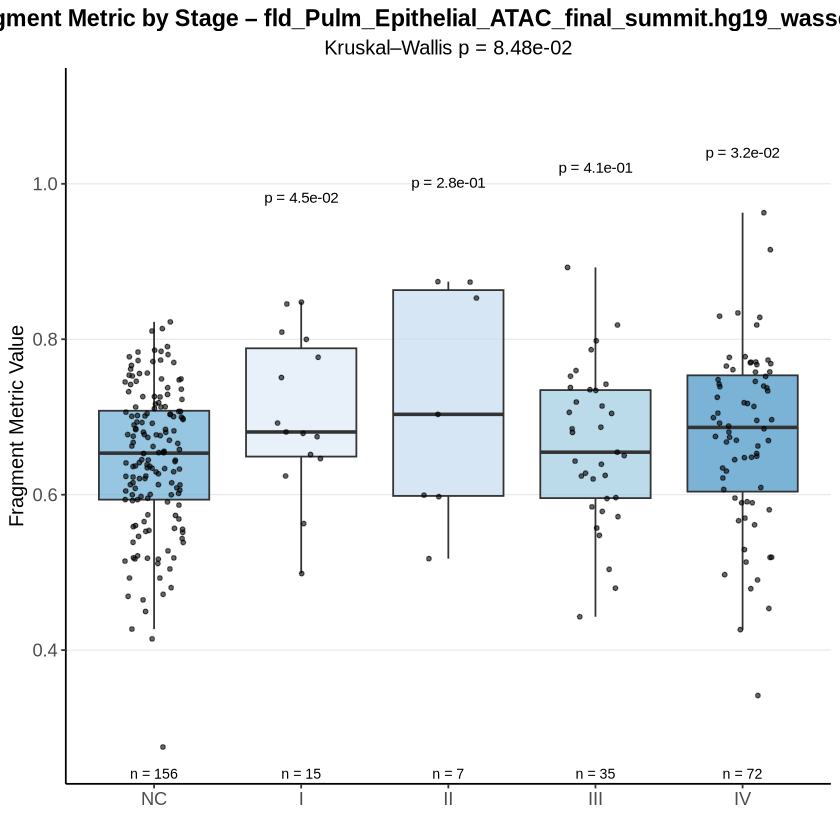

In [311]:
#!/usr/bin/env Rscript
# ================================================================
# cfDNA Fragment Metric by Stage – Keyword-based CRE selection
# with NC vs Stage pairwise p-values
# ================================================================
# Example: keywords <- c("Pulm", "ATAC")
# ================================================================

library(ggplot2)
library(dplyr)
library(scales)

# -----------------------------
# 1. Specify keywords
# -----------------------------
keywords <- c("Pulm", "ATAC", "2d")   # <<< EDIT this for your target CRE

# -----------------------------
# 2. Find matching column
# -----------------------------
matching_cols <- names(lucas_df_final)[
  sapply(names(lucas_df_final), function(col)
    all(sapply(keywords, function(k) grepl(k, col, ignore.case = TRUE)))
  )
]

if (length(matching_cols) == 0) {
  stop("❌ No columns found matching all keywords: ", paste(keywords, collapse = ", "))
}
if (length(matching_cols) > 1) {
  cat("⚠️ Multiple matches found:\n")
  print(matching_cols)
  cat("Using the first match.\n")
}

metric_col <- matching_cols[1]
cat("✅ Selected CRE column:", metric_col, "\n")

# -----------------------------
# 3. Prepare the data
# -----------------------------
plot_data <- lucas_df_final %>%
  mutate(fragment_metric = .data[[metric_col]]) %>%
  mutate(
    Stage_factor = case_when(
      is.na(Stage) | Stage == "NA" ~ "NC",
      Stage == "I" ~ "I",
      Stage == "II" ~ "II",
      Stage == "III" ~ "III",
      Stage == "IV" ~ "IV",
      TRUE ~ as.character(Stage)
    ),
    Stage_factor = factor(Stage_factor, levels = c("NC", "I", "II", "III", "IV"))
  ) %>%
  filter(!is.na(fragment_metric))

# -----------------------------
# 4. Count samples per stage
# -----------------------------
stage_counts <- plot_data %>%
  count(Stage_factor) %>%
  mutate(label = paste0("n = ", n))

# -----------------------------
# 5. Overall Kruskal–Wallis test
# -----------------------------
kw_p <- kruskal.test(fragment_metric ~ Stage_factor, data = plot_data)$p.value

# -----------------------------
# 6. Pairwise NC vs stage Wilcoxon tests
# -----------------------------
stages <- setdiff(levels(plot_data$Stage_factor), "NC")

pairwise_pvals <- sapply(stages, function(stage) {
  nc_vals <- plot_data$fragment_metric[plot_data$Stage_factor == "NC"]
  st_vals <- plot_data$fragment_metric[plot_data$Stage_factor == stage]
  if (length(nc_vals) > 1 && length(st_vals) > 1) {
    p <- wilcox.test(nc_vals, st_vals)$p.value
  } else {
    p <- NA_real_
  }
  p
})

pairwise_df <- data.frame(
  Comparison = paste0("NC vs ", stages),
  p_value = pairwise_pvals
) %>%
  mutate(p_label = ifelse(is.na(p_value), "n/a",
                          paste0("p = ", format(p_value, digits = 2, scientific = TRUE))))

cat("\nPairwise Wilcoxon tests (NC vs Stage):\n")
print(pairwise_df)

# -----------------------------
# 7. Build the plot
# -----------------------------
p <- ggplot(plot_data, aes(x = Stage_factor, y = fragment_metric)) +
  geom_boxplot(aes(fill = Stage_factor), alpha = 0.7, outlier.shape = NA) +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6) +
  scale_fill_manual(values = c(
    "NC" = "#6BAED6", "I" = "#DEEBF7", "II" = "#C6DBEF",
    "III" = "#9ECAE1", "IV" = "#4292C6"
  )) +
  labs(
    title = paste("Fragment Metric by Stage –",
                  gsub("^cre_", "", metric_col)),
    subtitle = paste0("Kruskal–Wallis p = ",
                      format(kw_p, digits = 3, scientific = TRUE)),
    x = "",
    y = "Fragment Metric Value"
  ) +
  theme_classic() +
  theme(
    legend.position = "none",
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold"),
    plot.subtitle = element_text(hjust = 0.5, size = 12),
    axis.text = element_text(size = 11),
    axis.title.y = element_text(size = 12),
    panel.grid.major.y = element_line(color = "grey90", size = 0.3)
  ) +
  coord_cartesian(
    ylim = c(min(plot_data$fragment_metric, na.rm = TRUE) * 0.98,
             max(plot_data$fragment_metric, na.rm = TRUE) * 1.15)
  ) +
  scale_y_continuous(breaks = scales::pretty_breaks(n = 6))

# -----------------------------
# 8. Annotate sample counts below boxes
# -----------------------------
for (i in seq_len(nrow(stage_counts))) {
  p <- p + annotate(
    "text",
    x = i,
    y = min(plot_data$fragment_metric, na.rm = TRUE) -
        0.05 * diff(range(plot_data$fragment_metric, na.rm = TRUE)),
    label = stage_counts$label[i],
    size = 3
  )
}

# -----------------------------
# 9. Add NC vs Stage p-values above boxes
# -----------------------------
y_max <- max(plot_data$fragment_metric, na.rm = TRUE)
y_offset <- 0.05 * diff(range(plot_data$fragment_metric, na.rm = TRUE))

for (i in seq_along(stages)) {
  p_label <- pairwise_df$p_label[i]
  p <- p + annotate(
    "text",
    x = i + 1,  # stage position (NC is x=1)
    y = y_max + (i * 0.02 * y_max),  # stagger text labels
    label = p_label,
    size = 3.2,
    color = "black"
  )
}

# -----------------------------
# 10. Display the plot
# -----------------------------
print(p)

# -----------------------------
# 11. Summary statistics
# -----------------------------
cat("\nFragment Metric by Stage Summary:\n")
plot_data %>%
  group_by(Stage_factor) %>%
  summarise(
    n = n(),
    mean = round(mean(fragment_metric, na.rm = TRUE), 3),
    median = round(median(fragment_metric, na.rm = TRUE), 3),
    sd = round(sd(fragment_metric, na.rm = TRUE), 3),
    .groups = "drop"
  ) %>%
  print()


In [313]:
#!/usr/bin/env Rscript
# ================================================================
# Early (Stage I/II) vs Non-cancer (NC) across all *_wasserstein2d CREs
# Outputs: top 10 most differential CREs with p-values and FDR
# Toggle ATAC-only features via 'atac_only'
# ================================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
})

stopifnot(exists("lucas_df_final"))

# -----------------------------
# 0) Toggle: restrict to ATAC-only features?
# -----------------------------
atac_only <- FALSE  # set TRUE to keep only features with "ATAC" in the name

# -----------------------------
# 1) Identify *_wasserstein2d feature columns
# -----------------------------
fld_cols <- grep("^cre_.*_wasserstein2d$", names(lucas_df_final),
                 value = TRUE, ignore.case = TRUE)

if (atac_only) {
  fld_cols <- fld_cols[stringr::str_detect(fld_cols, "ATAC", ignore_case = TRUE)]
}
stopifnot(length(fld_cols) > 0)

cat("Features considered (wasserstein2d):", length(fld_cols),
    if (atac_only) "(ATAC-only)\n" else "(ALL)\n")

# -----------------------------
# 2) Build comparison groups:
#     - Early: type == "cancer" & Stage %in% c("I","II")
#     - NC   : type == "healthy" OR Stage is NA / "NA"
#   (All other samples excluded)
# -----------------------------
df_cmp <- lucas_df_final %>%
  dplyr::mutate(
    Stage_chr = as.character(Stage),
    Group = dplyr::case_when(
      type == "cancer" & Stage_chr %in% c("I","II") ~ "Early",
      type == "healthy" | is.na(Stage_chr) | Stage_chr == "NA" ~ "NC",
      TRUE ~ NA_character_
    )
  ) %>%
  dplyr::filter(Group %in% c("NC","Early")) %>%
  dplyr::mutate(Group = factor(Group, levels = c("NC","Early"))) %>%
  dplyr::select(id, type, Stage, Group, dplyr::all_of(fld_cols))

cat("Samples in comparison — NC:", sum(df_cmp$Group=="NC"),
    "| Early:", sum(df_cmp$Group=="Early"), "\n")

# Guardrail: need at least 2 per group
if (sum(df_cmp$Group=="NC") < 2 || sum(df_cmp$Group=="Early") < 2) {
  stop("Not enough samples per group (need ≥2 in NC and Early).")
}

# -----------------------------
# 3) Long format
# -----------------------------
long <- df_cmp %>%
  tidyr::pivot_longer(cols = dplyr::all_of(fld_cols),
                      names_to = "CRE", values_to = "value")

# -----------------------------
# 4) Per-CRE Wilcoxon (Early vs NC), medians, effect, FDR
# -----------------------------
res <- long %>%
  dplyr::group_by(CRE) %>%
  dplyr::summarise(
    n_NC   = sum(Group=="NC"    & is.finite(value)),
    n_Early= sum(Group=="Early" & is.finite(value)),
    med_NC = median(value[Group=="NC"],    na.rm = TRUE),
    med_Early = median(value[Group=="Early"], na.rm = TRUE),
    diff_median = med_Early - med_NC,  # + means higher in Early
    p_wilcox = tryCatch(wilcox.test(value ~ Group)$p.value, error = function(e) NA_real_),
    .groups = "drop"
  ) %>%
  dplyr::mutate(
    fdr = p.adjust(p_wilcox, method = "BH"),
    direction = dplyr::if_else(diff_median > 0, "Higher in Early", "Lower in Early"),
    CRE_label = CRE %>%
      stringr::str_remove("^cre_") %>%
      stringr::str_remove("_wasserstein2d$") %>%
      stringr::str_replace_all("_", " ")
  )

# -----------------------------
# 5) Top 10 by |Δ median|, then FDR
# -----------------------------
top10 <- res %>%
  dplyr::mutate(abs_effect = abs(diff_median)) %>%
  dplyr::arrange(dplyr::desc(abs_effect), fdr) %>%
  dplyr::slice(1:10) %>%
  dplyr::select(
    CRE = CRE_label,
    n_NC, n_Early,
    median_NC = med_NC,
    median_Early = med_Early,
    diff_median,
    direction,
    p_wilcox,
    fdr
  )

cat("\n===== Early (I/II) vs NC — Top 10 most differential (wasserstein2d) =====\n")
top10

# Optional: write to CSV
# readr::write_csv(top10, if (atac_only) "early_vs_NC_top10_w2d_ATAC.csv" else "early_vs_NC_top10_w2d_ALL.csv")


Features considered (wasserstein2d): 51 (ALL)
Samples in comparison — NC: 158 | Early: 22 

===== Early (I/II) vs NC — Top 10 most differential (wasserstein2d) =====


CRE,n_NC,n_Early,median_NC,median_Early,diff_median,direction,p_wilcox,fdr
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
fld Stromal B-Neuroendocrine overlap ranges.hg19,156,22,0.7958985,0.9711452,0.17524666,Higher in Early,0.013240707,0.16881901
fld Ubiquitous ATAC final summit.hg19,156,22,2.3988735,2.5409861,0.14211260,Higher in Early,0.036374447,0.18550968
fld Neural-Neuronal Glial overlap ranges.hg19,156,22,0.8422604,0.9429717,0.10071133,Higher in Early,0.075252922,0.23986869
fld Tissue invariant DHS final summit.hg19,156,22,0.9728392,1.0631542,0.09031502,Higher in Early,0.046473830,0.19007959
fld Tissue invariant-Ubiquitous overlap ranges.hg19,156,22,2.7728683,2.8630994,0.09023115,Higher in Early,0.546318563,0.63323288
fld Follicular ATAC final summit.hg19,156,22,0.6108638,0.7005602,0.08969638,Higher in Early,0.003459914,0.07467831
fld Vascular endothelial-Endothelial overlap ranges.hg19,156,22,0.7994471,0.8881916,0.08874450,Higher in Early,0.124578232,0.33173463
fld Stromal B-Stromal overlap ranges.hg19,156,22,0.7946927,0.8711336,0.07644089,Higher in Early,0.036374447,0.18550968
fld Gastric Epithelial ATAC final summit.hg19,156,22,0.4959758,0.5697597,0.07378392,Higher in Early,0.048451659,0.19007959


✅ Using column: cre_fld_Pulm_Epithelial_ATAC_final_summit.hg19_wasserstein2d 

Pulmonary ATAC CRE summary:
# A tibble: 2 × 5
  Group          n  mean median    sd
  <chr>      <int> <dbl>  <dbl> <dbl>
1 Cancer       129 0.677  0.681 0.11 
2 Non-cancer   156 0.645  0.653 0.093


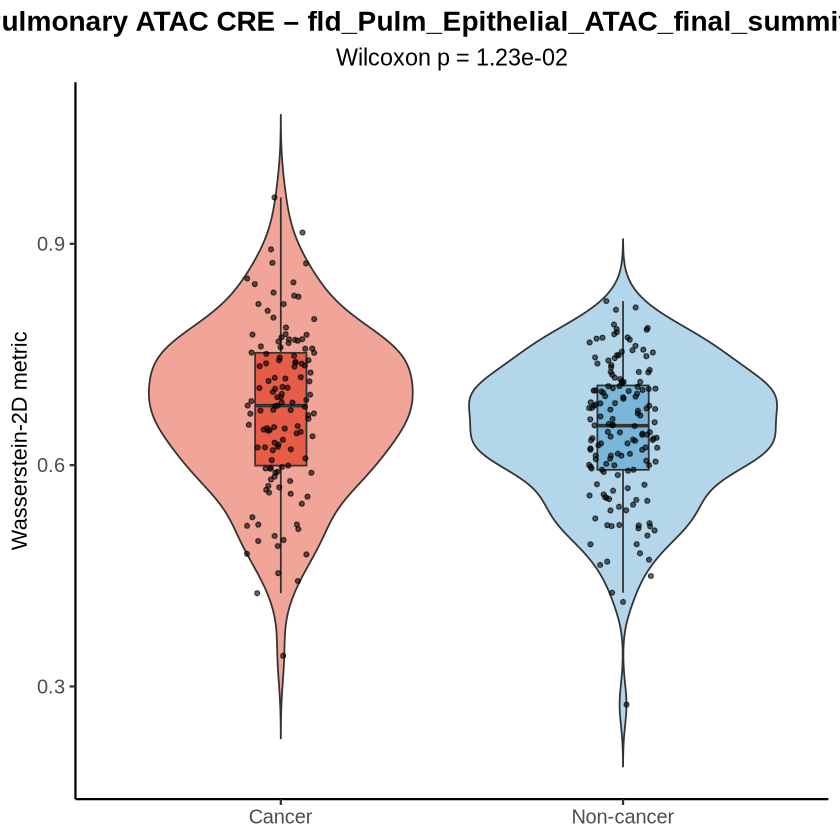

In [338]:
#!/usr/bin/env Rscript
# ================================================================
# Plot Pulmonary ATAC CRE distribution – Cancer vs Non-cancer
# ================================================================

library(ggplot2)
library(dplyr)

# --- 1. Locate the Pulm + ATAC column ---
pulm_col <- names(lucas_df_final)[
  sapply(names(lucas_df_final),
         function(x) all(sapply(c("Pulm","ATAC", "2d"), function(k)
           grepl(k, x, ignore.case = TRUE))))
]

if (length(pulm_col) == 0) stop("No Pulm + ATAC column found.")
if (length(pulm_col) > 1) {
  cat("⚠ Multiple matches found:\n"); print(pulm_col)
  cat("Using the first one.\n")
}
pulm_col <- pulm_col[1]
cat("✅ Using column:", pulm_col, "\n")

# --- 2. Build plotting dataframe ---
plot_df <- lucas_df_final %>%
  filter(type %in% c("healthy","cancer")) %>%
  mutate(Group = ifelse(type == "cancer","Cancer","Non-cancer"),
         Pulm_metric = .data[[pulm_col]]) %>%
  filter(!is.na(Pulm_metric))

# --- 3. Wilcoxon test ---
p_val <- wilcox.test(Pulm_metric ~ Group, data = plot_df)$p.value

# --- 4. Violin + boxplot ---
p <- ggplot(plot_df, aes(x = Group, y = Pulm_metric, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.5) +
  geom_boxplot(width = 0.15, outlier.shape = NA, alpha = 0.8) +
  geom_jitter(width = 0.1, size = 1.1, alpha = 0.6) +
  scale_fill_manual(values = c("Non-cancer"="#6BAED6", "Cancer"="#E34A33")) +
  labs(
    title = paste("Pulmonary ATAC CRE –", gsub("^cre_|_wasserstein2d$","",pulm_col)),
    subtitle = paste0("Wilcoxon p = ", format(p_val, digits = 3, scientific = TRUE)),
    x = NULL, y = "Wasserstein-2D metric"
  ) +
  theme_classic(base_size = 14) +
  theme(
    legend.position = "none",
    plot.title = element_text(hjust = 0.5, face = "bold"),
    plot.subtitle = element_text(hjust = 0.5),
    axis.text = element_text(size = 12),
    axis.title.y = element_text(size = 13)
  )

print(p)

# --- 5. Summary table ---
cat("\nPulmonary ATAC CRE summary:\n")
plot_df %>%
  group_by(Group) %>%
  summarise(
    n = n(),
    mean = round(mean(Pulm_metric, na.rm = TRUE), 3),
    median = round(median(Pulm_metric, na.rm = TRUE), 3),
    sd = round(sd(Pulm_metric, na.rm = TRUE), 3),
    .groups = "drop"
  ) %>%
  print()


In [339]:
#!/usr/bin/env Rscript
# ================================================================
# Ulz-style Rank-Based Differential Analysis for ATAC CREs
#   Groups: Early (Stage I/II cancer) vs Non-cancer (NC)
#   Features: all columns containing "ATAC" and "_wasserstein2d"
# ================================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(readr)
})

stopifnot(exists("lucas_df_final"))

# ================================================================
# 1. Identify ATAC Wasserstein2D columns
# ================================================================
fld_cols <- names(lucas_df_final)[
  sapply(names(lucas_df_final), function(col)
    all(sapply(c("ATAC", "_wasserstein2d"), function(k)
      grepl(k, col, ignore.case = TRUE)
    ))
  )
]

if (length(fld_cols) == 0)
  stop("❌ No ATAC wasserstein2d columns found in lucas_df_final.")

cat("✅ Found", length(fld_cols), "ATAC wasserstein2d features:\n")
print(fld_cols)

# ================================================================
# 2. Define groups: Early (I/II) vs Non-cancer (NC)
# ================================================================
df_grp <- lucas_df_final %>%
  mutate(
    Stage_chr = as.character(Stage),
    Group = case_when(
      type == "cancer" & Stage_chr %in% c("I", "II") ~ "Early",
      type == "healthy" | is.na(Stage_chr) | Stage_chr == "NA" ~ "NC",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(Group)) %>%
  mutate(Group = factor(Group, levels = c("NC", "Early"))) %>%
  dplyr::select(id, Group, dplyr::all_of(fld_cols))

cat("Samples — NC:", sum(df_grp$Group == "NC"),
    "| Early:", sum(df_grp$Group == "Early"), "\n")

if (sum(df_grp$Group == "NC") < 2 || sum(df_grp$Group == "Early") < 2)
  stop("Need ≥2 samples per group.")

# ================================================================
# 3. Rank within each sample (across CREs)
# ================================================================
ranked_df <- df_grp %>%
  mutate(across(
    all_of(fld_cols),
    ~ rank(-., ties.method = "average"),
    .names = "{.col}__rank"
  ))

# ================================================================
# 4. Convert to long format
# ================================================================
long_rank <- ranked_df %>%
  pivot_longer(
    cols = ends_with("__rank"),
    names_to = "CRE_raw",
    values_to = "rank_value"
  ) %>%
  mutate(CRE = str_remove(CRE_raw, "__rank$"))

# ================================================================
# 5. Per-CRE rank-based differential test
# ================================================================
res_rank <- long_rank %>%
  group_by(CRE) %>%
  summarise(
    n_NC    = sum(Group == "NC" & is.finite(rank_value)),
    n_Early = sum(Group == "Early" & is.finite(rank_value)),
    med_rank_NC    = median(rank_value[Group == "NC"], na.rm = TRUE),
    med_rank_Early = median(rank_value[Group == "Early"], na.rm = TRUE),
    diff_med_rank  = med_rank_Early - med_rank_NC,  # +: less dominant in Early
    p_wilcox = tryCatch(stats::wilcox.test(rank_value ~ Group)$p.value,
                        error = function(e) NA_real_),
    .groups = "drop"
  ) %>%
  mutate(
    fdr = p.adjust(p_wilcox, method = "BH"),
    direction = if_else(diff_med_rank > 0,
                        "Higher rank in Early (less accessible)",
                        "Lower rank in Early (more accessible)"),
    CRE_label = CRE %>%
      str_remove("^cre_") %>%
      str_remove("_wasserstein2d$") %>%
      str_replace_all("_", " ")
  ) %>%
  arrange(desc(abs(diff_med_rank)), fdr)

# ================================================================
# 6. Output ranked results
# ================================================================
out_csv <- "UlzStyle_rank_based_ATAC_CRE_differentials.csv"

res_out <- res_rank %>%
  dplyr::select(
    CRE_label, n_NC, n_Early,
    med_rank_NC, med_rank_Early,
    diff_med_rank, direction,
    p_wilcox, fdr
  )

cat("\n===== Ulz-style Rank-Based ATAC CRE Differential Results =====\n")
print(res_out, n = nrow(res_out))

readr::write_csv(res_out, out_csv)
cat("\n✓ Ulz-style rank-based ATAC analysis complete.\n",
    "  → Results saved to:", out_csv, "\n")


✅ Found 20 ATAC wasserstein2d features:
 [1] "cre_fld_Adrenal_Cortical_ATAC_final_summit.hg19_wasserstein2d"       
 [2] "cre_fld_Adult_Stromal_ATAC_final_summit.hg19_wasserstein2d"          
 [3] "cre_fld_Cardiomyocyte_ATAC_final_summit.hg19_wasserstein2d"          
 [4] "cre_fld_Endothelial_ATAC_final_summit.hg19_wasserstein2d"            
 [5] "cre_fld_Erythroid_ATAC_final_summit.hg19_wasserstein2d"              
 [6] "cre_fld_Fetal_Neuronal_Glial_ATAC_final_summit.hg19_wasserstein2d"   
 [7] "cre_fld_Follicular_ATAC_final_summit.hg19_wasserstein2d"             
 [8] "cre_fld_Gastric_Epithelial_ATAC_final_summit.hg19_wasserstein2d"     
 [9] "cre_fld_GI_Epithelial_ATAC_final_summit.hg19_wasserstein2d"          
[10] "cre_fld_Hepatocyte_ATAC_final_summit.hg19_wasserstein2d"             
[11] "cre_fld_Immune_ATAC_final_summit.hg19_wasserstein2d"                 
[12] "cre_fld_Neuroendocrine_ATAC_final_summit.hg19_wasserstein2d"         
[13] "cre_fld_Neuronal_Glial_ATAC_final_summit.h

Found 89 CRE rel_cov_profile features

Significant CREs (BH FDR < 0.05): 71 
# A tibble: 20 × 9
   CRE_name  n_cancer n_healthy mean_cancer mean_healthy    diff p_value   p_adj
   <chr>        <int>     <int>       <dbl>        <dbl>   <dbl>   <dbl>   <dbl>
 1 ATAC_fil…      129       158       1.07         1.09  0.0170  1.01e-7 9.00e-6
 2 ATAC_fil…      129       158       1.06         1.08  0.0165  6.07e-7 2.47e-5
 3 DHS_filt…      129       158       1.12         1.14  0.0109  1.11e-6 2.47e-5
 4 TCGA_fil…      129       158       1.08         1.09  0.0152  8.33e-7 2.47e-5
 5 ATAC_fil…      129       158       1.09         1.10  0.0148  2.18e-6 3.71e-5
 6 DHS_filt…      129       158       1.12         1.13  0.0104  2.50e-6 3.71e-5
 7 ATAC_fil…      129       158       1.10         1.11  0.00839 3.94e-6 5.00e-5
 8 ATAC_fil…      129       158       1.09         1.11  0.0169  8.75e-6 7.78e-5
 9 CRE_over…      129       158       1.02         1.04  0.0214  7.06e-6 7.78e-5
10 TCGA_fil… 

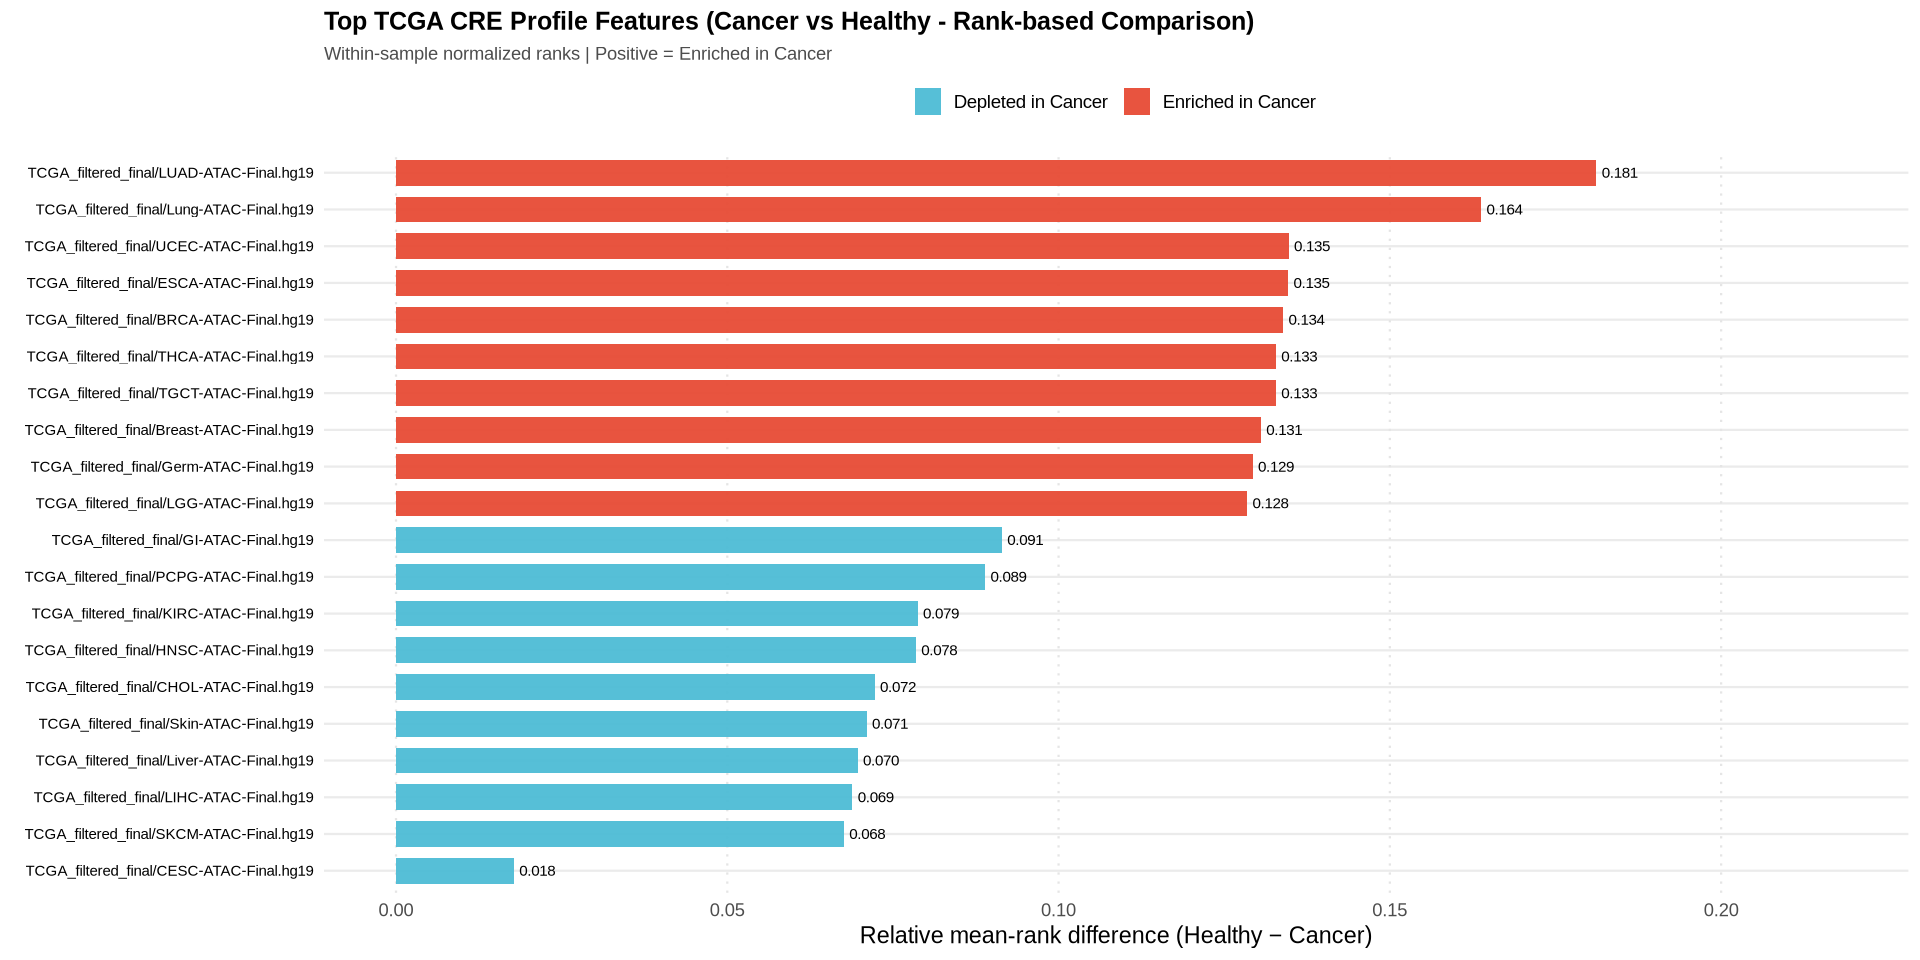

In [30]:
#!/usr/bin/env Rscript
# ===============================================================
# Wilcoxon comparison (Cancer vs Healthy) – rel_cov_profile
# With rank-based visualization
# ===============================================================
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(ggplot2)
})

# ---------------------------------------------------------------
# 1. Identify rel_cov_profile features
# ---------------------------------------------------------------
cre_relcov_cols <- grep("cre_relcov_.*_rel_cov_profile$", names(lucas_df_relcov), value = TRUE)
cat("Found", length(cre_relcov_cols), "CRE rel_cov_profile features\n\n")

# ---------------------------------------------------------------
# 2. Prepare dataframe
# ---------------------------------------------------------------
df_long <- lucas_df_relcov %>%
  dplyr::select(id, type, dplyr::all_of(cre_relcov_cols)) %>%
  tidyr::pivot_longer(
    cols = dplyr::all_of(cre_relcov_cols),
    names_to = "CRE_feature",
    values_to = "rel_cov"
  ) %>%
  dplyr::mutate(
    CRE_name = gsub("cre_relcov_", "", CRE_feature),
    CRE_name = gsub("_rel_cov_profile$", "", CRE_name)
  )

# ---------------------------------------------------------------
# 3. Perform Wilcoxon test per CRE
# ---------------------------------------------------------------
wilcox_results <- df_long %>%
  dplyr::group_by(CRE_name) %>%
  dplyr::summarise(
    n_cancer  = sum(type == "cancer"),
    n_healthy = sum(type == "healthy"),
    mean_cancer  = mean(rel_cov[type == "cancer"], na.rm = TRUE),
    mean_healthy = mean(rel_cov[type == "healthy"], na.rm = TRUE),
    diff = mean_healthy - mean_cancer,  # FLIPPED: healthy - cancer
    p_value = tryCatch(
      wilcox.test(rel_cov ~ type, exact = FALSE)$p.value,
      error = function(e) NA_real_
    ),
    .groups = "drop"
  ) %>%
  dplyr::mutate(
    p_adj = p.adjust(p_value, method = "BH"),
    sig = p_adj < 0.05
  ) %>%
  dplyr::arrange(p_adj)

cat("Significant CREs (BH FDR < 0.05):", sum(wilcox_results$sig, na.rm = TRUE), "\n")
print(head(wilcox_results, 20))

# ---------------------------------------------------------------
# 4. Filter for TCGA results
# ---------------------------------------------------------------
wilcox_results_tcga <- wilcox_results %>%
  dplyr::filter(grepl("TCGA", CRE_name, ignore.case = TRUE))

cat("\nFiltered to TCGA CREs only:\n")
cat("Total TCGA CREs:", nrow(wilcox_results_tcga), "\n")
cat("Significant TCGA CREs (BH FDR < 0.05):", sum(wilcox_results_tcga$sig, na.rm = TRUE), "\n\n")
print(wilcox_results_tcga)

# ---------------------------------------------------------------
# 5. Calculate rank-based differences for visualization
# ---------------------------------------------------------------
# Within-sample rank normalization
rank_df <- lucas_df_relcov %>%
  dplyr::select(id, type, dplyr::all_of(cre_relcov_cols)) %>%
  dplyr::mutate(across(
    all_of(cre_relcov_cols),
    ~ rank(.x, na.last = "keep", ties.method = "average") / sum(!is.na(.x)),
    .names = "{.col}_rank"
  ))

# Get rank column names
rank_cols <- grep("_rank$", names(rank_df), value = TRUE)

# Pivot to long format
rank_long <- rank_df %>%
  tidyr::pivot_longer(
    cols = all_of(rank_cols),
    names_to = "feature",
    values_to = "rank"
  ) %>%
  dplyr::mutate(
    feature = gsub("cre_relcov_", "", feature),
    feature = gsub("_rel_cov_profile_rank$", "", feature)
  )

# Calculate relative rank differences
profile_df <- rank_long %>%
  dplyr::group_by(feature) %>%
  dplyr::summarise(
    mean_rank_cancer = mean(rank[type == "cancer"], na.rm = TRUE),
    mean_rank_healthy = mean(rank[type == "healthy"], na.rm = TRUE),
    relative_diff = mean_rank_healthy - mean_rank_cancer,  # FLIPPED: healthy - cancer
    .groups = "drop"
  )

# Filter for TCGA only
profile_df_tcga <- profile_df %>%
  dplyr::filter(grepl("TCGA", feature, ignore.case = TRUE))

# ---------------------------------------------------------------
# 6. Plotting function
# ---------------------------------------------------------------
plot_top_features <- function(df, title_text, n_top = 10, file_name = NULL, 
                              width = 16, height = 8) {
  # ---- select top enriched & depleted ----
  top_enriched <- df %>%
    arrange(desc(relative_diff)) %>%
    slice_head(n = n_top) %>%
    mutate(status = "Enriched in Cancer")
  
  top_depleted <- df %>%
    arrange(relative_diff) %>%
    slice_head(n = n_top) %>%
    mutate(status = "Depleted in Cancer")
  
  # ---- combine safely (deduplicate features) ----
  plot_df <- bind_rows(top_enriched, top_depleted) %>%
    distinct(feature, .keep_all = TRUE) %>%
    arrange(relative_diff) %>%
    mutate(feature = factor(feature, levels = unique(feature)))
  
  # ---- SET PLOT SIZE FOR JUPYTER ----
  options(repr.plot.width = width, repr.plot.height = height)
  
  # ---- build plot ----
  p <- ggplot(plot_df, aes(x = feature, y = relative_diff, fill = status)) +
    geom_col(width = 0.7, alpha = 0.95) +
    coord_flip() +
    scale_fill_manual(values = c("Enriched in Cancer" = "#E64B35FF",
                                 "Depleted in Cancer" = "#4DBBD5FF")) +
    geom_text(aes(label = sprintf("%.3f", relative_diff)),
              hjust = ifelse(plot_df$relative_diff > 0, -0.15, 1.15),
              size = 3.2, color = "black") +
    labs(
      title = title_text,
      subtitle = "Within-sample normalized ranks | Positive = Enriched in Cancer",
      x = NULL,
      y = "Relative mean-rank difference (Healthy − Cancer)",  # UPDATED LABEL
      fill = NULL
    ) +
    theme_minimal(base_size = 14) +
    theme(
      plot.title = element_text(face = "bold", size = 15, hjust = 0),
      plot.subtitle = element_text(size = 11, color = "gray30", hjust = 0),
      axis.text.y = element_text(size = 9, color = "black"),
      axis.text.x = element_text(size = 11),
      legend.position = "top",
      panel.grid.major.x = element_line(color = "gray90", linetype = "dotted"),
      panel.grid.minor = element_blank()
    ) +
    expand_limits(y = c(min(plot_df$relative_diff) * 1.2,
                        max(plot_df$relative_diff) * 1.2))
  
  print(p)
  
  if (!is.null(file_name)) {
    ggsave(file_name, p, width = width, height = height, dpi = 300)
    message("💾 Saved: ", file_name)
  }
}

# ---------------------------------------------------------------
# 7. Generate plots
# ---------------------------------------------------------------
# Set larger figure dimensions for Jupyter
options(repr.plot.width = 16, repr.plot.height = 8)


# Plot TCGA features only
plot_top_features(profile_df_tcga, 
                  "Top TCGA CRE Profile Features (Cancer vs Healthy - Rank-based Comparison)",
                  n_top = 10)

### Rel cov analysis

In [89]:
#!/usr/bin/env Rscript
# ===================================================================
# Visualize CRE relative coverage for a single cancer sample
# ===================================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(ggplot2)
})

# ------------------------------------------------------------------
# 1. Select one cancer sample
# ------------------------------------------------------------------
cancer_sample <- lucas_df_final %>%
  dplyr::filter(type == "healthy") %>%
  dplyr::slice(4)  # change this index as needed

# Print sample info, including ichor
cat("\nSelected cancer sample:\n")
cat("  Patient ID :", cancer_sample$Patient, "\n")
cat("  Type       :", cancer_sample$type, "\n")
cat("  ichor (tumor fraction):", cancer_sample$ichor, "\n\n")

# ------------------------------------------------------------------
# 2. Identify CRE columns and exclude placenta/trophoblast/fetal
# ------------------------------------------------------------------
cre_cols <- grep("cre_relcov_.*_rel_cov_profile$", names(cancer_sample), value = TRUE)
exclude_cols <- grep("Placenta|trophoblast|fetal|devel|Stromal|embryo|ATAC|DHS", cre_cols, value = TRUE, ignore.case = TRUE)
cre_cols <- setdiff(cre_cols, exclude_cols)

cat("Number of CREs kept:", length(cre_cols), "\n")
cat("Excluded CREs matching Placenta/trophoblast/fetal:", length(exclude_cols), "\n\n")

# ------------------------------------------------------------------
# 3. Convert to long format and clean names
# ------------------------------------------------------------------
cre_long <- cancer_sample %>%
  dplyr::select(all_of(cre_cols)) %>%
  tidyr::pivot_longer(
    cols = everything(),
    names_to = "CRE",
    values_to = "raw_rel_cov"
  ) %>%
  dplyr::mutate(
    CRE = str_remove(CRE, "^cre_relcov_"),
    CRE = str_remove(CRE, "_filtered_final_summit\\.hg19_rel_cov_profile"),
    CRE = str_replace_all(CRE, "_", " ")
  ) %>%
  dplyr::arrange(desc(raw_rel_cov))

cre_long



Selected cancer sample:
  Patient ID : CGPLLU277P 
  Type       : healthy 
  ichor (tumor fraction): 0.7417 

Number of CREs kept: 9 
Excluded CREs matching Placenta/trophoblast/fetal: 42 



CRE,raw_rel_cov
<chr>,<dbl>
Vascular endothelial-Endothelial overlap ranges.hg19 rel cov profile,1.1795879
Neural-Neuronal Glial overlap ranges.hg19 rel cov profile,1.1636660
Digestive-GI Epithelial overlap ranges.hg19 rel cov profile,1.1626008
Cancer epithelial-Skin Mammary Epithelial overlap ranges.hg19 rel cov profile,1.1271294
Cardiac-Cardiomyocyte overlap ranges.hg19 rel cov profile,1.1215709
Myeloid erythroid-Erythroid overlap ranges.hg19 rel cov profile,1.1190801
Lymphoid-Immune overlap ranges.hg19 rel cov profile,1.0915772
Musculoskeletal-Skeletal Myocyte overlap ranges.hg19 rel cov profile,1.0860972
Tissue invariant-Ubiquitous overlap ranges.hg19 rel cov profile,0.4129397


In [109]:
#!/usr/bin/env Rscript
# ===================================================================
# Visualize CRE relative coverage for a single cancer sample
# ===================================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(ggplot2)
})

# ------------------------------------------------------------------
# 1. Select one cancer sample
# ------------------------------------------------------------------
cancer_sample <- lucas_df_final %>%
  dplyr::filter(type == "healthy") %>%
  dplyr::slice(20)  # change this index as needed

# Print sample info, including ichor
cat("\nSelected cancer sample:\n")
cat("  Patient ID :", cancer_sample$Patient, "\n")
cat("  Type       :", cancer_sample$type, "\n")
cat("  ichor (tumor fraction):", cancer_sample$ichor, "\n\n")

# ------------------------------------------------------------------
# 2. Identify CRE columns and exclude placenta/trophoblast/fetal
# ------------------------------------------------------------------
cre_cols <- grep("cre_relcov_.*_rel_cov_profile$", names(cancer_sample), value = TRUE)
exclude_cols <- grep("Placenta|trophoblast|fetal|devel|Stromal|embryo|DHS|Overlap", cre_cols, value = TRUE, ignore.case = TRUE)
cre_cols <- setdiff(cre_cols, exclude_cols)

cat("Number of CREs kept:", length(cre_cols), "\n")
cat("Excluded CREs matching Placenta/trophoblast/fetal:", length(exclude_cols), "\n\n")

# ------------------------------------------------------------------
# 3. Convert to long format and clean names
# ------------------------------------------------------------------
cre_long <- cancer_sample %>%
  dplyr::select(all_of(cre_cols)) %>%
  tidyr::pivot_longer(
    cols = everything(),
    names_to = "CRE",
    values_to = "raw_rel_cov"
  ) %>%
  dplyr::mutate(
    CRE = str_remove(CRE, "^cre_relcov_"),
    CRE = str_remove(CRE, "_filtered_final_summit\\.hg19_rel_cov_profile"),
    CRE = str_replace_all(CRE, "_", " ")
  ) %>%
  dplyr::arrange(desc(raw_rel_cov))

cre_long



Selected cancer sample:
  Patient ID : CGPLLU309P 
  Type       : healthy 
  ichor (tumor fraction): 0.3165 

Number of CREs kept: 16 
Excluded CREs matching Placenta/trophoblast/fetal: 35 



CRE,raw_rel_cov
<chr>,<dbl>
Skin Mammary Epithelial ATAC final summit.hg19 rel cov profile,1.1207007
Pulm Epithelial ATAC final summit.hg19 rel cov profile,1.1150830
Adrenal Cortical ATAC final summit.hg19 rel cov profile,1.1139552
Hepatocyte ATAC final summit.hg19 rel cov profile,1.1069398
Gastric Epithelial ATAC final summit.hg19 rel cov profile,1.1054224
Endothelial ATAC final summit.hg19 rel cov profile,1.0950494
Cardiomyocyte ATAC final summit.hg19 rel cov profile,1.0941799
Skeletal Myocyte ATAC final summit.hg19 rel cov profile,1.0923558
Neuronal Glial ATAC final summit.hg19 rel cov profile,1.0865877


CRE columns found: 37 | Excluded (Placenta/trophoblast/fetal): 14



# A tibble: 20 × 10
   CRE               n_cancer n_healthy median_cancer median_healthy diff_median
   <chr>                <int>     <int>         <dbl>          <dbl>       <dbl>
 1 Neuroendocrine A…      127       157         1.07           1.09     -0.0206 
 2 GI Epithelial AT…      127       157         1.06           1.08     -0.0156 
 3 Pulm Epithelial …      127       157         1.09           1.10     -0.0151 
 4 Skin Mammary Epi…      127       157         1.10           1.11     -0.0150 
 5 Cancer epithelia…      127       157         1.12           1.13     -0.0103 
 6 Gastric Epitheli…      127       157         1.10           1.11     -0.00800
 7 Pancreatic Epith…      127       157         1.03           1.04     -0.00993
 8 Cancer epithelia…      127       157         1.11           1.13     -0.0187 
 9 Adrenal Cortical…      127       157         1.08           1.09     -0.00971
10 Follicular ATAC …      127       157         1.07           1.08     -0.0108 
11 Neuro

Warning message:
“Removed 37 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 37 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


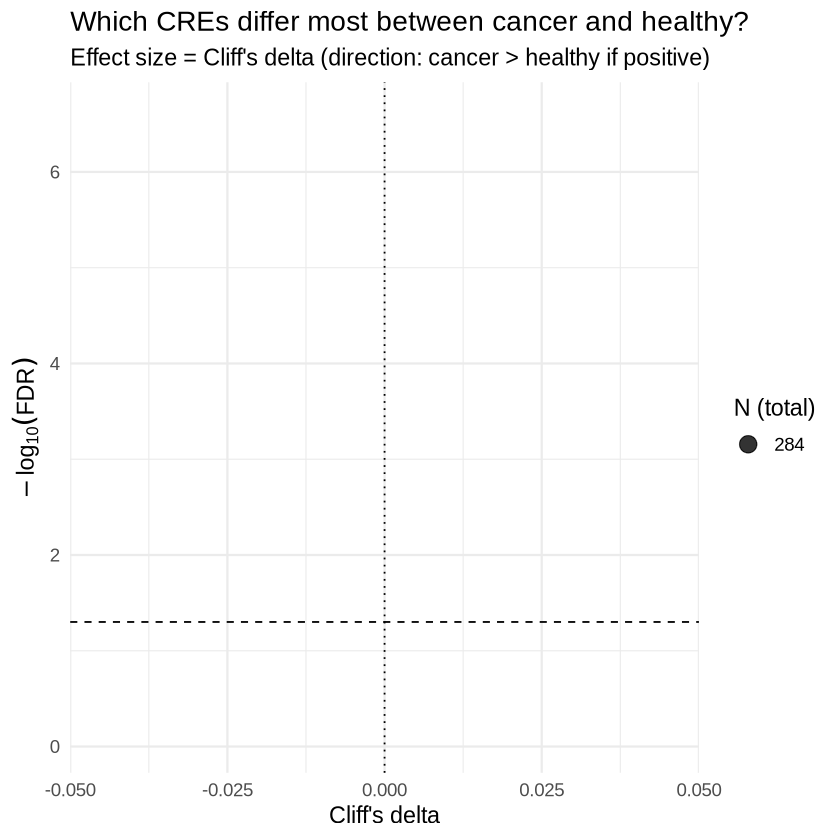

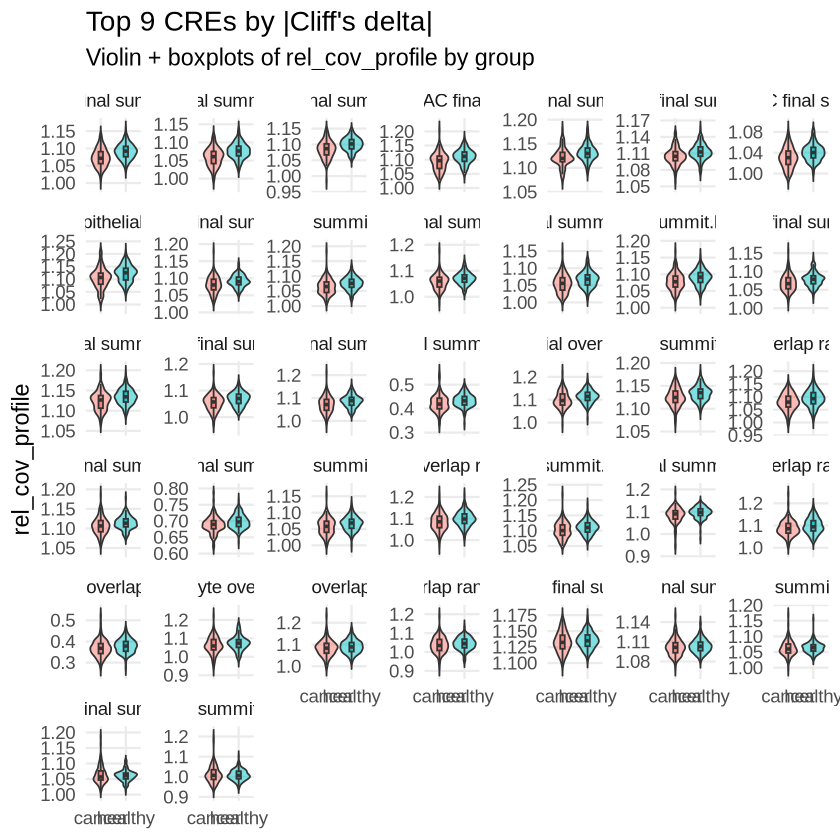

In [112]:
#!/usr/bin/env Rscript
# ===================================================================
# Which CREs differ most between cancer and healthy?
#  - Uses rel_cov_profile features
#  - Excludes Placenta / trophoblast / fetal
#  - Computes Wilcoxon + BH FDR, Cliff's delta, AUROC, medians
#  - Plots volcano (effect vs FDR) and top-K distribution plots
# ===================================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(purrr)
  library(ggplot2)
  library(broom)
})

# Optional: load effect size + AUC if available
has_effsize <- requireNamespace("effsize", quietly = TRUE)
has_pROC    <- requireNamespace("pROC", quietly = TRUE)
has_ggrepel <- requireNamespace("ggrepel", quietly = TRUE)

# -----------------------------
# 1) Collect & clean data
# -----------------------------
stopifnot(exists("lucas_df_final"))

# Keep only cancer/healthy rows
df <- lucas_df_final %>%
  dplyr::select(Patient, id, type, everything()) %>%
  dplyr::filter(type %in% c("cancer", "healthy")) %>%
  dplyr::mutate(type = factor(type) |> droplevels())

# Identify *_rel_cov_profile columns and exclude placenta/trophoblast/fetal
cre_cols_all <- grep("^cre_relcov_.*_rel_cov_profile$", names(df), value = TRUE)
exclude_cols <- grep("Placenta|trophoblast|fetal|embryo|Stromal", cre_cols_all, value = TRUE, ignore.case = TRUE)
cre_cols     <- setdiff(cre_cols_all, exclude_cols)

message("CRE columns found: ", length(cre_cols),
        " | Excluded (Placenta/trophoblast/fetal): ", length(exclude_cols))

stopifnot(length(cre_cols) > 0)

long_df <- df %>%
  dplyr::select(Patient, id, type, all_of(cre_cols)) %>%
  tidyr::pivot_longer(
    cols = all_of(cre_cols),
    names_to = "CRE_raw",
    values_to = "value"
  ) %>%
  dplyr::filter(!is.na(value)) %>%
  dplyr::mutate(
    CRE = CRE_raw %>%
      str_remove("^cre_relcov_") %>%
      str_remove("_filtered_final_summit\\.hg19_rel_cov_profile$") %>%
      str_replace_all("_", " ")
  )

# -----------------------------
# 2) Stats per CRE
# -----------------------------
safe_stats <- function(d) {
  # d has cols: value, type (cancer/healthy)
  # Return one-row tibble of stats
  x <- d$value[d$type == "cancer"]
  y <- d$value[d$type == "healthy"]

  n_cancer  <- length(x)
  n_healthy <- length(y)

  if (n_cancer < 2 || n_healthy < 2) {
    return(tibble(
      n_cancer = n_cancer, n_healthy = n_healthy,
      median_cancer = median(x, na.rm = TRUE),
      median_healthy = median(y, na.rm = TRUE),
      diff_median = median(x, na.rm = TRUE) - median(y, na.rm = TRUE),
      p_wilcox = NA_real_, fdr = NA_real_,
      cliffs_delta = NA_real_,
      auc = NA_real_
    ))
  }

  # Wilcoxon
  p_w <- tryCatch(stats::wilcox.test(x, y, exact = FALSE)$p.value, error = function(e) NA_real_)

  # Cliff's delta (direction: positive means cancer > healthy)
  cd <- tryCatch({
    if (has_effsize) {
      effsize::cliff.delta(x, y, use.simple = TRUE)$estimate
    } else {
      NA_real_
    }
  }, error = function(e) NA_real_)

  # AUROC (1 = cancer high; 0 = cancer low)
  a <- tryCatch({
    if (has_pROC) {
      pROC::roc(response = factor(d$type, levels = c("healthy", "cancer")),
                predictor = d$value, quiet = TRUE)$auc %>% as.numeric()
    } else NA_real_
  }, error = function(e) NA_real_)

  tibble(
    n_cancer = n_cancer, n_healthy = n_healthy,
    median_cancer = median(x, na.rm = TRUE),
    median_healthy = median(y, na.rm = TRUE),
    diff_median = median(x, na.rm = TRUE) - median(y, na.rm = TRUE),
    p_wilcox = p_w,
    cliffs_delta = cd,
    auc = a
  )
}

stats_df <- long_df %>%
  dplyr::group_by(CRE) %>%
  group_modify(~ safe_stats(.x)) %>%
  dplyr::ungroup() %>%
  dplyr::mutate(
    fdr = p.adjust(p_wilcox, method = "BH"),
    # handy label for plotting
    label = CRE
  ) %>%
  dplyr::arrange(dplyr::desc(abs(cliffs_delta)), fdr)

# Show top results
print(stats_df %>%
        dplyr::select(CRE, n_cancer, n_healthy, median_cancer, median_healthy,
                      diff_median, cliffs_delta, auc, p_wilcox, fdr) %>%
        dplyr::slice(1:20))

# -----------------------------
# 3) Volcano-style ranking plot
#     x = Cliff's delta (effect size)
#     y = -log10(FDR)
# -----------------------------
volc <- ggplot(stats_df, aes(x = cliffs_delta, y = -log10(fdr))) +
  geom_hline(yintercept = -log10(0.05), linetype = 2) +
  geom_vline(xintercept = 0, linetype = 3) +
  geom_point(aes(size = n_cancer + n_healthy), alpha = 0.8) +
  theme_minimal(base_size = 14) +
  labs(
    title = "Which CREs differ most between cancer and healthy?",
    subtitle = "Effect size = Cliff's delta (direction: cancer > healthy if positive)",
    x = "Cliff's delta",
    y = expression(-log[10]("FDR")),
    size = "N (total)"
  )

if (has_ggrepel) {
  volc <- volc +
    ggrepel::geom_text_repel(
      data = stats_df %>% dplyr::slice_max(order_by = abs(cliffs_delta), n = 12),
      aes(label = label),
      max.overlaps = 50, box.padding = 0.4, point.padding = 0.2, min.segment.length = 0
    )
}
print(volc)

# -----------------------------
# 4) Show distributions for top-K CREs
# -----------------------------
top_k <- 9
top_cre <- stats_df %>%
  dplyr::slice_max(order_by = abs(cliffs_delta), n = top_k) %>%
  dplyr::pull(CRE)

dist_plot <- long_df %>%
  dplyr::filter(CRE %in% top_cre) %>%
  dplyr::mutate(CRE = factor(CRE, levels = top_cre)) %>%
  ggplot(aes(x = type, y = value, fill = type)) +
  geom_violin(trim = FALSE, alpha = 0.5) +
  geom_boxplot(width = 0.18, outlier.shape = NA, alpha = 0.8) +
  facet_wrap(~ CRE, scales = "free_y") +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "none",
    panel.grid.minor = element_blank()
  ) +
  labs(
    title = paste0("Top ", top_k, " CREs by |Cliff's delta|"),
    subtitle = "Violin + boxplots of rel_cov_profile by group",
    x = NULL,
    y = "rel_cov_profile"
  )
print(dist_plot)

# -----------------------------
# 5) (Optional) Save outputs
# -----------------------------
# readr::write_csv(stats_df, "cre_diff_stats_rel_cov_profile.csv")
# ggsave("cre_volcano_cliffs_vs_fdr.pdf", volc, width = 8, height = 6)
# ggsave("cre_top_distributions.pdf", dist_plot, width = 10, height = 8)


Multiple invariant candidates found; using the first:
  cre_relcov_Tissue_invariant_DHS_final_summit.hg19_rel_cov_density
  cre_relcov_Tissue_invariant-Ubiquitous_overlap_ranges.hg19_rel_cov_density
  cre_relcov_Ubiquitous_ATAC_final_summit.hg19_rel_cov_density

Invariant anchor: cre_relcov_Tissue_invariant_DHS_final_summit.hg19_rel_cov_density

CRE columns kept: 45 | Excluded (Placenta/trophoblast/fetal): 5



# A tibble: 25 × 11
   CRE    n_cancer n_healthy median_cancer median_healthy diff_median pct_change
   <chr>     <int>     <int>         <dbl>          <dbl>       <dbl>      <dbl>
 1 Ubiqu…      127       157         0.628          0.641    -0.0127      -1.98 
 2 Myelo…      127       157         1.37           1.36      0.0112       0.821
 3 Tissu…      127       157         0.611          0.625    -0.0138      -2.21 
 4 Immun…      127       157         1.32           1.31      0.0125       0.955
 5 Strom…      127       157         1.44           1.43      0.0129       0.905
 6 Pulmo…      127       157         1.41           1.39      0.0139       0.996
 7 Strom…      127       157         1.41           1.40      0.0117       0.840
 8 Primi…      127       157         1.26           1.26     -0.00765     -0.605
 9 Vascu…      127       157         1.44           1.43      0.0112       0.787
10 Lymph…      127       157         1.37           1.36      0.00902      0.662
# ℹ 15 m

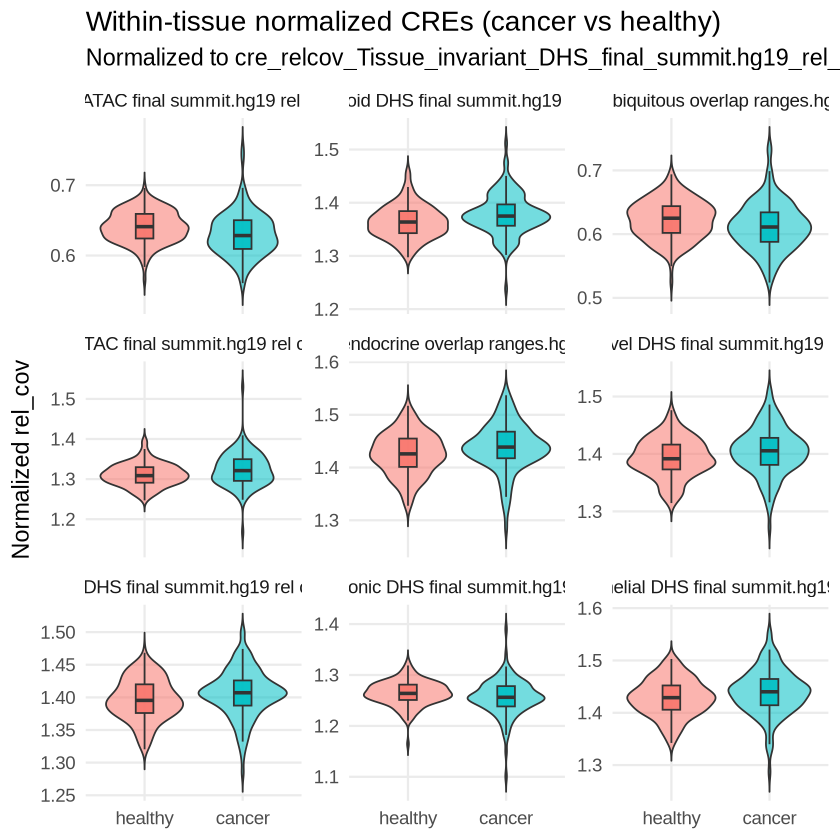

In [117]:
#!/usr/bin/env Rscript
# ================================================================
# Within-tissue normalization + ranked differences (cancer vs healthy)
#   - Normalizes each CRE per sample by tissue-invariant/Ubiquitous
#   - Computes Wilcoxon, Cliff's delta, AUROC
#   - Outputs a ranked table
# ================================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(purrr)
  library(ggplot2)
})

stopifnot(exists("lucas_df_final"))

# -----------------------------
# Settings
# -----------------------------
exclude_pat   <- "Placenta|trophoblast|fetal"
metric_suffix <- "_rel_cov_density$"   # change to "_rel_cov_density$" if you prefer densities
invariant_pat <- paste0(
  "^cre_relcov_(", 
  "Tissue_invariant.*", 
  "|Ubiquitous.*", 
  ")", 
  metric_suffix
)
eps <- 1e-6

# -----------------------------
# Identify invariant anchor
# -----------------------------
inv_candidates <- grep(invariant_pat, names(lucas_df_final), value = TRUE)
if (length(inv_candidates) == 0) {
  stop("No invariant anchor found matching: ", invariant_pat)
} else if (length(inv_candidates) > 1) {
  message("Multiple invariant candidates found; using the first:\n  ",
          paste(inv_candidates, collapse = "\n  "))
}
inv_col <- inv_candidates[1]
message("Invariant anchor: ", inv_col)

# -----------------------------
# Collect CRE columns to normalize
# -----------------------------
all_cre_cols <- grep(paste0("^cre_relcov_.*", metric_suffix), names(lucas_df_final), value = TRUE)
drop_cols    <- grep(exclude_pat, all_cre_cols, value = TRUE, ignore.case = TRUE)
cre_cols     <- setdiff(all_cre_cols, c(inv_col, drop_cols))

message("CRE columns kept: ", length(cre_cols),
        " | Excluded (Placenta/trophoblast/fetal): ", length(drop_cols))

stopifnot(length(cre_cols) > 0)

# -----------------------------
# Minimal helpers
# -----------------------------
# Cliff's delta without effsize dependency
cliffs_delta_simple <- function(x, y) {
  # returns estimate in [-1, 1]; positive -> x > y
  x <- x[is.finite(x)]; y <- y[is.finite(y)]
  if (length(x) < 1 || length(y) < 1) return(NA_real_)
  M <- outer(x, y, FUN = "-")
  (sum(M > 0) - sum(M < 0)) / (length(x) * length(y))
}

# AUROC (healthy=0, cancer=1) via rank-sum relationship
auc_from_ranks <- function(values, labels) {
  # labels must be factor with levels c("healthy","cancer")
  if (!all(levels(labels) %in% c("healthy","cancer"))) return(NA_real_)
  ix_c <- which(labels == "cancer")
  ix_h <- which(labels == "healthy")
  if (length(ix_c) < 1 || length(ix_h) < 1) return(NA_real_)
  r <- rank(values, ties.method = "average")
  U <- sum(r[ix_c]) - length(ix_c) * (length(ix_c) + 1) / 2
  U / (length(ix_c) * length(ix_h))
}

# -----------------------------
# Normalize per sample
# value_norm = CRE / invariant   (ratio; >1 enriched vs invariant)
# -----------------------------
df_norm <- lucas_df_final %>%
  dplyr::select(Patient, id, type, everything()) %>%
  dplyr::mutate(type = factor(type, levels = c("healthy", "cancer"))) %>%
  dplyr::mutate(`__inv__` = .data[[inv_col]]) %>%
  dplyr::mutate(
    dplyr::across(
      dplyr::all_of(cre_cols),
      ~ (.x + eps) / (`__inv__` + eps),
      .names = "{.col}__norm"
    )
  )

norm_cols <- paste0(cre_cols, "__norm")

long_norm <- df_norm %>%
  dplyr::select(Patient, id, type, dplyr::all_of(norm_cols)) %>%
  tidyr::pivot_longer(
    cols = dplyr::all_of(norm_cols),
    names_to = "CRE_raw",
    values_to = "value_norm"
  ) %>%
  dplyr::mutate(
    CRE_orig = stringr::str_remove(CRE_raw, "__norm$"),
    CRE = CRE_orig %>%
      stringr::str_remove("^cre_relcov_") %>%
      stringr::str_remove("_filtered_final_summit\\.hg19_rel_cov_profile$") %>%
      stringr::str_remove("_overlap_Jaccard25_13pct\\.hg19_nonredundant\\.hg19_rel_cov_profile$") %>%
      stringr::str_replace_all("_", " ")
  ) %>%
  dplyr::filter(!is.na(value_norm))

# -----------------------------
# Per-CRE stats on normalized values
# -----------------------------
stats_tbl <- long_norm %>%
  dplyr::group_by(CRE) %>%
  dplyr::summarise(
    n_cancer   = sum(type == "cancer"),
    n_healthy  = sum(type == "healthy"),
    median_cancer  = median(value_norm[type == "cancer"],  na.rm = TRUE),
    median_healthy = median(value_norm[type == "healthy"], na.rm = TRUE),
    diff_median    = median_cancer - median_healthy,
    p_wilcox = tryCatch(
      wilcox.test(value_norm ~ type)$p.value,
      error = function(e) NA_real_
    ),
    cliffs_delta = cliffs_delta_simple(
      value_norm[type == "cancer"],
      value_norm[type == "healthy"]
    ),
    auc = auc_from_ranks(
      values = value_norm,
      labels = type
    ),
    .groups = "drop"
  ) %>%
  dplyr::mutate(
    fdr = p.adjust(p_wilcox, method = "BH"),
    pct_change = 100 * (median_cancer / (median_healthy + eps) - 1)
  )

# -----------------------------
# Rank & print
# (Primary: |Cliff's delta| then FDR; switch to |diff_median| if preferred)
# -----------------------------
ranked <- stats_tbl %>%
  dplyr::arrange(dplyr::desc(abs(cliffs_delta)), fdr)

# Display top rows
print(
  ranked %>%
    dplyr::select(CRE, n_cancer, n_healthy,
                  median_cancer, median_healthy, diff_median, pct_change,
                  cliffs_delta, auc, p_wilcox, fdr) %>%
    dplyr::slice(1:25)
)

# -----------------------------
# (Optional) Save table
# -----------------------------
# readr::write_csv(ranked, "cre_within_tissue_normalized_stats.csv")

# -----------------------------
# (Optional) Quick visualization
# -----------------------------
top_k <- 9
top_cre <- ranked %>% dplyr::slice_max(order_by = abs(cliffs_delta), n = top_k) %>% dplyr::pull(CRE)

long_norm %>%
  dplyr::filter(CRE %in% top_cre) %>%
  dplyr::mutate(CRE = factor(CRE, levels = top_cre)) %>%
  ggplot(aes(x = type, y = value_norm, fill = type)) +
  geom_violin(trim = FALSE, alpha = 0.55) +
  geom_boxplot(width = 0.18, outlier.shape = NA, alpha = 0.9) +
  facet_wrap(~ CRE, scales = "free_y") +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none", panel.grid.minor = element_blank()) +
  labs(
    title = "Within-tissue normalized CREs (cancer vs healthy)",
    subtitle = paste0("Normalized to ", inv_col, " per sample; value = CRE / invariant"),
    x = NULL, y = "Normalized rel_cov"
  )


CRE columns kept: 46 | Excluded (Placenta/trophoblast/fetal): 5



# A tibble: 25 × 11
   CRE    n_cancer n_healthy median_cancer median_healthy diff_median pct_change
   <chr>     <int>     <int>         <dbl>          <dbl>       <dbl>      <dbl>
 1 Neuro…      127       157          1.07           1.09    -0.0206      -1.88 
 2 GI Ep…      127       157          1.06           1.08    -0.0156      -1.45 
 3 Pulm …      127       157          1.09           1.10    -0.0151      -1.37 
 4 Skin …      127       157          1.10           1.11    -0.0150      -1.35 
 5 Cance…      127       157          1.12           1.13    -0.0103      -0.913
 6 Strom…      127       157          1.12           1.14    -0.0104      -0.917
 7 Gastr…      127       157          1.10           1.11    -0.00800     -0.719
 8 Pancr…      127       157          1.03           1.04    -0.00993     -0.954
 9 Cance…      127       157          1.11           1.13    -0.0187      -1.66 
10 Adult…      127       157          1.07           1.09    -0.0116      -1.06 
# ℹ 15 m

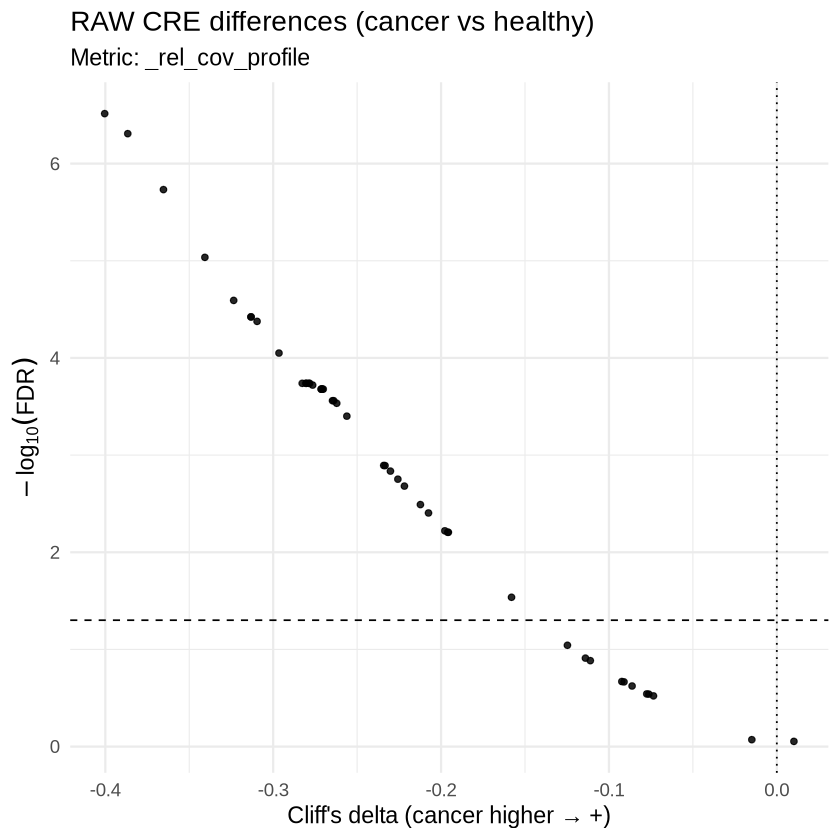

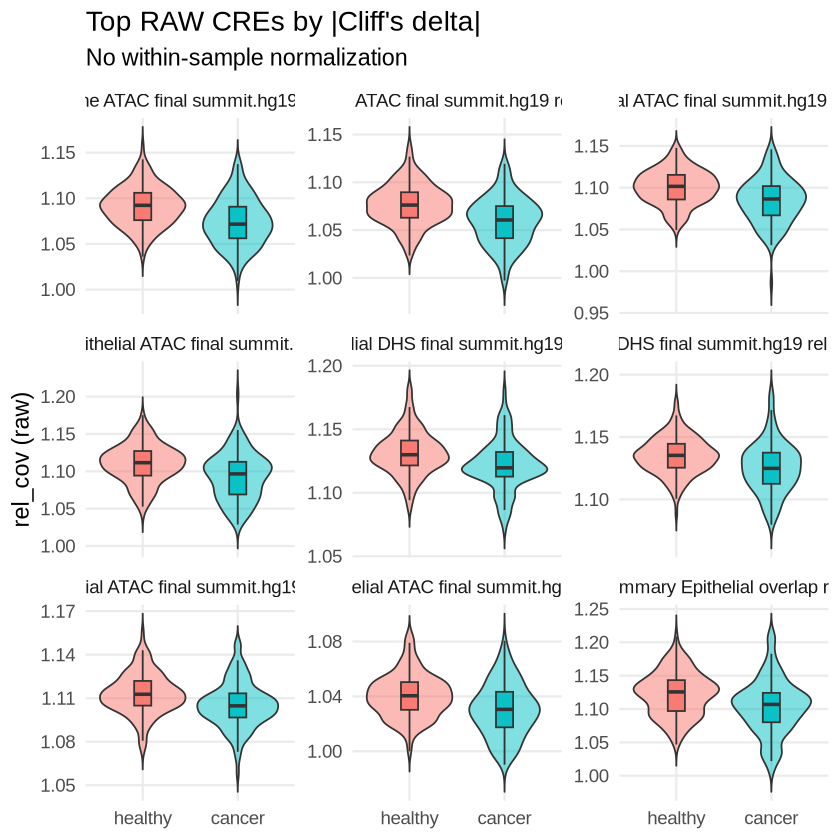

In [118]:
#!/usr/bin/env Rscript
# ================================================================
# Cancer vs Healthy differences on RAW CRE values (no normalization)
#   - Choose profile or density via metric_suffix
#   - Excludes Placenta/trophoblast/fetal
#   - Ranks by |Cliff's delta| (change to |diff_median| if preferred)
# ================================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(ggplot2)
})

stopifnot(exists("lucas_df_final"))

# -----------------------------
# Settings
# -----------------------------
exclude_pat   <- "Placenta|trophoblast|fetal"
metric_suffix <- "_rel_cov_profile$"   # or "_rel_cov_density$"

# -----------------------------
# Identify CRE columns (raw)
# -----------------------------
all_cre_cols <- grep(paste0("^cre_relcov_.*", metric_suffix), names(lucas_df_final), value = TRUE)
drop_cols    <- grep(exclude_pat, all_cre_cols, value = TRUE, ignore.case = TRUE)
cre_cols     <- setdiff(all_cre_cols, drop_cols)

message("CRE columns kept: ", length(cre_cols),
        " | Excluded (Placenta/trophoblast/fetal): ", length(drop_cols))
stopifnot(length(cre_cols) > 0)

# -----------------------------
# Minimal helpers (no extra pkgs)
# -----------------------------
cliffs_delta_simple <- function(x, y) {
  x <- x[is.finite(x)]; y <- y[is.finite(y)]
  if (length(x) < 1 || length(y) < 1) return(NA_real_)
  M <- outer(x, y, FUN = "-")
  (sum(M > 0) - sum(M < 0)) / (length(x) * length(y))
}

auc_from_ranks <- function(values, labels) {
  labels <- factor(labels, levels = c("healthy","cancer"))
  if (any(is.na(labels))) return(NA_real_)
  iC <- which(labels == "cancer"); iH <- which(labels == "healthy")
  if (length(iC) < 1 || length(iH) < 1) return(NA_real_)
  r <- rank(values, ties.method = "average")
  U <- sum(r[iC]) - length(iC) * (length(iC) + 1) / 2
  U / (length(iC) * length(iH))
}

# -----------------------------
# Long format (raw values)
# -----------------------------
long_raw <- lucas_df_final %>%
  dplyr::select(Patient, id, type, dplyr::all_of(cre_cols)) %>%
  tidyr::pivot_longer(
    cols = dplyr::all_of(cre_cols),
    names_to = "CRE_raw",
    values_to = "value"
  ) %>%
  dplyr::filter(!is.na(value), type %in% c("healthy","cancer")) %>%
  dplyr::mutate(
    type = factor(type, levels = c("healthy","cancer")),
    CRE = CRE_raw %>%
      stringr::str_remove("^cre_relcov_") %>%
      stringr::str_remove("_filtered_final_summit\\.hg19_rel_cov_profile$") %>%
      stringr::str_remove("_overlap_Jaccard25_13pct\\.hg19_nonredundant\\.hg19_rel_cov_profile$") %>%
      stringr::str_replace_all("_", " ")
  )

# -----------------------------
# Per-CRE stats on raw values
# -----------------------------
stats_tbl <- long_raw %>%
  dplyr::group_by(CRE) %>%
  dplyr::summarise(
    n_cancer   = sum(type == "cancer"),
    n_healthy  = sum(type == "healthy"),
    median_cancer  = median(value[type == "cancer"],  na.rm = TRUE),
    median_healthy = median(value[type == "healthy"], na.rm = TRUE),
    diff_median    = median_cancer - median_healthy,
    p_wilcox = tryCatch(wilcox.test(value ~ type)$p.value, error = function(e) NA_real_),
    cliffs_delta = cliffs_delta_simple(
      value[type == "cancer"],
      value[type == "healthy"]
    ),
    auc = auc_from_ranks(values = value, labels = type),
    .groups = "drop"
  ) %>%
  dplyr::mutate(
    fdr = p.adjust(p_wilcox, method = "BH"),
    pct_change = 100 * (median_cancer / median_healthy - 1)
  )

# -----------------------------
# Rank & print
# -----------------------------
ranked <- stats_tbl %>%
  dplyr::arrange(dplyr::desc(abs(cliffs_delta)), fdr)

print(
  ranked %>%
    dplyr::select(CRE, n_cancer, n_healthy,
                  median_cancer, median_healthy, diff_median, pct_change,
                  cliffs_delta, auc, p_wilcox, fdr) %>%
    dplyr::slice(1:25)
)

# -----------------------------
# Optional: quick visuals
# -----------------------------
# Volcano (effect vs significance)
ggplot(ranked, aes(x = cliffs_delta, y = -log10(fdr))) +
  geom_hline(yintercept = -log10(0.05), linetype = 2) +
  geom_vline(xintercept = 0, linetype = 3) +
  geom_point(alpha = 0.85) +
  theme_minimal(base_size = 14) +
  labs(
    title = "RAW CRE differences (cancer vs healthy)",
    subtitle = paste0("Metric: ", sub("\\$", "", metric_suffix)),
    x = "Cliff's delta (cancer higher → +)",
    y = expression(-log[10]("FDR"))
  )

# Distributions for top K by |delta|
top_k <- 9
top_cre <- ranked %>% dplyr::slice_max(order_by = abs(cliffs_delta), n = top_k) %>% dplyr::pull(CRE)

long_raw %>%
  dplyr::filter(CRE %in% top_cre) %>%
  dplyr::mutate(CRE = factor(CRE, levels = top_cre)) %>%
  ggplot(aes(x = type, y = value, fill = type)) +
  geom_violin(trim = FALSE, alpha = 0.5) +
  geom_boxplot(width = 0.18, outlier.shape = NA, alpha = 0.9) +
  facet_wrap(~ CRE, scales = "free_y") +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none", panel.grid.minor = element_blank()) +
  labs(
    title = "Top RAW CREs by |Cliff's delta|",
    subtitle = "No within-sample normalization",
    x = NULL, y = "rel_cov (raw)"
  )


In [124]:
# --- Minimal deps ---
library(dplyr)
library(tidyr)
library(stringr)

# --- Settings (edit top_n if you like) ---
top_n <- 30

# 1) Pick ATAC rel_cov_profile columns
cre_cols <- grep("^cre_relcov_.*ATAC.*_rel_cov_profile$", names(lucas_df_final),
                 value = TRUE, ignore.case = TRUE)
stopifnot(length(cre_cols) > 0)

# 2) Rank-normalize within each sample (robust to scaling)
ranked_df <- lucas_df_final %>%
  dplyr::select(id, type, dplyr::all_of(cre_cols)) %>%
  dplyr::mutate(
    dplyr::across(
      dplyr::all_of(cre_cols),
      ~ rank(-., ties.method = "average"),   # higher value → higher rank
      .names = "{.col}_rank"
    ),
    type = factor(type, levels = c("healthy","cancer"))
  )

# 3) Long format
long_rank <- ranked_df %>%
  tidyr::pivot_longer(
    cols = dplyr::ends_with("_rank"),
    names_to = "CRE_raw",
    values_to = "rank_value"
  ) %>%
  dplyr::mutate(CRE = stringr::str_remove(CRE_raw, "_rank$"))

# 4) Simple per-CRE Wilcoxon on ranks + medians
simple_tbl <- long_rank %>%
  dplyr::group_by(CRE) %>%
  dplyr::summarise(
    n_cancer   = sum(type == "cancer"),
    n_healthy  = sum(type == "healthy"),
    med_rank_cancer  = median(rank_value[type == "cancer"],  na.rm = TRUE),
    med_rank_healthy = median(rank_value[type == "healthy"], na.rm = TRUE),
    diff_med_rank    = med_rank_cancer - med_rank_healthy,          # + = higher in cancer
    p_wilcox = tryCatch(wilcox.test(rank_value ~ type)$p.value, error = function(e) NA_real_),
    .groups = "drop"
  ) %>%
  dplyr::mutate(
    fdr = p.adjust(p_wilcox, method = "BH"),
    direction = ifelse(diff_med_rank > 0, "Higher in cancer", "Lower in cancer"),
    CRE_clean = CRE %>%
      stringr::str_remove("^cre_relcov_") %>%
      stringr::str_remove("_filtered_final_summit\\.hg19_rel_cov_profile$") %>%
      stringr::str_replace_all("_", " ")
  ) %>%
  dplyr::arrange(fdr, dplyr::desc(abs(diff_med_rank))) %>%
  dplyr::select(
    CRE = CRE_clean,
    n_cancer, n_healthy,
    med_rank_cancer, med_rank_healthy,
    diff_med_rank, p_wilcox, fdr, direction
  )

# 5) Show top N most differential ATAC CREs
atac_cre_top <- simple_tbl %>% dplyr::slice(1:top_n)
print(atac_cre_top, n = top_n)


# A tibble: 20 × 9
   CRE         n_cancer n_healthy med_rank_cancer med_rank_healthy diff_med_rank
   <chr>          <int>     <int>           <dbl>            <dbl>         <dbl>
 1 Neuroendoc…      129       158             193             111           82  
 2 GI Epithel…      129       158             190             110.          80.5
 3 Pulm Epith…      129       158             184             112           72  
 4 Skin Mamma…      129       158             182             114           68  
 5 Gastric Ep…      129       158             186             114.          72.5
 6 Pancreatic…      129       158             182             116.          65.5
 7 Placental …      129       158             175             123           52  
 8 Adult Stro…      129       158             179             118.          60.5
 9 Adrenal Co…      129       158             183             128.          55.5
10 Follicular…      129       158             174             118.          55.5
11 Fetal 

In [126]:
#!/usr/bin/env Rscript
# ================================================================
# ATAC CREs: Top-5 Greatest Differences & Top-5 Most Invariant
#   Strategies:
#     A) Rank-based Δ median rank (within-sample ranks)
#     B) Raw values Δ median rel_cov_profile
#     C) Ratio-to-invariant Δ median log2 ratio
# ================================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(readr)
})

stopifnot(exists("lucas_df_final"))

# -----------------------------
# Settings
# -----------------------------
exclude_placental <- TRUE   # set FALSE to keep placental/fetal
top_n <- 5
eps <- 1e-6

# -----------------------------
# Identify ATAC rel_cov_profile columns
# -----------------------------
cre_cols <- grep("^cre_relcov_.*ATAC.*_rel_cov_profile$", names(lucas_df_final),
                 value = TRUE, ignore.case = TRUE)
if (exclude_placental) {
  drop <- grep("Placenta|trophoblast|fetal", cre_cols, value = TRUE, ignore.case = TRUE)
  cre_cols <- setdiff(cre_cols, drop)
}
stopifnot(length(cre_cols) > 0)

# Helper to pretty-label CRE names
pretty_label <- function(x) {
  x %>%
    stringr::str_remove("^cre_relcov_") %>%
    stringr::str_remove("_filtered_final_summit\\.hg19_rel_cov_profile$") %>%
    stringr::str_remove("_overlap_Jaccard25_13pct\\.hg19_nonredundant\\.hg19_rel_cov_profile$") %>%
    stringr::str_replace_all("_", " ")
}

# -----------------------------
# A) Rank-based (within-sample)
# -----------------------------
ranked_df <- lucas_df_final %>%
  dplyr::select(id, type, dplyr::all_of(cre_cols)) %>%
  dplyr::mutate(
    dplyr::across(dplyr::all_of(cre_cols), ~ rank(-., ties.method = "average"),
                  .names = "{.col}_rank"),
    type = factor(type, levels = c("healthy","cancer"))
  )

long_rank <- ranked_df %>%
  tidyr::pivot_longer(cols = dplyr::ends_with("_rank"),
                      names_to = "CRE_raw", values_to = "rank_value") %>%
  dplyr::mutate(CRE = stringr::str_remove(CRE_raw, "_rank$"))

rank_tbl <- long_rank %>%
  dplyr::group_by(CRE) %>%
  dplyr::summarise(
    n_cancer   = sum(type == "cancer"),
    n_healthy  = sum(type == "healthy"),
    med_rank_cancer  = median(rank_value[type == "cancer"],  na.rm = TRUE),
    med_rank_healthy = median(rank_value[type == "healthy"], na.rm = TRUE),
    diff_med_rank    = med_rank_cancer - med_rank_healthy,        # + = ranks higher (less dominant) in cancer
    iqr_all = IQR(rank_value, na.rm = TRUE),                       # stability helper
    p_wilcox = tryCatch(wilcox.test(rank_value ~ type)$p.value, error = function(e) NA_real_),
    .groups = "drop"
  ) %>%
  dplyr::mutate(
    fdr = p.adjust(p_wilcox, "BH"),
    Strategy = "A_Rank",
    CRE_label = pretty_label(CRE)
  )

# -----------------------------
# B) Raw values
# -----------------------------
long_raw <- lucas_df_final %>%
  dplyr::select(id, type, dplyr::all_of(cre_cols)) %>%
  tidyr::pivot_longer(cols = dplyr::all_of(cre_cols),
                      names_to = "CRE", values_to = "value") %>%
  dplyr::mutate(type = factor(type, levels = c("healthy","cancer")))

raw_tbl <- long_raw %>%
  dplyr::group_by(CRE) %>%
  dplyr::summarise(
    n_cancer   = sum(type == "cancer"),
    n_healthy  = sum(type == "healthy"),
    median_cancer  = median(value[type == "cancer"],  na.rm = TRUE),
    median_healthy = median(value[type == "healthy"], na.rm = TRUE),
    diff_median    = median_cancer - median_healthy,              # + = higher in cancer
    iqr_all = IQR(value, na.rm = TRUE),                           # stability helper
    p_wilcox = tryCatch(wilcox.test(value ~ type)$p.value, error = function(e) NA_real_),
    .groups = "drop"
  ) %>%
  dplyr::mutate(
    fdr = p.adjust(p_wilcox, "BH"),
    Strategy = "B_Raw",
    CRE_label = pretty_label(CRE)
  )

# -----------------------------
# C) Ratio-to-invariant (profile → profile)
# -----------------------------
inv_col <- grep("^cre_relcov_(Tissue_invariant|Ubiquitous).*_rel_cov_profile$",
                names(lucas_df_final), value = TRUE)
stopifnot(length(inv_col) >= 1)
inv_col <- inv_col[1]  # pick the first anchor

norm_df <- lucas_df_final %>%
  dplyr::select(id, type, dplyr::all_of(c(inv_col, cre_cols))) %>%
  dplyr::mutate(inv = .data[[inv_col]]) %>%
  dplyr::mutate(
    dplyr::across(dplyr::all_of(cre_cols),
                  ~ log2((.x + eps) / (inv + eps)),               # log2 ratio
                  .names = "{.col}__log2ratio"),
    type = factor(type, levels = c("healthy","cancer"))
  )

norm_cols <- paste0(cre_cols, "__log2ratio")

long_norm <- norm_df %>%
  dplyr::select(id, type, dplyr::all_of(norm_cols)) %>%
  tidyr::pivot_longer(cols = dplyr::all_of(norm_cols),
                      names_to = "CRE_raw", values_to = "log2ratio") %>%
  dplyr::mutate(CRE = stringr::str_remove(CRE_raw, "__log2ratio$"))

norm_tbl <- long_norm %>%
  dplyr::group_by(CRE) %>%
  dplyr::summarise(
    n_cancer   = sum(type == "cancer"),
    n_healthy  = sum(type == "healthy"),
    median_log2_cancer  = median(log2ratio[type == "cancer"],  na.rm = TRUE),
    median_log2_healthy = median(log2ratio[type == "healthy"], na.rm = TRUE),
    diff_median_log2    = median_log2_cancer - median_log2_healthy,  # + = higher ratio in cancer
    iqr_all = IQR(log2ratio, na.rm = TRUE),                           # stability helper
    p_wilcox = tryCatch(wilcox.test(log2ratio ~ type)$p.value, error = function(e) NA_real_),
    .groups = "drop"
  ) %>%
  dplyr::mutate(
    fdr = p.adjust(p_wilcox, "BH"),
    Strategy = "C_RatioInv",
    CRE_label = pretty_label(CRE)
  )

# -----------------------------
# Assemble "Top-5 Greatest Differences" per strategy
# -----------------------------
top_diff_A <- rank_tbl %>%
  dplyr::arrange(dplyr::desc(abs(diff_med_rank)), fdr) %>%
  dplyr::transmute(
    Strategy, CRE_label, n_cancer, n_healthy,
    Effect = diff_med_rank,
    FDR = fdr
  ) %>% dplyr::slice(1:top_n)

top_diff_B <- raw_tbl %>%
  dplyr::arrange(dplyr::desc(abs(diff_median)), fdr) %>%
  dplyr::transmute(
    Strategy, CRE_label, n_cancer, n_healthy,
    Effect = diff_median,
    FDR = fdr
  ) %>% dplyr::slice(1:top_n)

top_diff_C <- norm_tbl %>%
  dplyr::arrange(dplyr::desc(abs(diff_median_log2)), fdr) %>%
  dplyr::transmute(
    Strategy, CRE_label, n_cancer, n_healthy,
    Effect = diff_median_log2,   # log2 scale
    FDR = fdr
  ) %>% dplyr::slice(1:top_n)

top5_differences <- dplyr::bind_rows(top_diff_A, top_diff_B, top_diff_C)

# -----------------------------
# Assemble "Top-5 Most Invariant" per strategy
#   — smallest between-group difference AND low overall variability
# -----------------------------
inv_A <- rank_tbl %>%
  dplyr::arrange(abs(diff_med_rank), iqr_all, fdr) %>%
  dplyr::transmute(
    Strategy, CRE_label, n_cancer, n_healthy,
    Effect = diff_med_rank,
    Stability_IQR = iqr_all,
    FDR = fdr
  ) %>% dplyr::slice(1:top_n)

inv_B <- raw_tbl %>%
  dplyr::arrange(abs(diff_median), iqr_all, fdr) %>%
  dplyr::transmute(
    Strategy, CRE_label, n_cancer, n_healthy,
    Effect = diff_median,
    Stability_IQR = iqr_all,
    FDR = fdr
  ) %>% dplyr::slice(1:top_n)

inv_C <- norm_tbl %>%
  dplyr::arrange(abs(diff_median_log2), iqr_all, fdr) %>%
  dplyr::transmute(
    Strategy, CRE_label, n_cancer, n_healthy,
    Effect = diff_median_log2,   # log2 scale
    Stability_IQR = iqr_all,
    FDR = fdr
  ) %>% dplyr::slice(1:top_n)

top5_invariant <- dplyr::bind_rows(inv_A, inv_B, inv_C)

# -----------------------------
# Final outputs
# -----------------------------
cat("\n===== TOP-5 GREATEST DIFFERENCES (per strategy) =====\n")
print(top5_differences, n = nrow(top5_differences))

cat("\n===== TOP-5 MOST INVARIANT (per strategy) =====\n")
print(top5_invariant, n = nrow(top5_invariant))


cat("\nFiles written:\n")
cat(" - ATAC_top5_greatest_differences_by_strategy.csv\n")
cat(" - ATAC_top5_most_invariant_by_strategy.csv\n\n")



===== TOP-5 GREATEST DIFFERENCES (per strategy) =====
# A tibble: 15 × 6
   Strategy   CRE_label                      n_cancer n_healthy   Effect     FDR
   <chr>      <chr>                             <int>     <int>    <dbl>   <dbl>
 1 A_Rank     Neuroendocrine ATAC final sum…      129       158 82       9.32e-8
 2 A_Rank     GI Epithelial ATAC final summ…      129       158 80.5     1.48e-7
 3 A_Rank     Gastric Epithelial ATAC final…      129       158 72.5     1.54e-5
 4 A_Rank     Pulm Epithelial ATAC final su…      129       158 72       5.50e-7
 5 A_Rank     Skin Mammary Epithelial ATAC …      129       158 68       2.71e-6
 6 B_Raw      Neuroendocrine ATAC final sum…      129       158 -0.0206  1.20e-7
 7 B_Raw      Cardiomyocyte ATAC final summ…      129       158 -0.0172  1.58e-4
 8 B_Raw      GI Epithelial ATAC final summ…      129       158 -0.0156  1.92e-7
 9 B_Raw      Pulm Epithelial ATAC final su…      129       158 -0.0151  7.24e-7
10 B_Raw      Skin Mammary Epitheli

In [129]:
#!/usr/bin/env Rscript
# ================================================================
# ATAC cfDNA: Top 5 Most Differential Cell Types (Cancer vs Healthy)
# ================================================================
# Analyses performed:
#   A) Rank-based Δ median rank (within-sample)
#   B) Raw Δ median (rel_cov_profile)
#   C) Ratio-to-invariant (log2 ratio per sample)
#   D) AUC (ROC discrimination)
#   E) Healthy-referenced z-score
# ================================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(readr)
})

stopifnot(exists("lucas_df_final"))

# -----------------------------
# Settings
# -----------------------------
exclude_placental <- TRUE   # set FALSE if you want placental/fetal CREs
top_n <- 5
eps <- 1e-6

# -----------------------------
# Identify ATAC *_rel_cov_profile columns
# -----------------------------
cre_cols <- grep("^cre_relcov_.*ATAC.*_rel_cov_profile$", names(lucas_df_final),
                 value = TRUE, ignore.case = TRUE)
if (exclude_placental) {
  drop <- grep("Placenta|trophoblast|fetal", cre_cols, value = TRUE, ignore.case = TRUE)
  cre_cols <- setdiff(cre_cols, drop)
}
stopifnot(length(cre_cols) > 0)

df <- lucas_df_final %>%
  dplyr::select(id, type, dplyr::all_of(cre_cols)) %>%
  dplyr::filter(type %in% c("healthy","cancer")) %>%
  dplyr::mutate(type = factor(type, levels = c("healthy","cancer")))

# -----------------------------
# Helper functions
# -----------------------------
pretty_label <- function(x) {
  x %>%
    stringr::str_remove("^cre_relcov_") %>%
    stringr::str_remove("_filtered_final_summit\\.hg19_rel_cov_profile$") %>%
    stringr::str_remove("_overlap_Jaccard25_13pct\\.hg19_nonredundant\\.hg19_rel_cov_profile$") %>%
    stringr::str_replace_all("_", " ")
}

auc_from_ranks <- function(values, labels) {
  labels <- factor(labels, levels = c("healthy","cancer"))
  iC <- which(labels=="cancer"); iH <- which(labels=="healthy")
  if (!length(iC) || !length(iH)) return(NA_real_)
  r <- rank(values, ties.method = "average")
  U <- sum(r[iC]) - length(iC)*(length(iC)+1)/2
  U / (length(iC)*length(iH))
}

# Simplified topK helper (fixed version)
topK <- function(tbl, k = 5, effect_col, fdr_col = NULL) {
  if (!effect_col %in% names(tbl))
    stop("Column ", effect_col, " not found.")
  tbl <- tbl %>%
    dplyr::mutate(abs_effect = abs(.data[[effect_col]]))
  if (!is.null(fdr_col) && fdr_col %in% names(tbl)) {
    tbl <- tbl %>% dplyr::arrange(dplyr::desc(abs_effect), .data[[fdr_col]])
  } else {
    tbl <- tbl %>% dplyr::arrange(dplyr::desc(abs_effect))
  }
  tbl %>% dplyr::slice(1:k) %>% dplyr::select(-abs_effect)
}

# ================================================================
# A) Rank-based Δ median rank
# ================================================================
ranked_df <- df %>%
  dplyr::mutate(dplyr::across(dplyr::all_of(cre_cols),
                              ~ rank(-., ties.method = "average"),
                              .names = "{.col}_rank"))
long_rank <- ranked_df %>%
  tidyr::pivot_longer(cols = dplyr::ends_with("_rank"),
                      names_to = "CRE_raw", values_to = "rank_value") %>%
  dplyr::mutate(CRE = stringr::str_remove(CRE_raw, "_rank$"))

res_rank <- long_rank %>%
  dplyr::group_by(CRE) %>%
  dplyr::summarise(
    n_cancer = sum(type=="cancer"),
    n_healthy = sum(type=="healthy"),
    med_rank_cancer = median(rank_value[type=="cancer"], na.rm = TRUE),
    med_rank_healthy = median(rank_value[type=="healthy"], na.rm = TRUE),
    diff_med_rank = med_rank_cancer - med_rank_healthy,
    p_wilcox = tryCatch(wilcox.test(rank_value ~ type)$p.value, error = function(e) NA_real_),
    .groups = "drop"
  ) %>%
  dplyr::mutate(
    fdr = p.adjust(p_wilcox, "BH"),
    Analysis = "A_RankΔ",
    CRE_label = pretty_label(CRE),
    Effect = diff_med_rank
  )
top_rank <- topK(res_rank, top_n, "Effect", "fdr")

# ================================================================
# B) Raw Δ median (rel_cov_profile)
# ================================================================
long_raw <- df %>%
  tidyr::pivot_longer(cols = dplyr::all_of(cre_cols),
                      names_to = "CRE", values_to = "value")
res_raw <- long_raw %>%
  dplyr::group_by(CRE) %>%
  dplyr::summarise(
    n_cancer = sum(type=="cancer"),
    n_healthy = sum(type=="healthy"),
    med_cancer = median(value[type=="cancer"], na.rm = TRUE),
    med_healthy = median(value[type=="healthy"], na.rm = TRUE),
    diff_median = med_cancer - med_healthy,
    p_wilcox = tryCatch(wilcox.test(value ~ type)$p.value, error = function(e) NA_real_),
    .groups = "drop"
  ) %>%
  dplyr::mutate(
    fdr = p.adjust(p_wilcox, "BH"),
    Analysis = "B_RawΔ",
    CRE_label = pretty_label(CRE),
    Effect = diff_median
  )
top_raw <- topK(res_raw, top_n, "Effect", "fdr")

# ================================================================
# C) Ratio-to-invariant (log2 ratio)
# ================================================================
inv_col <- grep("^cre_relcov_(Tissue_invariant|Ubiquitous).*_rel_cov_profile$",
                names(lucas_df_final), value = TRUE)
stopifnot(length(inv_col) >= 1)
inv_col <- inv_col[1]

norm_df <- df %>%
  dplyr::mutate(inv = lucas_df_final[[inv_col]]) %>%
  dplyr::mutate(
    dplyr::across(dplyr::all_of(cre_cols),
                  ~ log2((.x + eps)/(inv + eps)), .names = "{.col}__log2")
  )
long_norm <- norm_df %>%
  tidyr::pivot_longer(cols = dplyr::ends_with("__log2"),
                      names_to = "CRE_raw", values_to = "log2ratio") %>%
  dplyr::mutate(CRE = stringr::str_remove(CRE_raw, "__log2$"))
res_ratio <- long_norm %>%
  dplyr::group_by(CRE) %>%
  dplyr::summarise(
    n_cancer = sum(type=="cancer"),
    n_healthy = sum(type=="healthy"),
    med_cancer = median(log2ratio[type=="cancer"], na.rm = TRUE),
    med_healthy = median(log2ratio[type=="healthy"], na.rm = TRUE),
    diff_median_log2 = med_cancer - med_healthy,
    p_wilcox = tryCatch(wilcox.test(log2ratio ~ type)$p.value, error = function(e) NA_real_),
    .groups = "drop"
  ) %>%
  dplyr::mutate(
    fdr = p.adjust(p_wilcox, "BH"),
    Analysis = "C_RatioInvΔ(log2)",
    CRE_label = pretty_label(CRE),
    Effect = diff_median_log2
  )
top_ratio <- topK(res_ratio, top_n, "Effect", "fdr")

# ================================================================
# D) AUC (ROC discrimination)
# ================================================================
res_auc <- long_raw %>%
  dplyr::group_by(CRE) %>%
  dplyr::summarise(
    n_cancer = sum(type=="cancer"),
    n_healthy = sum(type=="healthy"),
    auc = auc_from_ranks(value, type),
    p_wilcox = tryCatch(wilcox.test(value ~ type)$p.value, error = function(e) NA_real_),
    .groups = "drop"
  ) %>%
  dplyr::mutate(
    fdr = p.adjust(p_wilcox, "BH"),
    Analysis = "D_AUC",
    CRE_label = pretty_label(CRE),
    Effect = auc - 0.5
  )
top_auc <- topK(res_auc, top_n, "Effect", "fdr")

# ================================================================
# E) Healthy-referenced z-score
# ================================================================
stats_healthy <- long_raw %>%
  dplyr::filter(type=="healthy") %>%
  dplyr::group_by(CRE) %>%
  dplyr::summarise(mu = mean(value, na.rm=TRUE),
                   sd = sd(value, na.rm=TRUE),
                   .groups="drop")
long_z <- long_raw %>%
  dplyr::left_join(stats_healthy, by="CRE") %>%
  dplyr::mutate(z = ifelse(is.finite(sd) & sd > 0, (value - mu)/sd, NA_real_))
res_z <- long_z %>%
  dplyr::group_by(CRE) %>%
  dplyr::summarise(
    n_cancer = sum(type=="cancer"),
    n_healthy = sum(type=="healthy"),
    med_z_cancer = median(z[type=="cancer"], na.rm = TRUE),
    med_z_healthy = median(z[type=="healthy"], na.rm = TRUE),
    diff_med_z = med_z_cancer - med_z_healthy,
    p_wilcox = tryCatch(wilcox.test(z ~ type)$p.value, error = function(e) NA_real_),
    .groups = "drop"
  ) %>%
  dplyr::mutate(
    fdr = p.adjust(p_wilcox, "BH"),
    Analysis = "E_HealthyZΔ",
    CRE_label = pretty_label(CRE),
    Effect = diff_med_z
  )
top_z <- topK(res_z, top_n, "Effect", "fdr")

# ================================================================
# Final combined output
# ================================================================
top5_all <- dplyr::bind_rows(top_rank, top_raw, top_ratio, top_auc, top_z)

cat("\n================ TOP 5 MOST DIFFERENTIAL ATAC CELL TYPES =================\n")
top5_all
# Optional: write to file
# readr::write_csv(top5_all, "ATAC_top5_differentials_across_5_analyses.csv")

cat("\n✓ Analyses complete.\n")



================ TOP 5 MOST DIFFERENTIAL ATAC CELL TYPES =================


CRE,n_cancer,n_healthy,med_rank_cancer,med_rank_healthy,diff_med_rank,p_wilcox,fdr,Analysis,CRE_label,Effect,med_cancer,med_healthy,diff_median,diff_median_log2,auc,med_z_cancer,med_z_healthy,diff_med_z
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
cre_relcov_Neuroendocrine_ATAC_final_summit.hg19_rel_cov_profile,129,158,193,111.0,82.0,5.176709e-09,9.318076e-08,A_RankΔ,Neuroendocrine ATAC final summit.hg19 rel cov profile,82.000000000,NA,NA,NA,NA,NA,NA,NA,NA
cre_relcov_GI_Epithelial_ATAC_final_summit.hg19_rel_cov_profile,129,158,190,109.5,80.5,1.646930e-08,1.482237e-07,A_RankΔ,GI Epithelial ATAC final summit.hg19 rel cov profile,80.500000000,NA,NA,NA,NA,NA,NA,NA,NA
cre_relcov_Gastric_Epithelial_ATAC_final_summit.hg19_rel_cov_profile,129,158,186,113.5,72.5,4.276394e-06,1.539502e-05,A_RankΔ,Gastric Epithelial ATAC final summit.hg19 rel cov profile,72.500000000,NA,NA,NA,NA,NA,NA,NA,NA
cre_relcov_Pulm_Epithelial_ATAC_final_summit.hg19_rel_cov_profile,129,158,184,112.0,72.0,9.172668e-08,5.503601e-07,A_RankΔ,Pulm Epithelial ATAC final summit.hg19 rel cov profile,72.000000000,NA,NA,NA,NA,NA,NA,NA,NA
cre_relcov_Skin_Mammary_Epithelial_ATAC_final_summit.hg19_rel_cov_profile,129,158,182,114.0,68.0,6.017104e-07,2.707697e-06,A_RankΔ,Skin Mammary Epithelial ATAC final summit.hg19 rel cov profile,68.000000000,NA,NA,NA,NA,NA,NA,NA,NA
cre_relcov_Neuroendocrine_ATAC_final_summit.hg19_rel_cov_profile,129,158,NA,NA,NA,6.647227e-09,1.196501e-07,B_RawΔ,Neuroendocrine ATAC final summit.hg19 rel cov profile,-0.020586291,1.0716515,1.0922378,-0.02058629,NA,NA,NA,NA,NA
cre_relcov_Cardiomyocyte_ATAC_final_summit.hg19_rel_cov_profile,129,158,NA,NA,NA,1.263517e-04,1.580187e-04,B_RawΔ,Cardiomyocyte ATAC final summit.hg19 rel cov profile,-0.017182875,1.0714559,1.0886388,-0.01718288,NA,NA,NA,NA,NA
cre_relcov_GI_Epithelial_ATAC_final_summit.hg19_rel_cov_profile,129,158,NA,NA,NA,2.137119e-08,1.923407e-07,B_RawΔ,GI Epithelial ATAC final summit.hg19 rel cov profile,-0.015593258,1.0605827,1.0761759,-0.01559326,NA,NA,NA,NA,NA
cre_relcov_Pulm_Epithelial_ATAC_final_summit.hg19_rel_cov_profile,129,158,NA,NA,NA,1.206910e-07,7.241461e-07,B_RawΔ,Pulm Epithelial ATAC final summit.hg19 rel cov profile,-0.015059759,1.0865542,1.1016139,-0.01505976,NA,NA,NA,NA,NA



✓ Analyses complete.


In [137]:
# --- Minimal deps ---
library(dplyr); library(tidyr); library(stringr); library(broom)

stopifnot(exists("lucas_df_final"))

# 0) pick ATAC *_rel_cov_profile CREs and the Ubiquitous anchor
cre_cols <- grep("^cre_relcov_.*ATAC.*_rel_cov_profile$", names(lucas_df_final),
                 value = TRUE, ignore.case = TRUE)
# optional: drop placenta/fetal
cre_cols <- setdiff(cre_cols, grep("Placenta|trophoblast|fetal", cre_cols, value = TRUE, ignore.case = TRUE))
stopifnot(length(cre_cols) > 0)

inv_col <- grep("^cre_relcov_(Tissue_invariant|Ubiquitous).*ATAC.*_rel_cov_profile$",
                names(lucas_df_final), value = TRUE, ignore.case = TRUE)
if (!length(inv_col)) inv_col <- grep("^cre_relcov_(Tissue_invariant|Ubiquitous).*_rel_cov_profile$",
                                      names(lucas_df_final), value = TRUE)
stopifnot(length(inv_col) >= 1); inv_col <- inv_col[1]
eps <- 1e-6

df <- lucas_df_final %>%
  dplyr::filter(type %in% c("healthy","cancer")) %>%
  dplyr::mutate(type = factor(type, levels = c("healthy","cancer")))

# 1) Ulz-style: Ubiquitous-normalized log2 accessibility
ulz_mat <- df %>%
  dplyr::select(id, type, ichor = dplyr::all_of("ichor"), inv = dplyr::all_of(inv_col), dplyr::all_of(cre_cols)) %>%
  dplyr::mutate(dplyr::across(dplyr::all_of(cre_cols), ~ log2((.x + eps) / (inv + eps)), .names = "{.col}__log2R"))

# gather
ulz_long <- ulz_mat %>%
  dplyr::select(id, type, ichor, dplyr::ends_with("__log2R")) %>%
  tidyr::pivot_longer(cols = dplyr::ends_with("__log2R"), names_to = "CRE_raw", values_to = "log2R") %>%
  dplyr::mutate(CRE = stringr::str_remove(CRE_raw, "__log2R$"))

# healthy μ, σ and Z
stats_h <- ulz_long %>%
  dplyr::filter(type == "healthy") %>%
  dplyr::group_by(CRE) %>%
  dplyr::summarise(mu = mean(log2R, na.rm = TRUE), sd = sd(log2R, na.rm = TRUE), .groups = "drop")

ulz_Z <- ulz_long %>%
  dplyr::left_join(stats_h, by = "CRE") %>%
  dplyr::mutate(Z = (log2R - mu) / ifelse(is.finite(sd) & sd > 0, sd, NA_real_))

# per-CRE robust comparison, adjusting for ichor if available
fit_ulz <- ulz_Z %>%
  dplyr::group_by(CRE) %>%
  dplyr::summarise(
    n_cancer  = sum(type == "cancer"),
    n_healthy = sum(type == "healthy"),
    eff = tryCatch({ # coefficient for cancer (vs healthy)
      m <- stats::lm(Z ~ type + ichor, data = .)
      coef(summary(m))["typecancer","Estimate"]
    }, error = function(e) NA_real_),
    p = tryCatch({
      m <- stats::lm(Z ~ type + ichor, data = .)
      coef(summary(m))["typecancer","Pr(>|t|)"]
    }, error = function(e) NA_real_),
    .groups = "drop"
  ) %>%
  dplyr::mutate(fdr = p.adjust(p, "BH"),
                CRE_label = CRE %>%
                  str_remove("^cre_relcov_") %>%
                  str_remove("_filtered_final_summit\\.hg19_rel_cov_profile$") %>%
                  str_replace_all("_"," ")) %>%
  dplyr::arrange(dplyr::desc(abs(eff)), fdr)

top5_ulz <- fit_ulz %>% dplyr::slice(1:5) %>%
  dplyr::transmute(Method = "Ulz-like (Z of log2(CRE/Ubiq))", CRE = CRE_label,
                   n_healthy, n_cancer, Effect = eff, FDR = fdr)

# 2) Compositional view: CLR across ATAC CREs (within-sample)
# build matrix of log2R (CRE rows, samples columns) then CLR per sample
log2R_wide <- ulz_mat %>%
  dplyr::select(id, type, dplyr::ends_with("__log2R")) %>%
  tidyr::pivot_longer(cols = dplyr::ends_with("__log2R"),
                      names_to = "CRE_raw", values_to = "log2R") %>%
  dplyr::mutate(CRE = stringr::str_remove(CRE_raw, "__log2R$")) %>%
  dplyr::select(id, type, CRE, log2R)

# CLR: subtract per-sample mean across CREs
clr_long <- log2R_wide %>%
  dplyr::group_by(id) %>%
  dplyr::mutate(clr = log2R - mean(log2R, na.rm = TRUE)) %>%
  dplyr::ungroup()

fit_clr <- clr_long %>%
  dplyr::group_by(CRE) %>%
  dplyr::summarise(
    n_cancer  = sum(type == "cancer"),
    n_healthy = sum(type == "healthy"),
    eff = tryCatch(coef(summary(lm(clr ~ type)))[ "typecancer","Estimate"], error = function(e) NA_real_),
    p   = tryCatch(coef(summary(lm(clr ~ type)))[ "typecancer","Pr(>|t|)"],  error = function(e) NA_real_),
    .groups = "drop"
  ) %>%
  dplyr::mutate(fdr = p.adjust(p, "BH"),
                CRE_label = CRE %>%
                  str_remove("^cre_relcov_") %>%
                  str_remove("_filtered_final_summit\\.hg19_rel_cov_profile$") %>%
                  str_replace_all("_"," ")) %>%
  dplyr::arrange(dplyr::desc(abs(eff)), fdr)

top5_clr <- fit_clr %>% dplyr::slice(1:5) %>%
  dplyr::transmute(Method = "Compositional (CLR of log2(CRE/Ubiq))", CRE = CRE_label,
                   n_healthy, n_cancer, Effect = eff, FDR = fdr)

# Print combined Top 5 lists
top5 <- dplyr::bind_rows(top5_ulz, top5_clr)
print(top5, n = nrow(top5))


ERROR: [1m[33mError[39m in `dplyr::mutate()`:[22m
[1m[22m[36mℹ[39m In argument: `dplyr::across(...)`.
[1mCaused by error in `across()`:[22m
[1m[22m[36mℹ[39m In argument: `dplyr::all_of(cre_cols)`.
[1mCaused by error in `dplyr::all_of()`:[22m
[33m![39m Can't subset elements that don't exist.
[31m✖[39m Element `cre_relcov_Ubiquitous_ATAC_final_summit.hg19_rel_cov_profile` doesn't exist.


In [246]:
library(dplyr)
library(tidyr)

cancer_sample <- lucas_df_final %>%
  filter(type == "cancer") %>%
  slice(2)

qchasm_cols <- grep("^cre_qchasm_", names(lucas_df_final), value = TRUE)

cat("\nSelected cancer sample:\n")
cat("  Patient ID :", cancer_sample$Patient, "\n")
cat("  ichor (tumor fraction):", cancer_sample$ichor, "\n\n")

qchasm_long <- cancer_sample %>%
  dplyr::select(all_of(qchasm_cols)) %>%
  pivot_longer(cols = everything(),
               names_to = "CRE",
               values_to = "qchasm_score") %>%
  mutate(CRE = gsub("cre_qchasm_|_filtered_final_summit.hg19_qChasm_q25_±150bp_global", "", CRE)) %>%
  arrange(desc(qchasm_score))

qchasm_long



Selected cancer sample:
  Patient ID : CGPLLU283P 
  ichor (tumor fraction): 0.7972 



CRE,qchasm_score
<chr>,<dbl>
Tissue_invariant,1.020196013
Ubiquitous,0.917796678
Tissue_invariant-Ubiquitous_overlap_Jaccard25_13pct.hg19_nonredundant.hg19_qChasm_q25_±150bp_global,0.824138685
Primitive_embryonic-Ubiquitous_overlap_Jaccard25_13pct.hg19_nonredundant.hg19_qChasm_q25_±150bp_global,0.474626977
Primitive_embryonic,0.389380731
Stromal_B,0.375243605
Stromal_B-Ubiquitous_overlap_Jaccard25_13pct.hg19_nonredundant.hg19_qChasm_q25_±150bp_global,0.339659733
Lymphoid,0.235484971
Primitive_embryonic-Pancreatic_Epithelial_overlap_Jaccard25_13pct.hg19_nonredundant.hg19_qChasm_q25_±150bp_global,0.128562666


In [ ]:
#### HALO #####

In [251]:
library(dplyr)
library(tidyr)
library(ggplot2)

# 1️⃣ Select a cancer sample
cancer_sample <- lucas_df_final %>%
  filter(type == "cancer") %>%
  slice(1)

# 2️⃣ Grab ichor and all halo columns
halo_cols <- grep("^cre_halo_", names(lucas_df_final), value = TRUE)

# 3️⃣ Print sample info
cat("\nSelected cancer sample:\n")
cat("  Patient ID :", cancer_sample$Patient, "\n")
cat("  ichor (tumor fraction):", cancer_sample$ichor, "\n\n")

# 4️⃣ Gather halo metrics
halo_long <- cancer_sample %>%
  dplyr::select(all_of(halo_cols)) %>%
  pivot_longer(cols = everything(),
               names_to = "CRE",
               values_to = "halo_value") %>%
  mutate(
    metric = ifelse(grepl("power_170", CRE), "halo_power_170", "halo_qratio"),
    CRE = gsub("cre_halo_|_filtered_final_summit.hg19_halo_(power_170|qratio)", "", CRE)
  )

# 5️⃣ Pivot wider so each tissue has both metrics
halo_wide <- halo_long %>%
  pivot_wider(names_from = metric, values_from = halo_value) %>%
  arrange(desc(halo_power_170))

halo_wide


Selected cancer sample:
  Patient ID : CGPLLU281P 
  ichor (tumor fraction): 3.136 



CRE,halo_power_170,halo_qratio
<chr>,<dbl>,<dbl>
Tissue_invariant,0.113247844,0.20196989
Tissue_invariant-Ubiquitous_overlap_Jaccard25_13pct.hg19_nonredundant.hg19_halo_power_170,0.108933552,NA
Primitive_embryonic,0.062791406,0.44408568
Ubiquitous,0.036981398,0.07120936
Primitive_embryonic-Ubiquitous_overlap_Jaccard25_13pct.hg19_nonredundant.hg19_halo_power_170,0.021820258,NA
Stromal_B,0.021232313,0.28774457
Lymphoid,0.020258498,0.38671860
Immune,0.017469637,0.61804010
Myeloid_erythroid-Immune_overlap_Jaccard25_13pct.hg19_nonredundant.hg19_halo_power_170,0.014019860,NA


In [ ]:
### FLD ###

In [289]:
library(dplyr)
library(tidyr)
library(ggplot2)

# 1️⃣ Select a cancer sample
cancer_sample <- lucas_df_final %>%
  filter(type == "cancer") %>%
  slice(13)

# 2️⃣ Grab all FLD columns
fld_cols <- grep("^cre_fld_", names(lucas_df_final), value = TRUE)

# 3️⃣ Print sample info
cat("\nSelected cancer sample:\n")
cat("  Patient ID :", cancer_sample$Patient, "\n")
cat("  ichor (tumor fraction):", cancer_sample$ichor, "\n\n")

# 4️⃣ Gather FLD metrics
fld_long <- cancer_sample %>%
  dplyr::select(all_of(fld_cols)) %>%
  pivot_longer(cols = everything(),
               names_to = "CRE",
               values_to = "fld_value") %>%
  mutate(
    metric = case_when(
      grepl("wasserstein1d", CRE) ~ "wasserstein1d",
      grepl("wasserstein2d", CRE) ~ "wasserstein2d",
      grepl("FLD_skewness", CRE) ~ "skewness",
      grepl("FLD_kurtosis", CRE) ~ "kurtosis",
      grepl("FLD_entropy", CRE) ~ "entropy",
      TRUE ~ "other"
    ),
    CRE = gsub("cre_fld_|_filtered_final_summit.hg19_(wasserstein1d|wasserstein2d|FLD_skewness|FLD_kurtosis|FLD_entropy)", "", CRE)
  )

# 5️⃣ Pivot wider to get one row per tissue with all FLD stats
fld_wide <- fld_long %>%
  pivot_wider(names_from = metric, values_from = fld_value) %>%
  arrange(desc(wasserstein1d))

# View the table
fld_wide



Selected cancer sample:
  Patient ID : CGPLLU316P 
  ichor (tumor fraction): 0.8354 



CRE,wasserstein1d,wasserstein2d,skewness,kurtosis,entropy
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Tissue_invariant,2.4354791,3.0468355,-0.02568479,3.425576,6.238212
Tissue_invariant-Ubiquitous_overlap_Jaccard25_13pct.hg19_nonredundant.hg19_wasserstein1d,2.1896108,NA,NA,NA,NA
Ubiquitous,1.9879541,2.5210498,0.01783019,3.440950,6.211822
Myeloid_erythroid,1.1676977,1.3911080,0.05407361,3.569105,6.123307
Lymphoid,1.1189600,1.3192124,0.06570428,3.594039,6.119859
Stromal_A,1.0977749,1.2276198,0.05523168,3.581649,6.098998
Myeloid_erythroid-Immune_overlap_Jaccard25_13pct.hg19_nonredundant.hg19_wasserstein1d,1.0062122,NA,NA,NA,NA
Myeloid_erythroid-Erythroid_overlap_Jaccard25_13pct.hg19_nonredundant.hg19_wasserstein1d,0.9678541,NA,NA,NA,NA
Stromal_B,0.8962349,1.2932063,0.07903197,3.556482,6.141541


In [429]:
library(dplyr)
library(tidyr)
library(ggplot2)

# 1️⃣ Select a cancer sample by index
cancer_sample <- lucas_df_final %>%
  filter(type == "cancer") %>%
  slice(17)  # <-- change index to pick a different cancer sample

# 2️⃣ Grab all SWFSE columns
swfse_cols <- grep("^cre_swfse_", names(lucas_df_final), value = TRUE)

# 3️⃣ Print sample info
cat("\nSelected cancer sample:\n")
cat("  Patient ID :", cancer_sample$Patient, "\n")
cat("  ichor (tumor fraction):", cancer_sample$ichor, "\n\n")

# 4️⃣ Gather SWFSE metrics (long format)
swfse_long <- cancer_sample %>%
  dplyr::select(all_of(swfse_cols)) %>%
  pivot_longer(cols = everything(),
               names_to = "CRE",
               values_to = "swfse_value") %>%
  mutate(
    metric = case_when(
      grepl("SWFSE_w140-160bp", CRE) ~ "w140_160bp",
      grepl("SWFSE_w150-170bp", CRE) ~ "w150_170bp",
      grepl("SWFSE_w160-180bp", CRE) ~ "w160_180bp",
      grepl("SWFSE_w170-190bp", CRE) ~ "w170_190bp",
      grepl("SWFSE_w180-200bp", CRE) ~ "w180_200bp",
      grepl("SWFSE_w190-210bp", CRE) ~ "w190_210bp",
      grepl("SWFSE_w200-220bp", CRE) ~ "w200_220bp",
      grepl("SWFSE_mean_100-220", CRE) ~ "mean_100_220",
      grepl("SWFSE_slope_100-220", CRE) ~ "slope_100_220",
      grepl("SWFSE_entropy_100-220", CRE) ~ "entropy_100_220",
      TRUE ~ "other"
    ),
    CRE = gsub(
      "cre_swfse_|_SWFSE_w140-160bp|_SWFSE_w150-170bp|_SWFSE_w160-180bp|_SWFSE_w170-190bp|_SWFSE_w180-200bp|_SWFSE_w190-210bp|_SWFSE_w200-220bp|_SWFSE_mean_100-220|_SWFSE_slope_100-220|_SWFSE_entropy_100-220",
      "",
      CRE
    )
  )

# 5️⃣ Pivot wider (CRE = row, metrics = columns)
swfse_wide <- swfse_long %>%
  pivot_wider(names_from = metric, values_from = swfse_value)

# 6️⃣ Choose feature to sort by
sort_feature <- "w140_160bp"   # change to "mean_100_220" or "slope_100_220" as needed

# 7️⃣ Filter out NAs for the chosen feature, then sort
swfse_sorted <- swfse_wide %>%
  filter(!is.na(.data[[sort_feature]])) %>%
  arrange(desc(.data[[sort_feature]]))

# 8️⃣ Print resulting table
cat("SWFSE feature table for this sample (sorted by", sort_feature, "):\n")
print(swfse_sorted)



Selected cancer sample:
  Patient ID : CGPLLU325P 
  ichor (tumor fraction): 1.015 

SWFSE feature table for this sample (sorted by w140_160bp ):
# A tibble: 58 × 12
   CRE   other w140_160bp w150_170bp w160_180bp w170_190bp w180_200bp w190_210bp
   <chr> <dbl>      <dbl>      <dbl>      <dbl>      <dbl>      <dbl>      <dbl>
 1 Dige…    NA      0.283      0.295      0.266      0.293      0.371      0.381
 2 Dige…    NA      0.281      0.280      0.325      0.282      0.179      0.200
 3 Stro…    NA      0.260      0.262      0.286      0.311      0.332      0.378
 4 Stro…    NA      0.250      0.270      0.278      0.287      0.288      0.291
 5 Pulm…    NA      0.240      0.242      0.310      0.368      0.360      0.302
 6 Stro…    NA      0.231      0.310      0.339      0.331      0.342      0.398
 7 Dige…    NA      0.225      0.229      0.229      0.241      0.267      0.291
 8 Canc…    NA      0.223      0.252      0.275      0.277      0.280      0.304
 9 Myel…    NA      0.2

In [430]:
swfse_sorted

CRE,other,w140_160bp,w150_170bp,w160_180bp,w170_190bp,w180_200bp,w190_210bp,w200_220bp,mean_100_220,slope_100_220,entropy_100_220
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Digestive-Hepatocyte_overlap_Jaccard25_13pct.hg19_nonredundant.hg19,NA,0.283407406,0.294914608,0.266000656,0.293149957,0.371093598,0.380736824,0.3603467194,0.384055487,-2.333963e-03,3.039563
Digestive-Gastric_Epithelial_overlap_Jaccard25_13pct.hg19_nonredundant.hg19,NA,0.280945809,0.279652593,0.324598205,0.281546540,0.178562499,0.199850935,0.1943945872,0.306136211,-2.991871e-03,3.848997
Stromal_B-Adult_Stromal_overlap_Jaccard25_13pct.hg19_nonredundant.hg19,NA,0.260002857,0.262345322,0.285723056,0.310888096,0.331981711,0.378161175,0.4299714816,0.313227142,1.034870e-03,3.358088
Stromal_B-Stromal_overlap_Jaccard25_13pct.hg19_nonredundant.hg19,NA,0.249923782,0.270398416,0.278081218,0.287009440,0.287717410,0.291297291,0.3650709192,0.256162494,1.800921e-03,3.609698
Pulmonary_devel-Pulm_Epithelial_overlap_Jaccard25_13pct.hg19_nonredundant.hg19,NA,0.239616272,0.241560352,0.309511826,0.368315308,0.360228462,0.301549641,0.1988009531,0.276252213,4.792606e-04,3.744180
Stromal_B-Adrenal_Cortical_overlap_Jaccard25_13pct.hg19_nonredundant.hg19,NA,0.231261225,0.310105822,0.338725828,0.330747648,0.341669147,0.397571739,0.4139922636,0.319210745,1.057014e-03,3.426198
Digestive-GI_Epithelial_overlap_Jaccard25_13pct.hg19_nonredundant.hg19,NA,0.224540520,0.228828047,0.228665590,0.240600540,0.267429164,0.290977815,0.2729838837,0.253782001,1.013948e-04,2.844624
Cancer_epithelial-Skin_Mammary_Epithelial_overlap_Jaccard25_13pct.hg19_nonredundant.hg19,NA,0.223206725,0.251598738,0.275459425,0.276988918,0.280287485,0.303535998,0.3258273379,0.271119814,4.352543e-04,4.256255
Myeloid_erythroid-Erythroid_overlap_Jaccard25_13pct.hg19_nonredundant.hg19,NA,0.214809439,0.211631677,0.233942974,0.248801718,0.268435667,0.303412248,0.3202837495,0.221843970,1.879235e-03,3.544660


In [293]:
library(dplyr)

fld_ranked <- fld_wide %>%
  # Drop any CREs with missing entropy
  filter(!is.na(entropy)) %>%
  # Rank by descending entropy (highest = most disordered fragment length pattern)
  arrange(desc(entropy)) %>%
  # Add rank column
  mutate(rank_entropy = row_number())

# View the ranked table
fld_ranked %>%
  dplyr::select(rank_entropy, CRE, entropy, wasserstein1d, wasserstein2d, skewness, kurtosis) %>%
  head(20)


rank_entropy,CRE,entropy,wasserstein1d,wasserstein2d,skewness,kurtosis
<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Tissue_invariant,6.238212,2.4354791,3.0468355,-0.02568479,3.425576
2,Ubiquitous,6.211822,1.9879541,2.5210498,0.01783019,3.440950
3,Tissue_invariant-Ubiquitous_overlap_Jaccard25_13pct.hg19_nonredundant.hg19_FLD_entropy,6.186699,NA,NA,NA,NA
4,Stromal_B,6.141541,0.8962349,1.2932063,0.07903197,3.556482
5,Primitive_embryonic,6.124984,0.6478716,0.9082681,0.02714455,3.639103
6,Stromal_B-Ubiquitous_overlap_Jaccard25_13pct.hg19_nonredundant.hg19_FLD_entropy,6.124743,NA,NA,NA,NA
7,Myeloid_erythroid,6.123307,1.1676977,1.3911080,0.05407361,3.569105
8,Primitive_embryonic-Ubiquitous_overlap_Jaccard25_13pct.hg19_nonredundant.hg19_FLD_entropy,6.123219,NA,NA,NA,NA
9,Lymphoid,6.119859,1.1189600,1.3192124,0.06570428,3.594039


In [234]:
library(dplyr)

cancer_sample <- lucas_df_final %>%
  filter(type == "cancer") %>%
  slice(1)

# Grab both ichor and qchasm
cat("\nSelected cancer sample:\n")
cat("  Patient ID :", cancer_sample$Patient, "\n")
cat("  ichor (tumor fraction):", cancer_sample$ichor, "\n")
cat("  qChasm score:", cancer_sample$`qChasm_q25_±150bp_global`, "\n\n")



Selected cancer sample:
  Patient ID : CGPLLU281P 
  ichor (tumor fraction): 3.136 
  qChasm score: 



In [130]:
head(lucas_df_final)

,Patient,id,type,multinucratio,clinical_nlratio,clinical_CRP,clinical_cfdna_conc,clinical_age,clinical_IL6,clinical_YKL40,⋯,cre_relcov_Tissue_invariant_DHS_final_summit.hg19_rel_cov_profile,cre_relcov_Tissue_invariant_DHS_final_summit.hg19_rel_cov_density,cre_relcov_Tissue_invariant-Ubiquitous_overlap_ranges.hg19_rel_cov_profile,cre_relcov_Tissue_invariant-Ubiquitous_overlap_ranges.hg19_rel_cov_density,cre_relcov_Ubiquitous_ATAC_final_summit.hg19_rel_cov_profile,cre_relcov_Ubiquitous_ATAC_final_summit.hg19_rel_cov_density,cre_relcov_Vascular_endothelial_DHS_final_summit.hg19_rel_cov_profile,cre_relcov_Vascular_endothelial_DHS_final_summit.hg19_rel_cov_density,cre_relcov_Vascular_endothelial-Endothelial_overlap_ranges.hg19_rel_cov_profile,cre_relcov_Vascular_endothelial-Endothelial_overlap_ranges.hg19_rel_cov_density
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,CGPLLU272P,PGDX26827P,healthy,0.06339168,0.5526316,10,5.257222,46.95962,2.9,40,⋯,0.7128665,0.8820380,0.4079852,0.5763487,0.4666752,0.5901381,1.156797,1.246961,1.161289,1.273078
2,CGPLLU273P,PGDX26631P,healthy,0.07624839,0.6548387,10,4.343125,51.90965,7.9,135,⋯,0.7006411,0.8583523,0.3829003,0.5539867,0.4296860,0.5534180,1.130922,1.235871,1.113114,1.218424
3,CGPLLU276P,PGDX26646P,healthy,0.06041187,0.7607843,10,17.777125,73.71663,11.9,188,⋯,0.7639298,0.9243243,0.4594740,0.6357689,0.4977364,0.6247453,1.152884,1.240724,1.139992,1.231904
4,CGPLLU277P,PGDX26662P,healthy,0.05800038,0.6953125,10,2.977083,23.53183,9.5,53,⋯,0.7336092,0.8935881,0.4129397,0.5809207,0.4725819,0.5976309,1.168087,1.257155,1.179588,1.251062
5,CGPLLU278P,PGDX26678P,healthy,0.04285687,0.5654545,10,9.605972,59.07734,4.1,84,⋯,0.7002011,0.8671247,0.3722567,0.5343211,0.4412286,0.5593053,1.157529,1.246037,1.157597,1.257926
6,CGPLLU281P,PGDX26615P,cancer,0.06544904,0.7611765,22,18.936216,60.74743,8.1,96,⋯,0.6492791,0.8222969,0.3239390,0.4779612,0.3943914,0.5027227,1.132347,1.236188,1.084500,1.185859



Fragment Entropy by Stage:
# A tibble: 5 × 5
  Stage_factor     n  mean median    sd
  <fct>        <int> <dbl>  <dbl> <dbl>
1 NC             157  1.23   1.23 0.01 
2 I               15  1.23   1.23 0.015
3 II               6  1.22   1.23 0.013
4 III             35  1.23   1.23 0.013
5 IV              71  1.23   1.23 0.013


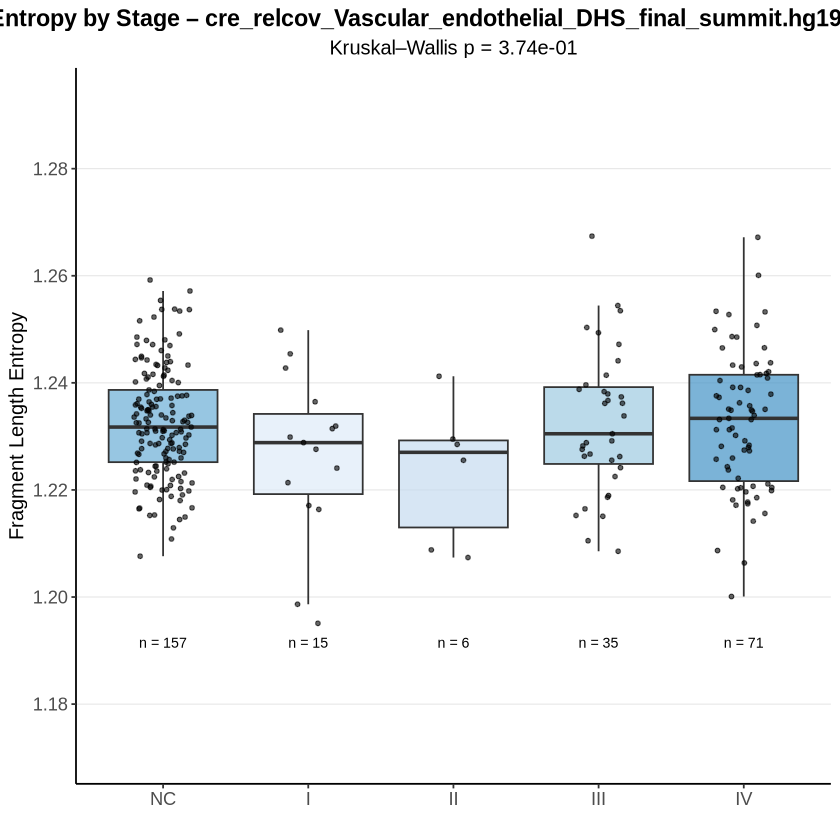

In [136]:
library(ggplot2)
library(dplyr)

# --- Specify the entropy column you want ---
entropy_col <- "cre_relcov_Vascular_endothelial_DHS_final_summit.hg19_rel_cov_density"

# --- Prepare the data for plotting ---
plot_data <- lucas_df_final %>%
  mutate(fragment_entropy = .data[[entropy_col]]) %>%
  mutate(
    Stage_factor = case_when(
      is.na(Stage) | Stage == "NA" ~ "NC",
      Stage == "I" ~ "I",
      Stage == "II" ~ "II",
      Stage == "III" ~ "III",
      Stage == "IV" ~ "IV",
      TRUE ~ as.character(Stage)
    ),
    Stage_factor = factor(Stage_factor, levels = c("NC", "I", "II", "III", "IV"))
  ) %>%
  filter(!is.na(fragment_entropy))

# --- Count samples per stage for annotation ---
stage_counts <- plot_data %>%
  count(Stage_factor) %>%
  mutate(label = paste0("n = ", n))

# --- Kruskal–Wallis test ---
kw_p <- kruskal.test(fragment_entropy ~ Stage_factor, data = plot_data)$p.value

# --- Boxplot ---
p <- ggplot(plot_data, aes(x = Stage_factor, y = fragment_entropy)) +
  geom_boxplot(aes(fill = Stage_factor), alpha = 0.7, outlier.shape = NA) +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6) +
  scale_fill_manual(values = c(
    "NC" = "#6BAED6", 
    "I"  = "#DEEBF7", 
    "II" = "#C6DBEF", 
    "III"= "#9ECAE1", 
    "IV" = "#4292C6"
  )) +
  labs(
    title = paste("Fragment Entropy by Stage –", 
                  gsub("cre_fld_|_filtered_final_summit.hg19_FLD_entropy", "", entropy_col)),
    subtitle = paste0("Kruskal–Wallis p = ", format(kw_p, digits = 3, scientific = TRUE)),
    x = "",
    y = "Fragment Length Entropy"
  ) +
  theme_classic() +
  theme(
    legend.position = "none",
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold"),
    plot.subtitle = element_text(hjust = 0.5, size = 12),
    axis.text = element_text(size = 11),
    axis.title.y = element_text(size = 12),
    panel.grid.major.y = element_line(color = "grey90", size = 0.3)
  ) +
  coord_cartesian(
    ylim = c(min(plot_data$fragment_entropy, na.rm = TRUE) * 0.98,
             max(plot_data$fragment_entropy, na.rm = TRUE) * 1.02)
  ) +
  scale_y_continuous(breaks = scales::pretty_breaks(n = 6))

# --- Add sample count labels ---
for (i in seq_len(nrow(stage_counts))) {
  p <- p + annotate(
    "text",
    x = i,
    y = min(plot_data$fragment_entropy, na.rm = TRUE) -
        0.05 * diff(range(plot_data$fragment_entropy, na.rm = TRUE)),
    label = stage_counts$label[i],
    size = 3
  )
}

# --- Display the plot ---
print(p)

# --- Summary statistics ---
cat("\nFragment Entropy by Stage:\n")
plot_data %>%
  group_by(Stage_factor) %>%
  summarise(
    n = n(),
    mean = round(mean(fragment_entropy, na.rm = TRUE), 3),
    median = round(median(fragment_entropy, na.rm = TRUE), 3),
    sd = round(sd(fragment_entropy, na.rm = TRUE), 3),
    .groups = "drop"
  ) %>%
  print()


List of 6
 $ sample_name   : chr "PGDX26073P29"
 $ features      :List of 7
  ..$ relcov        : num [1:58, 1:2] 1.08 1.08 1.08 1.07 1.07 ...
  .. ..- attr(*, "dimnames")=List of 2
  ..$ swfse         : num [1:58, 1:14] -0.0356 0.1917 0.1659 0.397 0.196 ...
  .. ..- attr(*, "dimnames")=List of 2
  ..$ fld           : num [1:58, 1:5] 0.232 0.441 0.449 0.334 0.525 ...
  .. ..- attr(*, "dimnames")=List of 2
  ..$ qchasm        : num [1:58, 1] 0 0 0 0 0 0 0 0 0 0 ...
  .. ..- attr(*, "dimnames")=List of 2
  ..$ endmotif      : num [1:58, 1:12] NA NA NA NA NA NA NA NA NA NA ...
  .. ..- attr(*, "dimnames")=List of 2
  ..$ qchasm_outward: num [1:58, 1:8] NA NA NA NA NA NA NA NA NA NA ...
  .. ..- attr(*, "dimnames")=List of 2
  ..$ halo          : num [1:58, 1:2] 0.001116 0.000984 0.005449 0.001726 0.002544 ...
  .. ..- attr(*, "dimnames")=List of 2
 $ cre_names     : chr [1:58] "Adrenal_Cortical_filtered_final_summit.hg19" "Adult_Stromal_filtered_final_summit.hg19" "Cancer_epithelial_filte

,rel_cov_profile,rel_cov_density
Adrenal_Cortical_filtered_final_summit.hg19,1.078736,1.0049649
Adult_Stromal_filtered_final_summit.hg19,1.078250,1.0105844
Cancer_epithelial_filtered_final_summit.hg19,1.077930,0.9993459
Cancer_epithelial-Skin_Mammary_Epithelial_overlap_Jaccard25_13pct.hg19_nonredundant.hg19,1.073290,1.1687751
Cardiac_filtered_final_summit.hg19,1.070731,0.9982944
Cardiac-Cardiomyocyte_overlap_Jaccard25_13pct.hg19_nonredundant.hg19,1.070480,1.1424784


[1] 58

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.7396  0.9899  1.0034  1.0329  1.1334  1.2236 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.6712  1.0376  1.0647  1.0363  1.0828  1.1086 

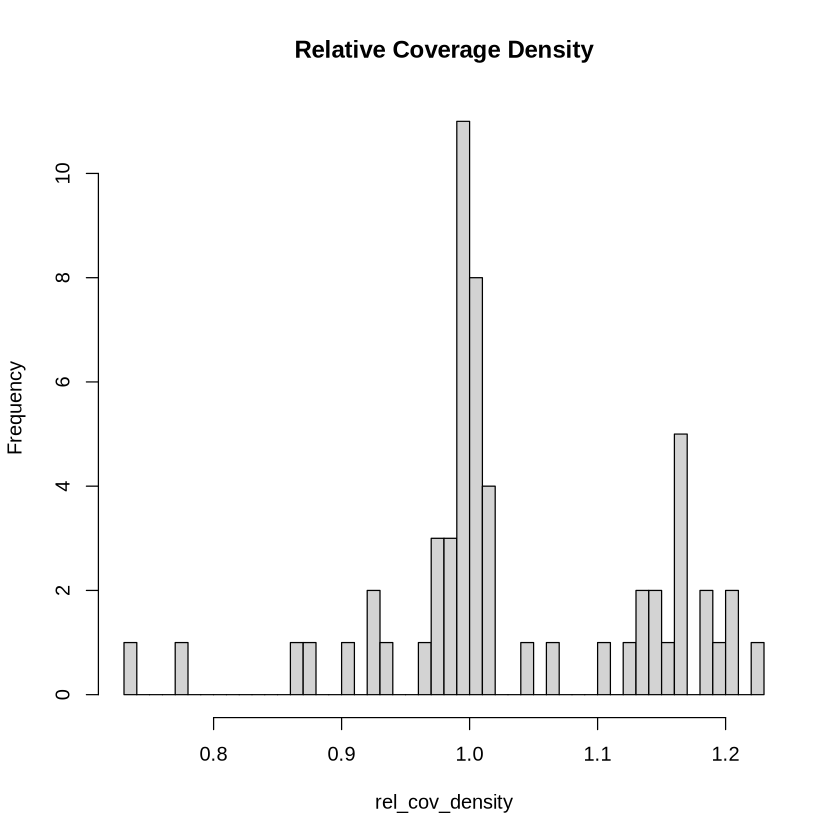

In [12]:
# Load the CRE feature results
res <- readRDS("/dcs07/scharpf/data/jzavras/LUCAS_Olink/Lucas-Cancer-Screening/scripts/lung-cancer-screening-paper/methods_code/WG/results/tmp-FULL/tmp/PGDX26073P29_CRE_metrics.rds")

# Inspect top-level structure
str(res, max.level = 2)

# Access the relcov results specifically
relcov_mat <- res$features$relcov
head(relcov_mat)

# Check how many CREs were processed
nrow(relcov_mat)

# Summaries of relcov metrics
summary(relcov_mat[,"rel_cov_density"])
summary(relcov_mat[,"rel_cov_profile"])

# Optional: visualize distribution
hist(relcov_mat[,"rel_cov_density"], breaks=40, main="Relative Coverage Density", xlab="rel_cov_density")


In [13]:
res

,rel_cov_profile,rel_cov_density
Adrenal_Cortical_filtered_final_summit.hg19,1.0787364,1.0049649
Adult_Stromal_filtered_final_summit.hg19,1.0782500,1.0105844
Cancer_epithelial_filtered_final_summit.hg19,1.0779301,0.9993459
Cancer_epithelial-Skin_Mammary_Epithelial_overlap_Jaccard25_13pct.hg19_nonredundant.hg19,1.0732903,1.1687751
Cardiac_filtered_final_summit.hg19,1.0707314,0.9982944
Cardiac-Cardiomyocyte_overlap_Jaccard25_13pct.hg19_nonredundant.hg19,1.0704799,1.1424784
Cardiomyocyte_filtered_final_summit.hg19,1.0468772,0.9837298
Digestive_filtered_final_summit.hg19,1.0776484,0.9962615
Digestive-Gastric_Epithelial_overlap_Jaccard25_13pct.hg19_nonredundant.hg19,1.0832854,1.1441372
Digestive-GI_Epithelial_overlap_Jaccard25_13pct.hg19_nonredundant.hg19,1.0893765,1.1581733


In [6]:
relcov_mat

,rel_cov_profile,rel_cov_density
Cancer_epithelial_filtered_final_summit.hg19,1.1099685,1.0176200
Cardiac_filtered_final_summit.hg19,1.0480093,0.9705887
Digestive_filtered_final_summit.hg19,1.0897684,1.0021058
Lymphoid_filtered_final_summit.hg19,0.8942965,0.8311780
Musculoskeletal_filtered_final_summit.hg19,1.0814245,0.9966408
Myeloid_erythroid_filtered_final_summit.hg19,1.0046953,0.9275241
Neural_filtered_final_summit.hg19,1.0091718,0.9316505
Organ_devel_renal_filtered_final_summit.hg19,0.9546521,0.8922310
Placental_trophoblast_filtered_final_summit.hg19,1.0914941,1.0014271
Primitive_embryonic_filtered_final_summit.hg19,0.7877892,0.7489636
